# FRISA — Household Food Management Survey: Master Data Analysis

**Project:** FRISA (Fridge's Smart Assistant): a portable AIoT device plus mobile app that helps households know what food they have, use it in time and avoid buying what they do not need.
**Dataset:** FRISA Household Food Management Survey (Google Forms), **119 valid responses**, collected 23–24 September 2026.
**Purpose:** Turn the survey into evidence for the business proposal. The notebook covers who responded, whether FRISA's problem exists in their homes, which solution they want, how different respondent groups differ, and which numbers the proposal can cite.

---

## Executive summary

| # | Insight | Evidence (n = 119) |
|---|---|---|
| 1 | **The target user is real and reachable.** Almost everyone has a fridge, and most buy the household's food themselves. | 98.3% have a refrigerator · 62.2% are *often* or *almost always* involved in grocery shopping |
| 2 | **Food is lost through forgetting it (Visibility Gap).** | 84.9% find it hard to know everything in their fridge without checking item by item · 79.0% have forgotten food in their fridge |
| 3 | **Food is used too late (Priority Gap).** | 79.8% struggle to remember expiry dates · 78.2% have found expired or spoiled food in their fridge |
| 4 | **Money is spent twice (Shopping Gap).** | 81.5% realised they still had an item only *after* buying it again · 76.5% have over-bought food that went uneaten · only 7.6% *strongly* agree they always check stock before shopping |
| 5 | **The problems stack up.** | 73.1% recognise 6 or more of the 8 pain points · 99.2% report at least one waste pathway (forgot, duplicate, expired, over-bought) |
| 6 | **Demand for FRISA's solution is close to unanimous.** | 94–98% agree with every solution statement · 78.2% agree with all seven |
| 7 | **Top features to launch with:** Expiry reminders, "use-first" prioritisation, smart recipes. | 63.0% / 50.4% / 50.4% pick them in their top 3 |
| 8 | **Camera input is preferred** (supports the AI camera). **Voice is not a priority.** | 63.9% prefer a camera-based input method; only 6.7% prefer voice and 8.4% pick the voice assistant as a top feature |
| 9 | **Demand is consistent across segments.** Age, living arrangement, household size and spending barely change the answers. | Only a handful of the 126 segment tests are significant, close to the number expected by chance (Section 11) |
| 10 | **Four feature-based personas** appear, each with its own marketing angle. | K-Means on top-3 feature choices (Section 13) |

> **How to read the numbers.** Every Likert answer in this dataset is 3, 4 or 5; no respondent chose 1 or 2 on any statement. We therefore report **agreement (% choosing 4 or 5)** as the headline and **strong agreement (% choosing 5)** as the measure of intensity. Section 3 explains why.

## Table of contents
1. Setup & visual style
2. Data loading, translation & feature engineering
3. Data quality & methodology check
4. The survey at a glance (KPI dashboard)
5. Respondent profile: who answered?
6. Problem validation: do the food-waste pain points exist?
7. Root-cause scorecard (mapped to proposal Section 1.3)
8. Solution demand: do people want what FRISA offers?
9. Feature priorities: what should FRISA launch with?
10. Word frequency: what words dominate respondents' choices?
11. Input method: how do people want to log food?
12. Segment deep-dive: does it differ by respondent characteristics?
13. Personas: data-driven segmentation of feature preferences
14. Correlation & adoption-readiness analysis
15. Beachhead market: the core early-adopter profile
16. Illustrative economic scenario
17. Proposal-ready evidence (numbers to paste into Chapter 1)
18. Limitations & next steps
19. Export

## 1. Setup & visual style

The charts use one visual system throughout. A single blue marks a single series. Orange marks *problem* statements and blue marks *solution/need* statements. The Likert scale runs from grey (neutral) to light blue (agree) to dark blue (strongly agree). Every chart is saved as a high-resolution PNG to `figures/` so it can go straight into the proposal or slides.

In [1]:
import os, re, textwrap, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud
from IPython.display import display, Markdown

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)

# Paths: works whether the notebook is run from data-analysis/ or the repo root
BASE = Path.cwd() if (Path.cwd() / 'dataset.csv').exists() else Path.cwd() / 'data-analysis'
DATA_PATH = BASE / 'dataset.csv'
FIG_DIR = BASE / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# ---- Palette (validated categorical order + single-hue blue ramp) ----------
BG, INK, INK2, MUTED, GRID, AXIS = '#ffffff', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948')
CAT = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
RAMP = {100: '#cde2fb', 150: '#b7d3f6', 200: '#9ec5f4', 250: '#86b6ef', 300: '#6da7ec', 350: '#5598e7',
        400: '#3987e5', 450: '#2a78d6', 500: '#256abf', 550: '#1c5cab', 600: '#184f95', 650: '#104281', 700: '#0d366b'}
GREY = '#c3c2b7'            # de-emphasised bars
NEUTRAL = '#dcdbd5'         # Likert 3
AGREE, STRONG = RAMP[300], RAMP[600]   # Likert 4 / 5
PAIN_C, NEED_C = ORANGE, BLUE
SEQ = LinearSegmentedColormap.from_list('frisa_seq', [RAMP[100], RAMP[300], RAMP[500], RAMP[700]])
DIV = LinearSegmentedColormap.from_list('frisa_div', ['#c23a3a', '#f3b7b6', '#f0efec', RAMP[200], RAMP[600]])

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'figure.facecolor': BG, 'axes.facecolor': BG,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11.5,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
    'legend.fontsize': 11, 'grid.color': GRID, 'grid.linewidth': 0.8,
})

SOURCE = 'Source: FRISA Household Food Management Survey, 23–24 Sep 2026 (n = 119 respondents).'

# ---- Helpers --------------------------------------------------------------
def wrap(s, width=38):
    return '\n'.join(textwrap.wrap(str(s), width))

def header(fig, title, subtitle=None, source=True):
    """Left-aligned title + subtitle + source line, with layout reserved for them."""
    h = fig.get_figheight()
    top = 1 - (1.05 if subtitle else 0.7) / h
    bottom = 0.42 / h if source else 0
    fig.tight_layout(rect=[0, bottom, 1, top])
    fig.text(0.012, 1 - 0.16 / h, title, fontsize=17, fontweight='bold', color=INK, va='top', ha='left')
    if subtitle:
        fig.text(0.012, 1 - 0.58 / h, subtitle, fontsize=12, color=INK2, va='top', ha='left')
    if source:
        fig.text(0.012, 0.1 / h, SOURCE, fontsize=9.5, color=MUTED, va='bottom', ha='left')

def finish(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', facecolor=BG)
    plt.show()

def clean_ax(ax, grid_axis='x'):
    ax.spines['left'].set_color(AXIS); ax.spines['bottom'].set_color(AXIS)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    ax.tick_params(length=0)

def pct_fmt(ax, axis='x'):
    f = mpl.ticker.PercentFormatter(decimals=0)
    (ax.xaxis if axis == 'x' else ax.yaxis).set_major_formatter(f)

def barh_share(ax, counts, n, color=BLUE, highlight=None, title=None, wrap_width=30, xmax=None, fontsize=11):
    """Horizontal bars of share-of-respondents. `counts` is plotted in the given order, top to bottom."""
    s = counts[::-1]
    pct = s / n * 100
    colors = [color if (highlight is None or lbl in highlight) else GREY for lbl in s.index]
    bars = ax.barh([wrap(i, wrap_width) for i in s.index], pct.values, color=colors,
                   height=0.66, edgecolor=BG, linewidth=1.5)
    xm = xmax or max(pct.max() * 1.32, 10)
    ax.set_xlim(0, xm)
    for b, p, c in zip(bars, pct.values, s.values):
        ax.text(b.get_width() + xm * 0.012, b.get_y() + b.get_height() / 2, f'{p:.1f}%  ({c})',
                va='center', fontsize=fontsize, color=INK)
    pct_fmt(ax); clean_ax(ax, 'x')
    if title:
        ax.set_title(title, loc='left', fontsize=13.5, fontweight='bold', color=INK, pad=10)

def takeaways(*lines, title='Key takeaways'):
    display(Markdown(f'**{title}**\n\n' + '\n'.join(f'- {l}' for l in lines)))

print('Environment ready. Figures will be saved to:', FIG_DIR.resolve())

Environment ready. Figures will be saved to: C:\Users\ASUS\xStyNWx\Documents\BINUS University\Competition\2026\LTS AIESEC 26\Repo\data-analysis\figures


## 2. Data loading, translation & feature engineering

The Google Form was written in Bahasa Indonesia. This step:
1. Renames the 26 columns to short codes (`Q1`–`Q16` for the Likert statements).
2. Translates every answer option into English.
3. Sets a logical order for ordinal answers such as age and spending.
4. Adds analysis groups (age group, living group, shopping-involvement group, region) and composite scores.

In [2]:
raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f'Loaded {raw.shape[0]} responses x {raw.shape[1]} columns from {DATA_PATH.name}')

Q = [f'Q{i}' for i in range(1, 17)]
df = raw.copy()
df.columns = ['timestamp', 'age', 'city', 'living', 'household_size', 'fridge',
              'shopping_freq', 'food_spend'] + Q + ['features', 'input_method']
for c in df.select_dtypes('object'):
    df[c] = df[c].str.replace('\u2013', '-', regex=False).str.strip()   # normalise en-dashes
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y %H:%M:%S')

# ---- Translation maps (Bahasa Indonesia -> English) -----------------------
AGE_MAP = {'<18 tahun': '<18', '18-22 tahun': '18–22', '23-30 tahun': '23–30',
           '31-40 tahun': '31–40', '41-50 tahun': '41–50', '>50 tahun': '50+'}
AGE_ORDER = ['<18', '18–22', '23–30', '31–40', '41–50', '50+']
AGEG_MAP = {'<18': '≤22', '18–22': '≤22', '23–30': '23–30', '31–40': '31–40', '41–50': '41+', '50+': '41+'}
AGEG_ORDER = ['≤22', '23–30', '31–40', '41+']

LIVING_MAP = {'Tinggal bersama keluarga': 'With family', 'Kost / kontrakan': 'Boarding house / rented room',
              'Tinggal sendiri': 'Living alone', 'Tinggal bersama teman': 'With friends', 'Lainnya': 'Other'}
LIVING_ORDER = ['With family', 'Boarding house / rented room', 'Living alone', 'With friends', 'Other']

HH_MAP = {'1 orang': '1 person', '2 orang': '2 people', '3-4 orang': '3–4 people',
          '5-6 orang': '5–6 people', '>6 orang': '7+ people'}
HH_ORDER = ['1 person', '2 people', '3–4 people', '5–6 people', '7+ people']
HHG_MAP = {'1 person': '1–2 people', '2 people': '1–2 people', '3–4 people': '3–4 people',
           '5–6 people': '5+ people', '7+ people': '5+ people'}
HHG_ORDER = ['1–2 people', '3–4 people', '5+ people']

FRIDGE_MAP = {'Ya, kulkas pribadi': 'Yes, private fridge', 'Ya, kulkas bersama': 'Yes, shared fridge', 'Tidak': 'No fridge'}
FRIDGE_ORDER = ['Yes, private fridge', 'Yes, shared fridge', 'No fridge']

SHOP_MAP = {'Hampir selalu': 'Almost always', 'Sering': 'Often', 'Kadang-kadang': 'Sometimes',
            'Jarang': 'Rarely', 'Tidak pernah': 'Never'}
SHOP_ORDER = ['Almost always', 'Often', 'Sometimes', 'Rarely', 'Never']
SHOPG_MAP = {'Almost always': 'High', 'Often': 'High', 'Sometimes': 'Medium', 'Rarely': 'Low', 'Never': 'Low'}
SHOPG_ORDER = ['High', 'Medium', 'Low']

SPEND_MAP = {'< Rp1.000.000': '< Rp1M', 'Rp1.000.000-Rp2.000.000': 'Rp1–2M', 'Rp2.000.001-Rp4.000.000': 'Rp2–4M',
             'Rp4.000.001-Rp6.000.000': 'Rp4–6M', '> Rp6.000.000': '> Rp6M',
             'Tidak tahu / tidak ingin menjawab': 'Prefer not to say'}
SPEND_ORDER = ['< Rp1M', 'Rp1–2M', 'Rp2–4M', 'Rp4–6M', '> Rp6M', 'Prefer not to say']

JABODETABEK = {'Jakarta', 'Bogor', 'Depok', 'Tangerang', 'Bekasi'}

INPUT_MAP = {'Kamera FRISA mengenali makanan secara otomatis': 'FRISA camera auto-recognition',
             'Scan melalui kamera smartphone': 'Smartphone camera scan',
             'Integrasi struk belanja / digital receipt': 'Digital receipt integration',
             'Scan barcode produk': 'Product barcode scan',
             'Perintah suara ke FRISA': 'Voice command to FRISA',
             'Input secara manual melalui aplikasi': 'Manual entry in the app'}
INPUT_ORDER = list(INPUT_MAP.values())
INPUT_TYPE = {'FRISA camera auto-recognition': 'Camera-based', 'Smartphone camera scan': 'Camera-based',
              'Digital receipt integration': 'Semi-automatic', 'Product barcode scan': 'Semi-automatic',
              'Voice command to FRISA': 'Voice', 'Manual entry in the app': 'Manual'}

# Feature options: original -> (key, English label, FRISA pillar KNOW / PRIORITISE / ACT / SAVE)
FEATURES = {
    'Pengingat makanan mendekati kedaluwarsa':         ('reminder',       'Expiry reminders',                    'PRIORITISE'),
    'Prioritas makanan yang harus segera digunakan':   ('priority',       '"Use-first" food prioritisation',     'PRIORITISE'),
    'Rekomendasi resep berdasarkan bahan tersedia':    ('recipe',         'Recipes from available ingredients',  'ACT'),
    'Mengetahui isi kulkas dari aplikasi':             ('app_view',       'View fridge contents in the app',     'KNOW'),
    'Deteksi makanan melalui kamera':                  ('camera',         'AI camera food detection',            'KNOW'),
    'Laporan makanan dan uang yang berhasil dihemat':  ('savings_report', 'Food & money savings report',         'SAVE'),
    'Peringatan pembelian barang yang sudah tersedia': ('dup_alert',      'Duplicate-purchase alert',            'ACT'),
    'Voice Assistant':                                 ('voice',          'Voice assistant',                     'KNOW'),
    'Shopping List':                                   ('shopping_list',  'Shopping list',                       'ACT'),
    'Multiple Fridges':                                ('multi_fridge',   'Multiple-fridge support',             'KNOW'),
}
FEAT_KEYS = [v[0] for v in FEATURES.values()]
FEAT_LABEL = {v[0]: v[1] for v in FEATURES.values()}
FEAT_PILLAR = {v[0]: v[2] for v in FEATURES.values()}
PILLARS = ['KNOW', 'PRIORITISE', 'ACT', 'SAVE']

def translate(col, mapping, order=None):
    out = df[col].map(mapping)
    unmapped = df.loc[out.isna(), col].unique()
    assert len(unmapped) == 0, f'Unmapped values in {col}: {unmapped}'
    return pd.Categorical(out, categories=order, ordered=True) if order else out

df['age'] = translate('age', AGE_MAP, AGE_ORDER)
df['age_group'] = pd.Categorical(df['age'].astype(str).map(AGEG_MAP), AGEG_ORDER, ordered=True)
df['living'] = translate('living', LIVING_MAP, LIVING_ORDER)
df['living_group'] = np.where(df['living'] == 'With family', 'Family household', 'Independent living')
df['household_size'] = translate('household_size', HH_MAP, HH_ORDER)
df['household_group'] = pd.Categorical(df['household_size'].astype(str).map(HHG_MAP), HHG_ORDER, ordered=True)
df['fridge'] = translate('fridge', FRIDGE_MAP, FRIDGE_ORDER)
df['shopping_freq'] = translate('shopping_freq', SHOP_MAP, SHOP_ORDER)
df['shopping_group'] = pd.Categorical(df['shopping_freq'].astype(str).map(SHOPG_MAP), SHOPG_ORDER, ordered=True)
df['food_spend'] = translate('food_spend', SPEND_MAP, SPEND_ORDER)
df['region'] = np.where(df['city'].isin(JABODETABEK), 'Jabodetabek', 'Other cities')
df['input_method'] = translate('input_method', INPUT_MAP, INPUT_ORDER)
df['input_type'] = df['input_method'].astype(str).map(INPUT_TYPE)

# Multi-select features -> one-hot matrix
def parse_features(s):
    keys = []
    for item in s.split(','):
        item = item.strip()
        assert item in FEATURES, f'Unknown feature option: {item}'
        keys.append(FEATURES[item][0])
    return keys
df['feature_list'] = df['features'].apply(parse_features)
FEAT = pd.DataFrame([{k: int(k in fl) for k in FEAT_KEYS} for fl in df['feature_list']], index=df.index)

print('Translation complete: all answer options mapped to English.')

Loaded 119 responses x 26 columns from dataset.csv
Translation complete: all answer options mapped to English.


In [3]:
# ---- Statement dictionary: English wording, theme, and link to proposal root causes ----
STMT = pd.DataFrame([
    # code, full English statement,                                                                    short label,                               theme,             kind,        root cause
    ('Q1',  'I have forgotten that certain food was still in my fridge.',                                 'Forgot food was still in the fridge',      'Visibility Gap',  'Problem',   '1A'),
    ('Q2',  'I only realised I still had an ingredient after buying the same product again.',            'Bought an item I already had',             'Shopping Gap',    'Problem',   '3B'),
    ('Q3',  'I have found expired or spoiled food in my fridge.',                                        'Found expired / spoiled food in fridge',   'Priority Gap',    'Problem',   '2B'),
    ('Q4',  'I have ingredients in the fridge but am unsure what to cook with them.',                    'Unsure what to cook with what I have',     'Utilisation Gap', 'Problem',   '3A'),
    ('Q5',  'Before shopping, I always check what food is still available at home.',                     'Always check home stock before shopping',  'Visibility Gap',  'Behaviour', '1B'),
    ('Q6',  'I have bought too much food and some of it was never eaten.',                               'Over-bought food that went uneaten',       'Shopping Gap',    'Problem',   '3B'),
    ('Q7',  'It is hard to know everything in my fridge without checking it item by item.',              'Hard to know all fridge contents',         'Visibility Gap',  'Problem',   '1B'),
    ('Q8',  'I want to check my fridge contents from outside the home without seeing it directly.',      'Want to check fridge remotely',            'Visibility Gap',  'Need',      '1B'),
    ('Q9',  'I often find it hard to remember the expiry dates of food stored in my fridge.',            'Hard to remember expiry dates',            'Priority Gap',    'Problem',   '2A'),
    ('Q10', 'I need a reminder when food is close to its expiry date.',                                  'Need near-expiry reminders',               'Priority Gap',    'Need',      '2B'),
    ('Q11', 'It would help if fridge food were automatically sorted by what should be used first.',      'Want auto "use-first" sorting',            'Priority Gap',    'Need',      '2A'),
    ('Q12', 'My menu decisions do not always consider the ingredients already at home.',                 'Menu ignores ingredients at home',         'Utilisation Gap', 'Problem',   '3A'),
    ('Q13', 'I am interested in recipe recommendations based on the ingredients in my fridge.',          'Want recipes from fridge ingredients',     'Utilisation Gap', 'Need',      '3A'),
    ('Q14', 'I would be more interested in a recipe if it helps use up ingredients close to expiry.',    'Prefer recipes that use near-expiry food', 'Utilisation Gap', 'Need',      '3A'),
    ('Q15', 'Knowing the money value of wasted food would make me more careful when buying and using it.','Money value of waste would change habits', 'Value Awareness', 'Need',      'SAVE'),
    ('Q16', 'I am interested in a monthly report of the food and money I have saved.',                   'Want monthly food & money savings report', 'Value Awareness', 'Need',      'SAVE'),
], columns=['code', 'statement', 'short', 'theme', 'kind', 'root_cause']).set_index('code')

THEMES = ['Visibility Gap', 'Priority Gap', 'Utilisation Gap', 'Shopping Gap', 'Value Awareness']
PAIN = STMT.index[STMT.kind == 'Problem'].tolist()
NEED = STMT.index[STMT.kind == 'Need'].tolist()
SHORT = STMT['short'].to_dict()

L = df[Q].astype(int)
A = L >= 4          # agree (top-2-box)
T = L == 5          # strongly agree (top-box)
N = len(df)

# ---- Composite metrics per respondent ----
df['pain_count'] = A[PAIN].sum(axis=1)          # 0-8 problem statements agreed with
df['need_count'] = A[NEED].sum(axis=1)          # 0-7 solution statements agreed with
df['need_strong_count'] = T[NEED].sum(axis=1)   # 0-7 solution statements STRONGLY agreed with
df['pain_score'] = L[PAIN].mean(axis=1)         # average problem agreement (1-5)
df['need_score'] = L[NEED].mean(axis=1)         # average solution agreement (1-5)

print(f'Problem statements ({len(PAIN)}): {PAIN}')
print(f'Need statements    ({len(NEED)}): {NEED}')
print('Behaviour statement (1): Q5 (positive habit: checking stock before shopping)')
display(STMT[['theme', 'kind', 'root_cause', 'statement']].rename(columns=str.title))

Problem statements (8): ['Q1', 'Q2', 'Q3', 'Q4', 'Q6', 'Q7', 'Q9', 'Q12']
Need statements    (7): ['Q8', 'Q10', 'Q11', 'Q13', 'Q14', 'Q15', 'Q16']
Behaviour statement (1): Q5 (positive habit: checking stock before shopping)


,Theme,Kind,Root_Cause,Statement
code,,,,
Q1,Visibility Gap,Problem,1A,I have forgotten that certain food was still in my fridge.
Q2,Shopping Gap,Problem,3B,I only realised I still had an ingredient after buying the same product again.
Q3,Priority Gap,Problem,2B,I have found expired or spoiled food in my fridge.
Q4,Utilisation Gap,Problem,3A,I have ingredients in the fridge but am unsure what to cook with them.
Q5,Visibility Gap,Behaviour,1B,"Before shopping, I always check what food is still available at home."
Q6,Shopping Gap,Problem,3B,I have bought too much food and some of it was never eaten.
Q7,Visibility Gap,Problem,1B,It is hard to know everything in my fridge without checking it item by item.
Q8,Visibility Gap,Need,1B,I want to check my fridge contents from outside the home without seeing it directly.
Q9,Priority Gap,Problem,2A,I often find it hard to remember the expiry dates of food stored in my fridge.


In [4]:
preview_cols = ['age', 'city', 'living', 'household_size', 'fridge', 'shopping_freq', 'food_spend', 'input_method']
print('Preview of the cleaned, English-translated dataset (first 5 respondents):')
display(df[preview_cols + ['Q1', 'Q2', 'Q3', 'Q10', 'Q16']].head()
        .assign(top_3_features=df['feature_list'].head().apply(lambda ks: ', '.join(FEAT_LABEL[k] for k in ks))))

Preview of the cleaned, English-translated dataset (first 5 respondents):


,age,city,living,household_size,fridge,shopping_freq,food_spend,input_method,Q1,Q2,Q3,Q10,Q16,top_3_features
0,31–40,Bogor,With family,2 people,"Yes, shared fridge",Often,Rp1–2M,Smartphone camera scan,4,3,5,5,4,"Voice assistant, Expiry reminders, Shopping list"
1,41–50,Tangerang,Living alone,1 person,"Yes, private fridge",Often,Rp2–4M,Smartphone camera scan,4,4,4,4,5,"Recipes from available ingredients, View fridge contents in the app, Expiry reminders"
2,18–22,Bandung,With family,5–6 people,"Yes, private fridge",Almost always,Rp2–4M,Smartphone camera scan,4,5,5,5,4,"Recipes from available ingredients, ""Use-first"" food prioritisation, Expiry reminders"
3,41–50,Semarang,With family,3–4 people,"Yes, shared fridge",Almost always,Rp4–6M,Voice command to FRISA,3,4,3,4,4,"Expiry reminders, ""Use-first"" food prioritisation, AI camera food detection"
4,41–50,Depok,Boarding house / rented room,3–4 people,"Yes, private fridge",Sometimes,Prefer not to say,FRISA camera auto-recognition,4,5,4,5,4,"""Use-first"" food prioritisation, AI camera food detection, Food & money savings report"


## 3. Data quality & methodology check

Before interpreting results, we check completeness and duplicates, and how respondents used the answer scale.

Check,Result
Valid responses,119
Questions (columns),26
Missing values,0
Fully duplicated answer sets,0
Collection window,23 Sep 2026 08:14 → 24 Sep 2026 09:54
Likert values observed (scale 1–5),"3, 4, 5"
Features selected per respondent,3–3 (question allowed max. 3)
Respondents without a fridge,2


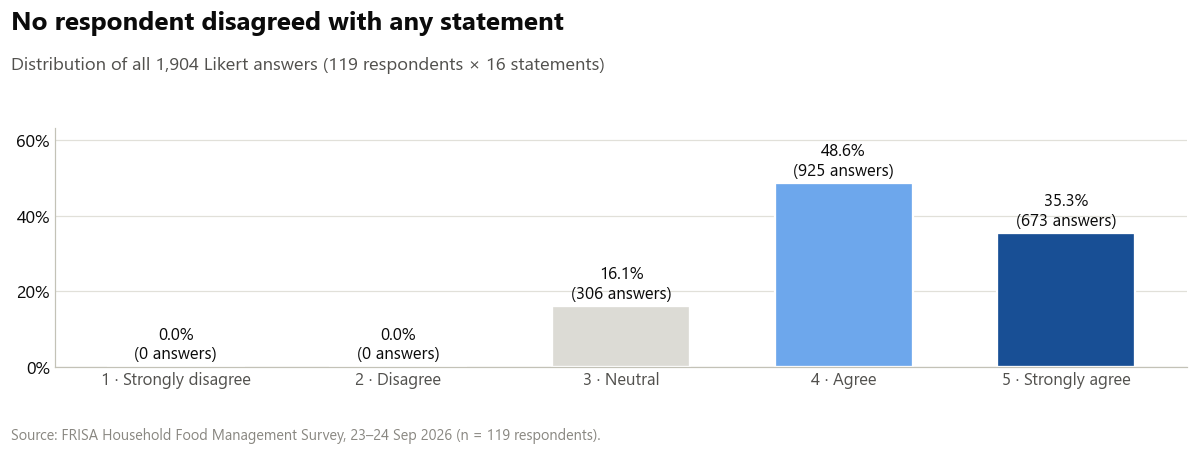

**Key takeaways**

- The data is complete: 119 responses, no missing values and no duplicated answer sets. The survey ran for about 26 hours.
- Every respondent picked exactly 3 features, so feature shares add up to 300% and each share means "% of respondents who picked it in their top 3".
- **Only 3, 4 and 5 were used.** This is common in problem-validation surveys (statements describe familiar situations, and some respondents tend to agree). **Neutral (3) is therefore the least-positive answer here.** We report "% agree (4+5)" as the headline and "% strongly agree (5)" to separate mild from strong conviction.

In [5]:
dup_answers = df.drop(columns=['timestamp', 'feature_list']).duplicated().sum()
dq = pd.DataFrame({
    'Check': ['Valid responses', 'Questions (columns)', 'Missing values', 'Fully duplicated answer sets',
              'Collection window', 'Likert values observed (scale 1–5)', 'Features selected per respondent',
              'Respondents without a fridge'],
    'Result': [N, raw.shape[1], int(raw.isna().sum().sum()), int(dup_answers),
               f"{df.timestamp.min():%d %b %Y %H:%M} → {df.timestamp.max():%d %b %Y %H:%M}",
               ', '.join(map(str, sorted(pd.unique(L.values.ravel())))),
               f"{FEAT.sum(1).min()}–{FEAT.sum(1).max()} (question allowed max. 3)",
               int((df.fridge == 'No fridge').sum())],
})
display(dq.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# How was the answer scale used?
dist_all = pd.Series(L.values.ravel()).value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4.2))
cols = ['#c23a3a', '#f3b7b6', NEUTRAL, AGREE, STRONG]
labels = ['1 · Strongly disagree', '2 · Disagree', '3 · Neutral', '4 · Agree', '5 · Strongly agree']
bars = ax.bar(labels, dist_all.values / dist_all.sum() * 100, color=cols, width=0.62, edgecolor=BG, linewidth=1.5)
for b, v, c in zip(bars, dist_all.values / dist_all.sum() * 100, dist_all.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%\n({c:,} answers)', ha='center', va='bottom', fontsize=11, color=INK)
ax.set_ylim(0, dist_all.max() / dist_all.sum() * 100 * 1.3); pct_fmt(ax, 'y'); clean_ax(ax, 'y')
header(fig, 'No respondent disagreed with any statement',
       f'Distribution of all {dist_all.sum():,} Likert answers (119 respondents × 16 statements)')
finish(fig, '00_likert_scale_usage')

takeaways(
    f'The data is complete: {N} responses, no missing values and no duplicated answer sets. The survey ran for about 26 hours.',
    'Every respondent picked exactly 3 features, so feature shares add up to 300% and each share means "% of respondents who picked it in their top 3".',
    '**Only 3, 4 and 5 were used.** This is common in problem-validation surveys (statements describe familiar situations, and '
    'some respondents tend to agree). **Neutral (3) is therefore the least-positive answer here.** We report "% agree (4+5)" as the '
    'headline and "% strongly agree (5)" to separate mild from strong conviction.',
)

## 4. The survey at a glance

The headline numbers for the proposal, pitch deck and executive summary.

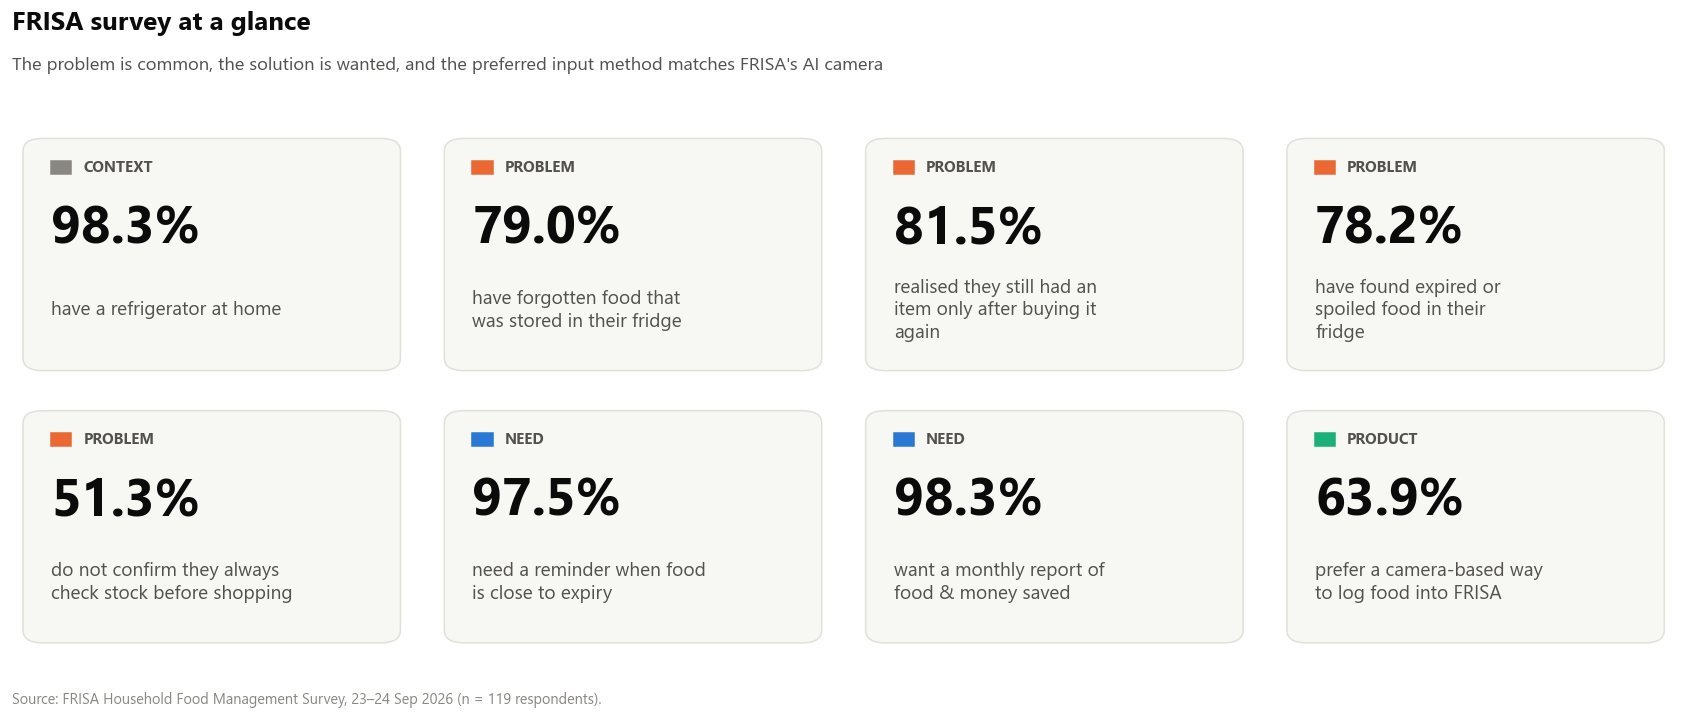

In [6]:
def share(mask): return 100 * np.mean(mask)

camera_share = share(df.input_type == 'Camera-based')
KPIS = [
    (share(df.fridge != 'No fridge'), 'have a refrigerator at home',                          'CONTEXT'),
    (share(A.Q1), 'have forgotten food that was stored in their fridge',                     'PROBLEM'),
    (share(A.Q2), 'realised they still had an item only after buying it again',             'PROBLEM'),
    (share(A.Q3), 'have found expired or spoiled food in their fridge',                      'PROBLEM'),
    (share(~A.Q5), 'do not confirm they always check stock before shopping',                 'PROBLEM'),
    (share(A.Q10), 'need a reminder when food is close to expiry',                            'NEED'),
    (share(A.Q16), 'want a monthly report of food & money saved',                            'NEED'),
    (camera_share, 'prefer a camera-based way to log food into FRISA',                        'PRODUCT'),
]
ACCENT = {'CONTEXT': MUTED, 'PROBLEM': PAIN_C, 'NEED': NEED_C, 'PRODUCT': AQUA}

fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.6))
for ax, (v, label, kind) in zip(axes.flat, KPIS):
    ax.set_axis_off()
    ax.add_patch(FancyBboxPatch((0.03, 0.04), 0.94, 0.92, boxstyle='round,pad=0,rounding_size=0.05',
                                transform=ax.transAxes, facecolor='#f7f7f4', edgecolor=GRID, linewidth=1))
    ax.add_patch(plt.Rectangle((0.10, 0.82), 0.05, 0.05, transform=ax.transAxes, color=ACCENT[kind]))
    ax.text(0.18, 0.845, kind, transform=ax.transAxes, fontsize=10, color=INK2, va='center', fontweight='bold')
    ax.text(0.10, 0.60, f'{v:.1f}%', transform=ax.transAxes, fontsize=34, fontweight='bold', color=INK, va='center')
    ax.text(0.10, 0.28, wrap(label, 27), transform=ax.transAxes, fontsize=12.5, color=INK2, va='center', linespacing=1.35)
header(fig, 'FRISA survey at a glance',
       'The problem is common, the solution is wanted, and the preferred input method matches FRISA\'s AI camera')
finish(fig, '01_kpi_dashboard')

## 5. Respondent profile: who answered?

Knowing who answered tells us how far the findings can be generalised and which segments the proposal can speak for.

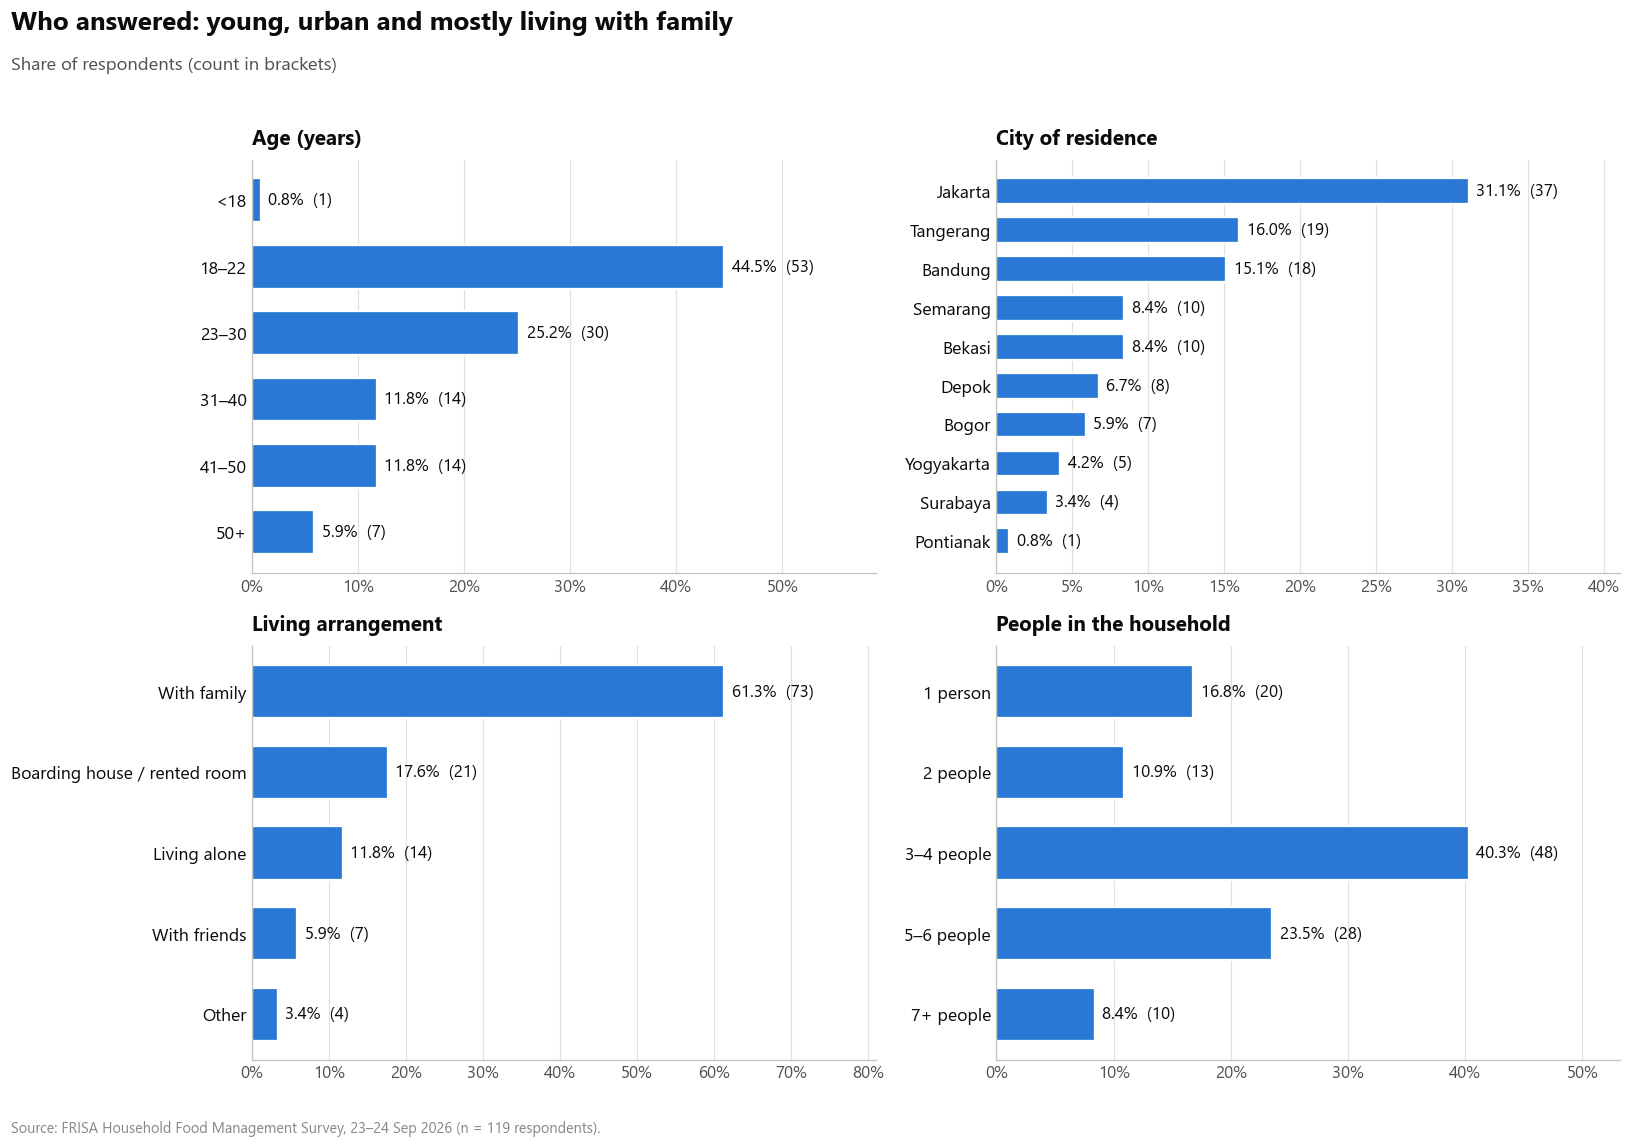

**Key takeaways**

- **Age:** 44.5% are 18–22 and 70.6% are 30 or younger. The sample leans towards digital-native, smartphone-first users, which suits an app-plus-device product. Respondents aged 31+ (29.4%) give a view from established households.
- **Geography:** 68.1% live in Greater Jakarta (Jabodetabek), with Bandung (15.1%) and Semarang (8.4%) next. This matches FRISA's planned urban launch market.
- **Household:** 61.3% live with family and 72.3% live in homes of 3+ people. In these homes several people share one fridge, which is where fragmented visibility (root cause 1A) happens.
- **Independent living** (boarding house, alone, with friends or other) accounts for 38.7%, a secondary segment of students and young professionals.

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10.5))
barh_share(axes[0, 0], df.age.value_counts().reindex(AGE_ORDER), N, title='Age (years)')
barh_share(axes[0, 1], df.city.value_counts(), N, title='City of residence')
barh_share(axes[1, 0], df.living.value_counts().reindex(LIVING_ORDER), N, title='Living arrangement')
barh_share(axes[1, 1], df.household_size.value_counts().reindex(HH_ORDER), N, title='People in the household')
header(fig, 'Who answered: young, urban and mostly living with family',
       'Share of respondents (count in brackets)')
finish(fig, '02_profile_demographics')

jabo = share(df.region == 'Jabodetabek')
le30 = share(df.age.isin(['<18', '18–22', '23–30']))
takeaways(
    f'**Age:** {share(df.age == "18–22"):.1f}% are 18–22 and {le30:.1f}% are 30 or younger. The sample leans towards digital-native, '
    f'smartphone-first users, which suits an app-plus-device product. Respondents aged 31+ ({share(df.age_group.isin(["31–40", "41+"])):.1f}%) '
    'give a view from established households.',
    f'**Geography:** {jabo:.1f}% live in Greater Jakarta (Jabodetabek), with Bandung ({share(df.city == "Bandung"):.1f}%) and Semarang '
    f'({share(df.city == "Semarang"):.1f}%) next. This matches FRISA\'s planned urban launch market.',
    f'**Household:** {share(df.living == "With family"):.1f}% live with family and {share(df.household_group.isin(["3–4 people", "5+ people"])):.1f}% '
    'live in homes of 3+ people. In these homes several people share one fridge, which is where fragmented visibility (root cause 1A) happens.',
    f'**Independent living** (boarding house, alone, with friends or other) accounts for {share(df.living_group == "Independent living"):.1f}%, '
    'a secondary segment of students and young professionals.',
)

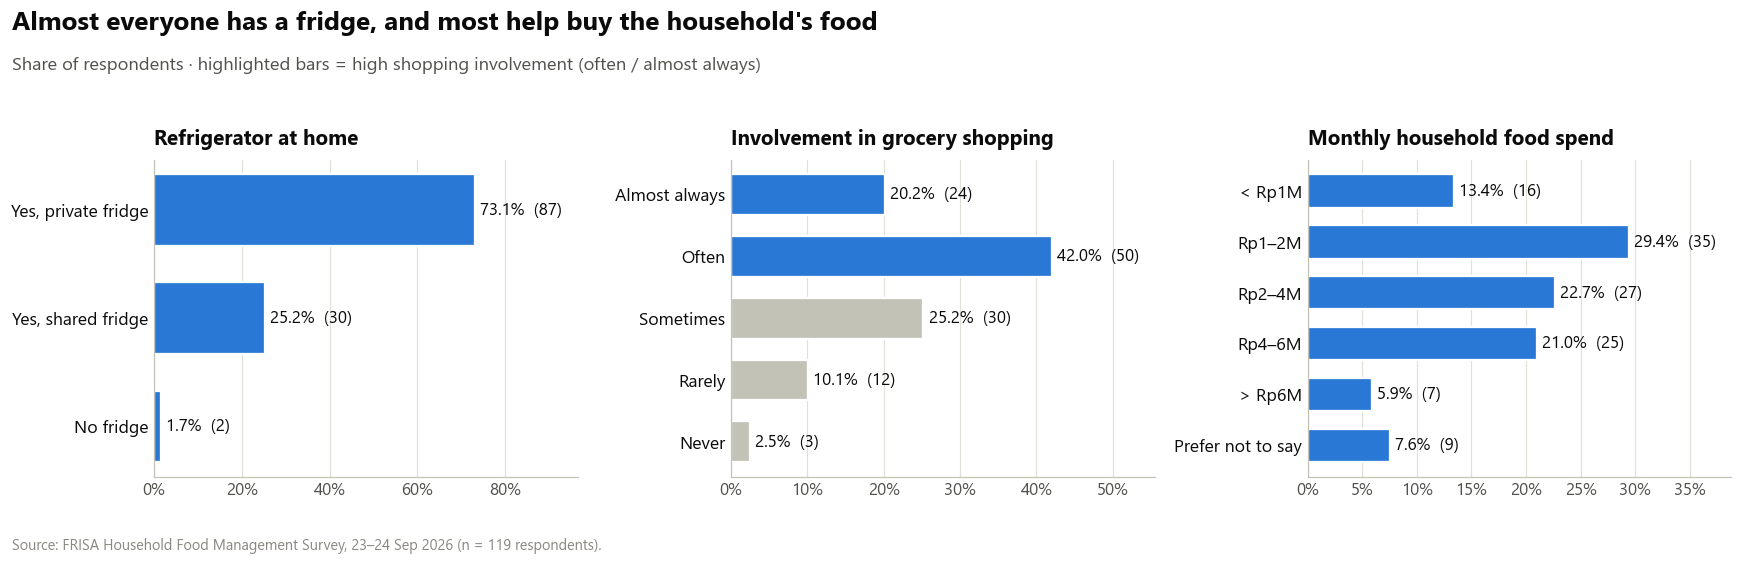

**Key takeaways**

- **98.3%** have a refrigerator, so almost every respondent could use FRISA. 25.2% share a fridge with others; FRISA's shared inventory view fits these users directly.
- **62.2%** are *often* or *almost always* involved in buying food, so most respondents make the purchase decisions FRISA tries to influence.
- **Food spending:** the largest band is Rp1–2M per month (29.4%), and 53.6% of those who disclosed spend more than Rp2M. At these amounts, even a small share of wasted food costs real money (see Section 16).

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
barh_share(axes[0], df.fridge.value_counts().reindex(FRIDGE_ORDER), N, title='Refrigerator at home', wrap_width=20)
barh_share(axes[1], df.shopping_freq.value_counts().reindex(SHOP_ORDER), N,
           title='Involvement in grocery shopping', highlight=['Almost always', 'Often'], wrap_width=20)
barh_share(axes[2], df.food_spend.value_counts().reindex(SPEND_ORDER), N, title='Monthly household food spend', wrap_width=20)
header(fig, 'Almost everyone has a fridge, and most help buy the household\'s food',
       'Share of respondents · highlighted bars = high shopping involvement (often / almost always)')
finish(fig, '03_profile_household')

known_spend = df[df.food_spend != 'Prefer not to say']
takeaways(
    f'**{share(df.fridge != "No fridge"):.1f}%** have a refrigerator, so almost every respondent could use FRISA. '
    f'{share(df.fridge == "Yes, shared fridge"):.1f}% share a fridge with others; FRISA\'s shared inventory view fits these users directly.',
    f'**{share(df.shopping_group == "High"):.1f}%** are *often* or *almost always* involved in buying food, so most respondents make the '
    'purchase decisions FRISA tries to influence.',
    f'**Food spending:** the largest band is Rp1–2M per month ({share(df.food_spend == "Rp1–2M"):.1f}%), and '
    f'{100 * known_spend.food_spend.isin(["Rp2–4M", "Rp4–6M", "> Rp6M"]).mean():.1f}% of those who disclosed spend more than Rp2M. '
    'At these amounts, even a small share of wasted food costs real money (see Section 16).',
)

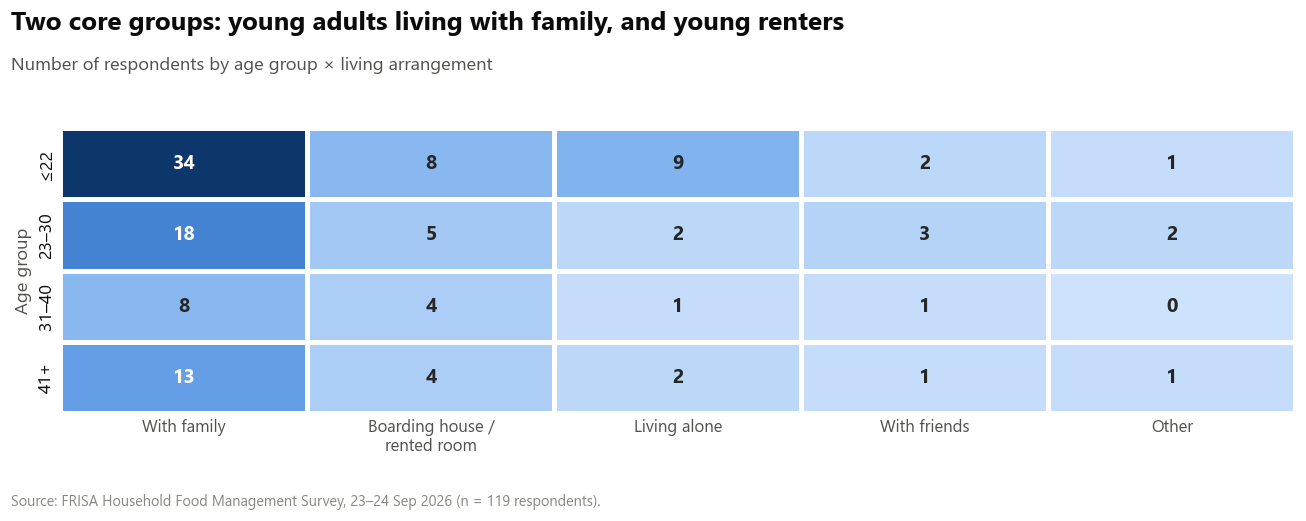

**Key takeaways**

- The biggest cell is **≤22-year-olds living with family** (34 respondents): students who help run a family kitchen.
- **Boarding houses and rented rooms** are mostly under-30s (13 of 21), a natural segment for a portable device that needs no permanent installation.
- Most respondents aged 31+ live with family (21 of 35, 60%). They represent the "family grocery manager" persona.

In [9]:
ct = pd.crosstab(df.age_group, df.living).reindex(columns=LIVING_ORDER)
fig, ax = plt.subplots(figsize=(12, 4.8))
sns.heatmap(ct, annot=True, fmt='d', cmap=SEQ, cbar=False, linewidths=2, linecolor=BG, ax=ax,
            annot_kws={'fontsize': 13, 'fontweight': 'bold'})
ax.set_xlabel(''); ax.set_ylabel('Age group', color=INK2)
ax.set_xticklabels([wrap(t.get_text(), 16) for t in ax.get_xticklabels()], rotation=0)
ax.tick_params(length=0)
header(fig, 'Two core groups: young adults living with family, and young renters',
       'Number of respondents by age group × living arrangement')
finish(fig, '04_profile_age_x_living')

ct_share = ct / N * 100
takeaways(
    f'The biggest cell is **≤22-year-olds living with family** ({ct.loc["≤22", "With family"]} respondents): students who help run a family kitchen.',
    f'**Boarding houses and rented rooms** are mostly under-30s ({ct.loc[["≤22", "23–30"], "Boarding house / rented room"].sum()} of '
    f'{ct["Boarding house / rented room"].sum()}), a natural segment for a portable device that needs no permanent installation.',
    f'Most respondents aged 31+ live with family ({ct.loc[["31–40", "41+"], "With family"].sum()} of {ct.loc[["31–40", "41+"]].sum().sum()}, '
    f'{ct.loc[["31–40", "41+"], "With family"].sum() / ct.loc[["31–40", "41+"]].sum().sum() * 100:.0f}%). They represent the "family grocery manager" persona.',
)

## 6. Problem validation: do the food-waste pain points exist?

The proposal (Section 1.3) says household food waste comes from three gaps: **Visibility** ("What food do I have?"), **Priority** ("What should I use first?") and **Utilisation** ("What can I do with it?"). The shopping side of utilisation (duplicates and over-buying) is reported separately here as the **Shopping Gap**. This section tests whether respondents recognise these problems.

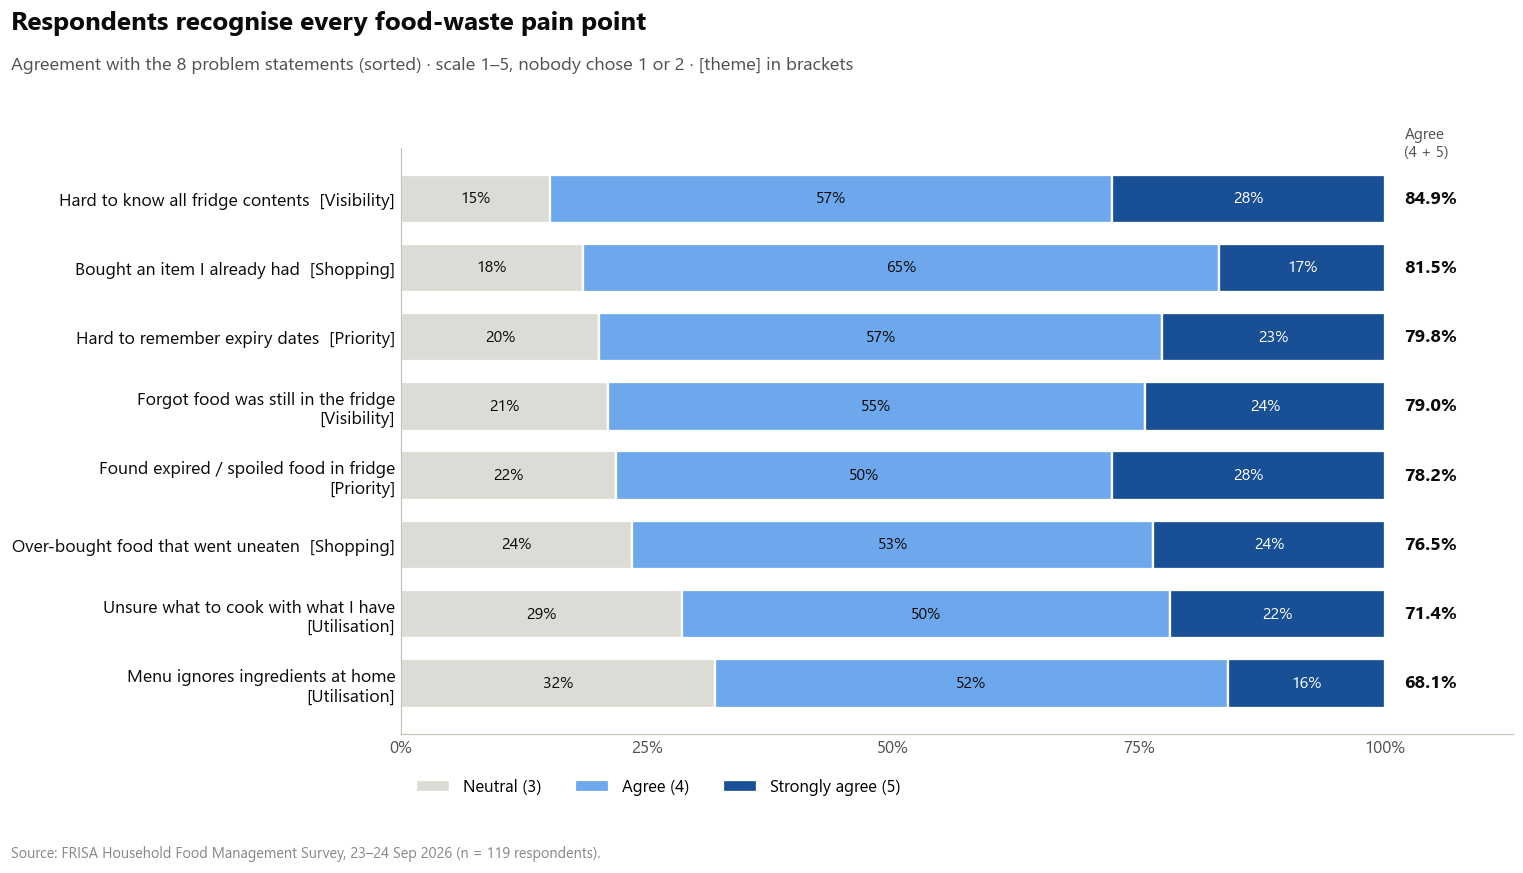

**Key takeaways**

- **84.9%** agree: *It is hard to know everything in my fridge without checking it item by item.* (Visibility Gap, root cause 1B)
- **81.5%** agree: *I only realised I still had an ingredient after buying the same product again.* (Shopping Gap, root cause 3B)
- **79.8%** agree: *I often find it hard to remember the expiry dates of food stored in my fridge.* (Priority Gap, root cause 2A)
- **79.0%** agree: *I have forgotten that certain food was still in my fridge.* (Visibility Gap, root cause 1A)
- Even the least-recognised problem, *"Menu ignores ingredients at home"*, is recognised by 68.1%.
- All three gaps in the proposal show up in respondents' homes, and the **Visibility Gap** (not knowing what is in the fridge) is the most recognised.

In [10]:
def likert_stack(ax, cols, labeller, wrap_width=46):
    dist = pd.DataFrame({c: L[c].value_counts(normalize=True).reindex([1, 2, 3, 4, 5], fill_value=0) * 100
                         for c in cols}).T
    dist['agree'] = dist[4] + dist[5]
    dist = dist.sort_values(['agree', 5], ascending=True)
    ylabels = [wrap(labeller(c), wrap_width) for c in dist.index]
    left = np.zeros(len(dist))
    for lvl, colr, name, tcol in [(3, NEUTRAL, 'Neutral (3)', INK), (4, AGREE, 'Agree (4)', INK),
                                  (5, STRONG, 'Strongly agree (5)', 'white')]:
        vals = dist[lvl].values
        ax.barh(ylabels, vals, left=left, color=colr, height=0.7, edgecolor=BG, linewidth=1.5, label=name)
        for i, (l, v) in enumerate(zip(left, vals)):
            if v >= 6:
                ax.text(l + v / 2, i, f'{v:.0f}%', ha='center', va='center', fontsize=10.5, color=tcol)
        left += vals
    for i, t in enumerate(dist['agree']):
        ax.text(102, i, f'{t:.1f}%', va='center', fontsize=12, fontweight='bold', color=INK)
    ax.text(102, len(dist) - 0.45, 'Agree\n(4 + 5)', va='bottom', fontsize=10, color=INK2)
    ax.set_xlim(0, 113); ax.set_xticks([0, 25, 50, 75, 100]); pct_fmt(ax); clean_ax(ax, None)
    ax.legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3)
    return dist

lab = lambda c: f'{SHORT[c]}  [{STMT.theme[c].replace(" Gap", "")}]'
fig, ax = plt.subplots(figsize=(14, 8))
pain_dist = likert_stack(ax, PAIN, lab)
header(fig, 'Respondents recognise every food-waste pain point',
       'Agreement with the 8 problem statements (sorted) · scale 1–5, nobody chose 1 or 2 · [theme] in brackets')
finish(fig, '05_problem_validation_likert')

top = pain_dist.sort_values('agree', ascending=False)
takeaways(
    *[f'**{r.agree:.1f}%** agree: *{STMT.statement[c]}* ({STMT.theme[c]}, root cause {STMT.root_cause[c]})' for c, r in top.head(4).iterrows()],
    f'Even the least-recognised problem, *"{SHORT[top.index[-1]]}"*, is recognised by {top.agree.iloc[-1]:.1f}%.',
    'All three gaps in the proposal show up in respondents\' homes, and the **Visibility Gap** (not knowing what is in the fridge) is the most recognised.',
)

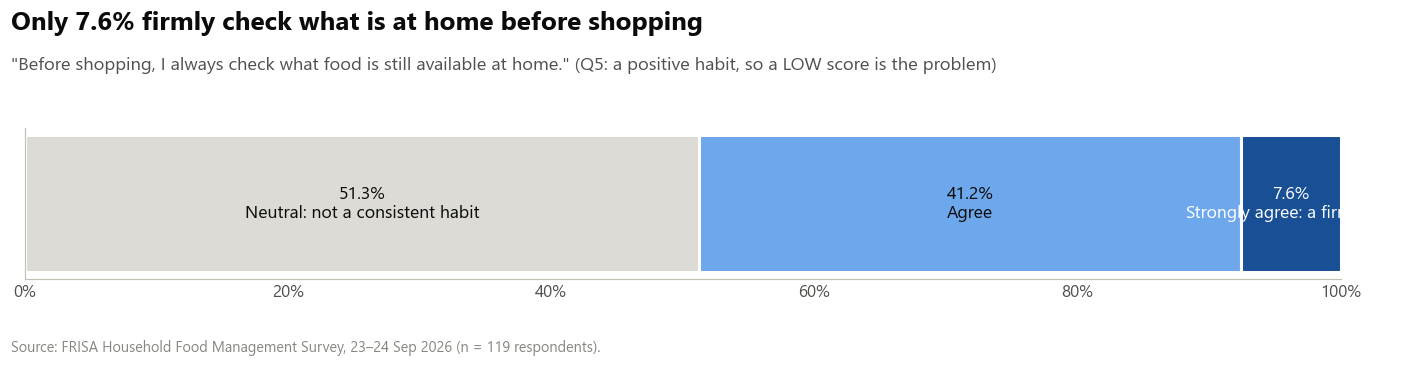

**Key takeaways**

- Q5 is the only statement where agreement is the *good* answer. It has the lowest agreement of all 16 (48.7%) and **51.3% answered neutral**, i.e. they do not describe checking as a consistent habit.
- Proposal wording (root cause 1B): *"51.3% of respondents do not consistently check what they already have before shopping; only 7.6% say they always do."*
- This behaviour gap is what FRISA's *remote stock check from the store* is designed to close.

In [11]:
q5 = L.Q5.value_counts(normalize=True).reindex([3, 4, 5], fill_value=0) * 100
fig, ax = plt.subplots(figsize=(13, 3.4))
left = 0
for lvl, colr, name, tcol in [(3, NEUTRAL, 'Neutral: not a consistent habit', INK), (4, AGREE, 'Agree', INK),
                              (5, STRONG, 'Strongly agree: a firm habit', 'white')]:
    ax.barh([''], [q5[lvl]], left=left, color=colr, height=0.55, edgecolor=BG, linewidth=2)
    ax.text(left + q5[lvl] / 2, 0, f'{q5[lvl]:.1f}%\n{name}', ha='center', va='center', fontsize=11.5, color=tcol)
    left += q5[lvl]
ax.set_xlim(0, 100); pct_fmt(ax); clean_ax(ax, None); ax.set_yticks([])
header(fig, f'Only {q5[5]:.1f}% firmly check what is at home before shopping',
       '"Before shopping, I always check what food is still available at home." (Q5: a positive habit, so a LOW score is the problem)')
finish(fig, '06_check_before_shopping')

takeaways(
    f'Q5 is the only statement where agreement is the *good* answer. It has the lowest agreement of all 16 ({share(A.Q5):.1f}%) and '
    f'**{q5[3]:.1f}% answered neutral**, i.e. they do not describe checking as a consistent habit.',
    f'Proposal wording (root cause 1B): *"{share(~A.Q5):.1f}% of respondents do not consistently check what they already have before shopping; '
    f'only {q5[5]:.1f}% say they always do."*',
    'This behaviour gap is what FRISA\'s *remote stock check from the store* is designed to close.',
)

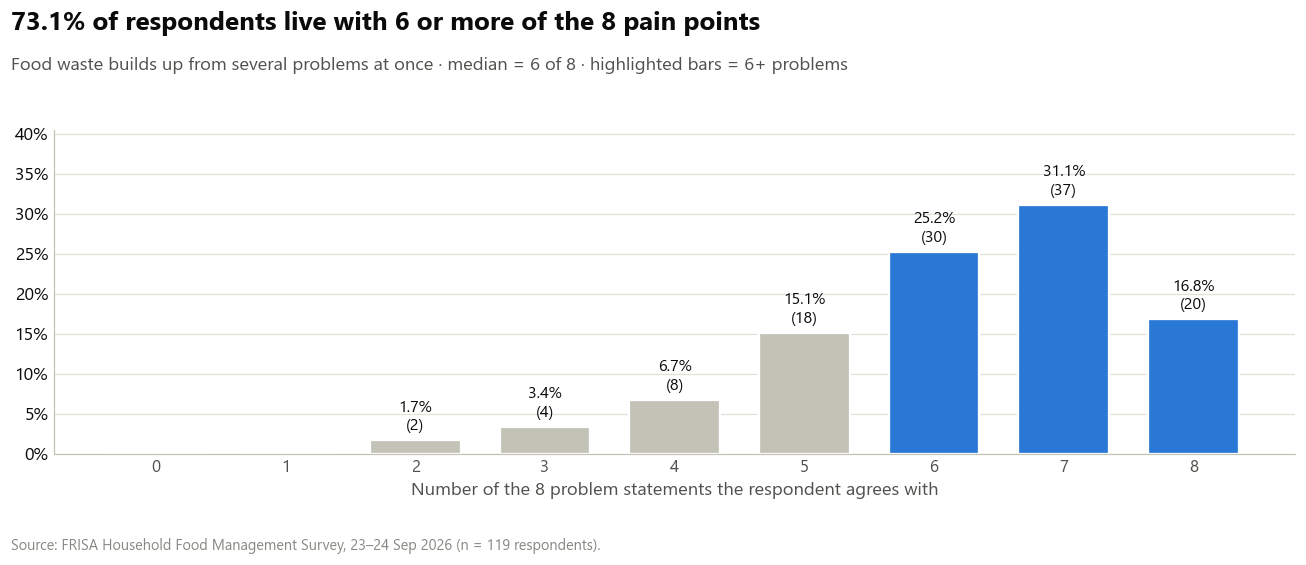

**Key takeaways**

- The median respondent agrees with **6 of 8** problem statements, and 95.0% agree with at least half.
- This matches the literature cited in the proposal (Quested et al., 2013; Schanes et al., 2018): household waste comes from **connected routines, not one careless act**. A single-feature fix (e.g. only a shopping list) would miss most of the problem, which supports FRISA's end-to-end KNOW → PRIORITISE → ACT → SAVE design.

In [12]:
pc = df.pain_count.value_counts().reindex(range(0, 9), fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5.2))
bars = ax.bar(pc.index, pc.values / N * 100, color=[BLUE if k >= 6 else GREY for k in pc.index],
              width=0.7, edgecolor=BG, linewidth=1.5)
for b, c in zip(bars, pc.values):
    if c:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f'{c / N * 100:.1f}%\n({c})',
                ha='center', va='bottom', fontsize=10.5, color=INK)
ax.set_xticks(range(0, 9)); ax.set_xlabel('Number of the 8 problem statements the respondent agrees with')
ax.set_ylim(0, pc.max() / N * 100 * 1.3); pct_fmt(ax, 'y'); clean_ax(ax, 'y')
p6 = share(df.pain_count >= 6)
header(fig, f'{p6:.1f}% of respondents live with 6 or more of the 8 pain points',
       f'Food waste builds up from several problems at once · median = {df.pain_count.median():.0f} of 8 · highlighted bars = 6+ problems')
finish(fig, '07_pain_point_accumulation')

takeaways(
    f'The median respondent agrees with **{df.pain_count.median():.0f} of 8** problem statements, and {share(df.pain_count >= 4):.1f}% agree with at least half.',
    'This matches the literature cited in the proposal (Quested et al., 2013; Schanes et al., 2018): household waste comes from '
    '**connected routines, not one careless act**. A single-feature fix (e.g. only a shopping list) would miss most of the problem, '
    'which supports FRISA\'s end-to-end KNOW → PRIORITISE → ACT → SAVE design.',
)

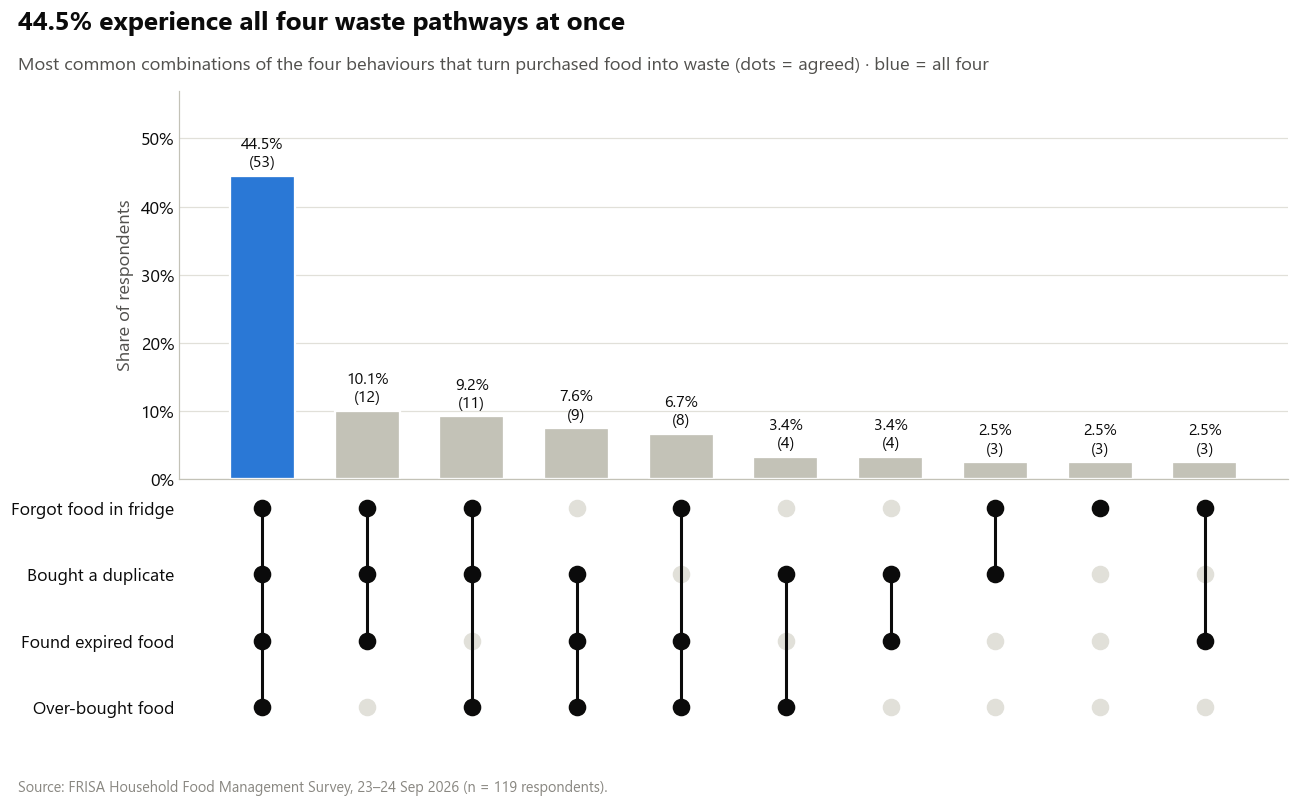

**Key takeaways**

- **99.2%** agree with at least one of the four waste pathways. Nearly every respondent has lost food in at least one way.
- The most common single pattern is **all four together** (44.5%): forgetting, duplicate buying, expiry and over-buying tend to happen in the same households.
- **54.6%** agree with the "forget → re-buy → throw away" chain (Q1 + Q2 + Q3), the exact scenario FRISA's inventory + expiry + duplicate-alert loop targets.

In [13]:
# UpSet-style view: how the four "waste pathway" problems co-occur
PATH = ['Q1', 'Q2', 'Q3', 'Q6']
PATH_NAME = {'Q1': 'Forgot food in fridge', 'Q2': 'Bought a duplicate', 'Q3': 'Found expired food', 'Q6': 'Over-bought food'}
combo = A[PATH].apply(lambda r: tuple(r.values), axis=1).value_counts().head(10)

fig = plt.figure(figsize=(13, 7.4))
gs = fig.add_gridspec(2, 1, height_ratios=[2.3, 1.3], hspace=0.06)
ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
x = np.arange(len(combo))
cols = [BLUE if all(k) else GREY for k in combo.index]
b = ax1.bar(x, combo.values / N * 100, color=cols, width=0.62, edgecolor=BG, linewidth=1.5)
for xi, c in zip(x, combo.values):
    ax1.text(xi, c / N * 100 + 0.7, f'{c / N * 100:.1f}%\n({c})', ha='center', va='bottom', fontsize=10.5, color=INK)
ax1.set_xticks([]); ax1.set_ylim(0, combo.max() / N * 100 * 1.28); pct_fmt(ax1, 'y'); clean_ax(ax1, 'y')
ax1.set_ylabel('Share of respondents')
for xi, k in zip(x, combo.index):
    on = [j for j, v in enumerate(k) if v]
    ax2.scatter([xi] * 4, range(4), s=110, color=GRID, zorder=2)
    if on:
        ax2.scatter([xi] * len(on), on, s=110, color=INK, zorder=3)
        ax2.plot([xi, xi], [min(on), max(on)], color=INK, linewidth=2, zorder=2)
ax2.set_yticks(range(4)); ax2.set_yticklabels([PATH_NAME[p] for p in PATH]); ax2.invert_yaxis()
ax2.set_xticks([]); ax2.set_xlim(ax1.get_xlim())
for s in ax2.spines.values(): s.set_visible(False)
ax2.tick_params(length=0)
all4 = share(A[PATH].all(axis=1)); any1 = share(A[PATH].any(axis=1))
header(fig, f'{all4:.1f}% experience all four waste pathways at once',
       'Most common combinations of the four behaviours that turn purchased food into waste (dots = agreed) · blue = all four')
finish(fig, '08_waste_pathways_upset')

takeaways(
    f'**{any1:.1f}%** agree with at least one of the four waste pathways. Nearly every respondent has lost food in at least one way.',
    f'The most common single pattern is **all four together** ({all4:.1f}%): forgetting, duplicate buying, expiry and over-buying '
    'tend to happen in the same households.',
    f'**{share(A[["Q1", "Q2", "Q3"]].all(axis=1)):.1f}%** agree with the "forget → re-buy → throw away" chain (Q1 + Q2 + Q3), '
    'the exact scenario FRISA\'s inventory + expiry + duplicate-alert loop targets.',
)

## 7. Root-cause scorecard (mapped to proposal Section 1.3)

The table below links each root cause in the proposal to its survey evidence. The **Agree %** column can fill the `Survey: [XX]%` placeholders directly.

In [14]:
RC_NAME = {'1A': 'Fragmented food visibility', '1B': 'Manual & inconsistent inventory checking',
           '2A': 'Lack of expiry-based prioritisation', '2B': 'Reactive rather than preventive management',
           '3A': 'Disconnected meal planning', '3B': 'Disconnected shopping decisions', 'SAVE': 'Value awareness (SDG 12.8)'}
rows = []
for c in Q:
    s = STMT.loc[c]
    if c == 'Q5':
        rows.append((s.root_cause, RC_NAME[s.root_cause], 'Problem', 'Do NOT consistently check home stock before shopping (Q5 not agreed)',
                     share(~A.Q5), share(L.Q5 == 3), np.nan))
    else:
        rows.append((s.root_cause, RC_NAME[s.root_cause], s.kind, f'{s.statement} ({c})', share(A[c]), share(T[c]), L[c].mean()))
score = (pd.DataFrame(rows, columns=['Root cause', 'Description', 'Type', 'Survey evidence', 'Agree %', 'Strongly agree %', 'Mean (1–5)'])
         .sort_values(['Root cause', 'Type', 'Agree %'], ascending=[True, False, False]))
score.loc[score['Survey evidence'].str.startswith('Do NOT'), 'Strongly agree %'] = np.nan
display(score.style.hide(axis='index')
        .format({'Agree %': '{:.1f}%', 'Strongly agree %': '{:.1f}%', 'Mean (1–5)': '{:.2f}'}, na_rep='–')
        .background_gradient(subset=['Agree %'], cmap=SEQ, vmin=40, vmax=100)
        .set_properties(subset=['Survey evidence'], **{'text-align': 'left'}))
print('Note: for the Q5 row, "Agree %" = share who did NOT agree they always check (neutral answers).')

Root cause,Description,Type,Survey evidence,Agree %,Strongly agree %,Mean (1–5)
1A,Fragmented food visibility,Problem,I have forgotten that certain food was still in my fridge. (Q1),79.0%,24.4%,4.03
1B,Manual & inconsistent inventory checking,Problem,It is hard to know everything in my fridge without checking it item by item. (Q7),84.9%,27.7%,4.13
1B,Manual & inconsistent inventory checking,Problem,Do NOT consistently check home stock before shopping (Q5 not agreed),51.3%,–,–
1B,Manual & inconsistent inventory checking,Need,I want to check my fridge contents from outside the home without seeing it directly. (Q8),94.1%,51.3%,4.45
2A,Lack of expiry-based prioritisation,Problem,I often find it hard to remember the expiry dates of food stored in my fridge. (Q9),79.8%,22.7%,4.03
2A,Lack of expiry-based prioritisation,Need,It would help if fridge food were automatically sorted by what should be used first. (Q11),95.8%,54.6%,4.50
2B,Reactive rather than preventive management,Problem,I have found expired or spoiled food in my fridge. (Q3),78.2%,27.7%,4.06
2B,Reactive rather than preventive management,Need,I need a reminder when food is close to its expiry date. (Q10),97.5%,52.9%,4.50
3A,Disconnected meal planning,Problem,I have ingredients in the fridge but am unsure what to cook with them. (Q4),71.4%,21.8%,3.93
3A,Disconnected meal planning,Problem,My menu decisions do not always consider the ingredients already at home. (Q12),68.1%,16.0%,3.84


Note: for the Q5 row, "Agree %" = share who did NOT agree they always check (neutral answers).


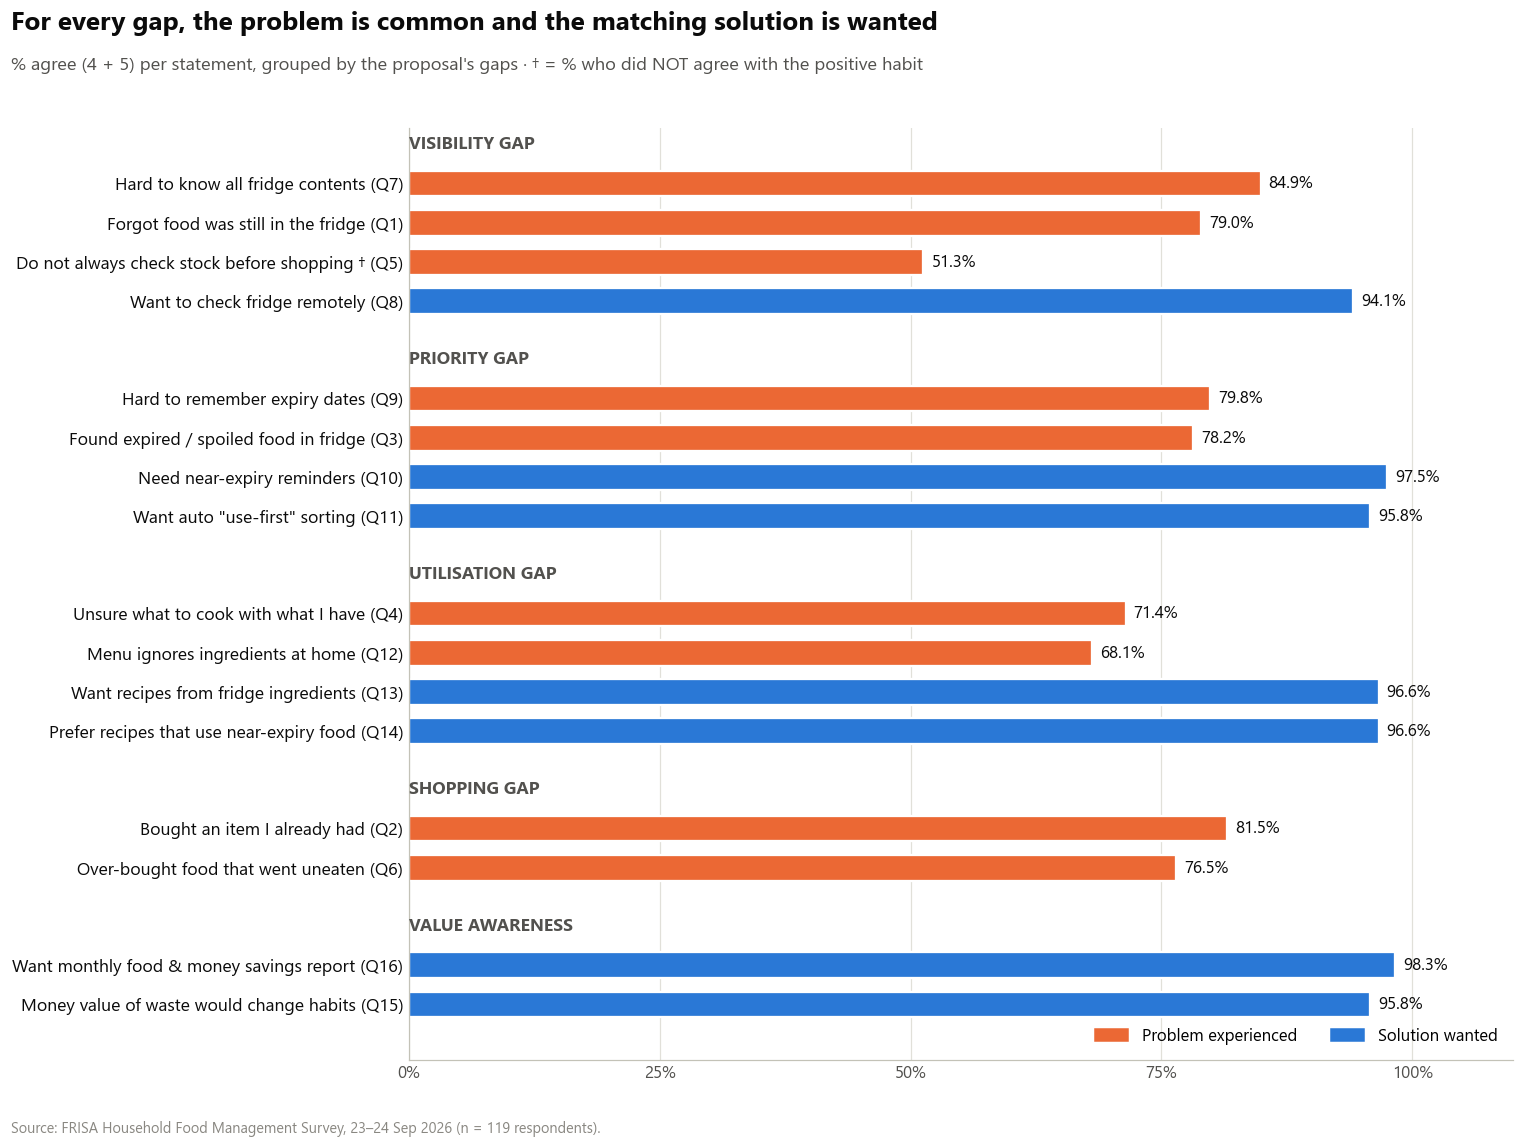

In [15]:
# Problem vs Need overview, grouped by theme
fig, ax = plt.subplots(figsize=(14, 10.5))
y, yt, ylab, hdr = 0, [], [], []
for th in THEMES:
    hdr.append((y, th)); y -= 1
    items = STMT[STMT.theme == th].copy()
    items['val'] = [share(~A.Q5) if c == 'Q5' else share(A[c]) for c in items.index]
    items['order'] = items.kind.map({'Problem': 0, 'Behaviour': 0, 'Need': 1})
    for c, r in items.sort_values(['order', 'val'], ascending=[True, False]).iterrows():
        is_need = r.kind == 'Need'
        label = 'Do not always check stock before shopping †' if c == 'Q5' else r.short
        ax.barh(y, r.val, color=NEED_C if is_need else PAIN_C, height=0.66, edgecolor=BG, linewidth=1.5)
        ax.text(r.val + 0.8, y, f'{r.val:.1f}%', va='center', fontsize=11, color=INK)
        yt.append(y); ylab.append(f'{label} ({c})'); y -= 1
    y -= 0.5
for yh, th in hdr:
    ax.text(0, yh, th.upper(), fontsize=11.5, fontweight='bold', color=INK2, va='center')
ax.set_yticks(yt); ax.set_yticklabels(ylab); ax.set_xlim(0, 110); ax.set_xticks([0, 25, 50, 75, 100])
pct_fmt(ax); clean_ax(ax, 'x')
ax.legend(handles=[Patch(color=PAIN_C, label='Problem experienced'), Patch(color=NEED_C, label='Solution wanted')],
          loc='lower right', ncol=2)
header(fig, 'For every gap, the problem is common and the matching solution is wanted',
       '% agree (4 + 5) per statement, grouped by the proposal\'s gaps · † = % who did NOT agree with the positive habit')
finish(fig, '09_problem_vs_solution_by_theme')

## 8. Solution demand: do people want what FRISA offers?

Seven statements describe FRISA's value propositions: remote fridge checks, expiry reminders, automatic "use-first" sorting, recipe recommendations, recipes that use near-expiry food, the money value of waste, and a monthly savings report.

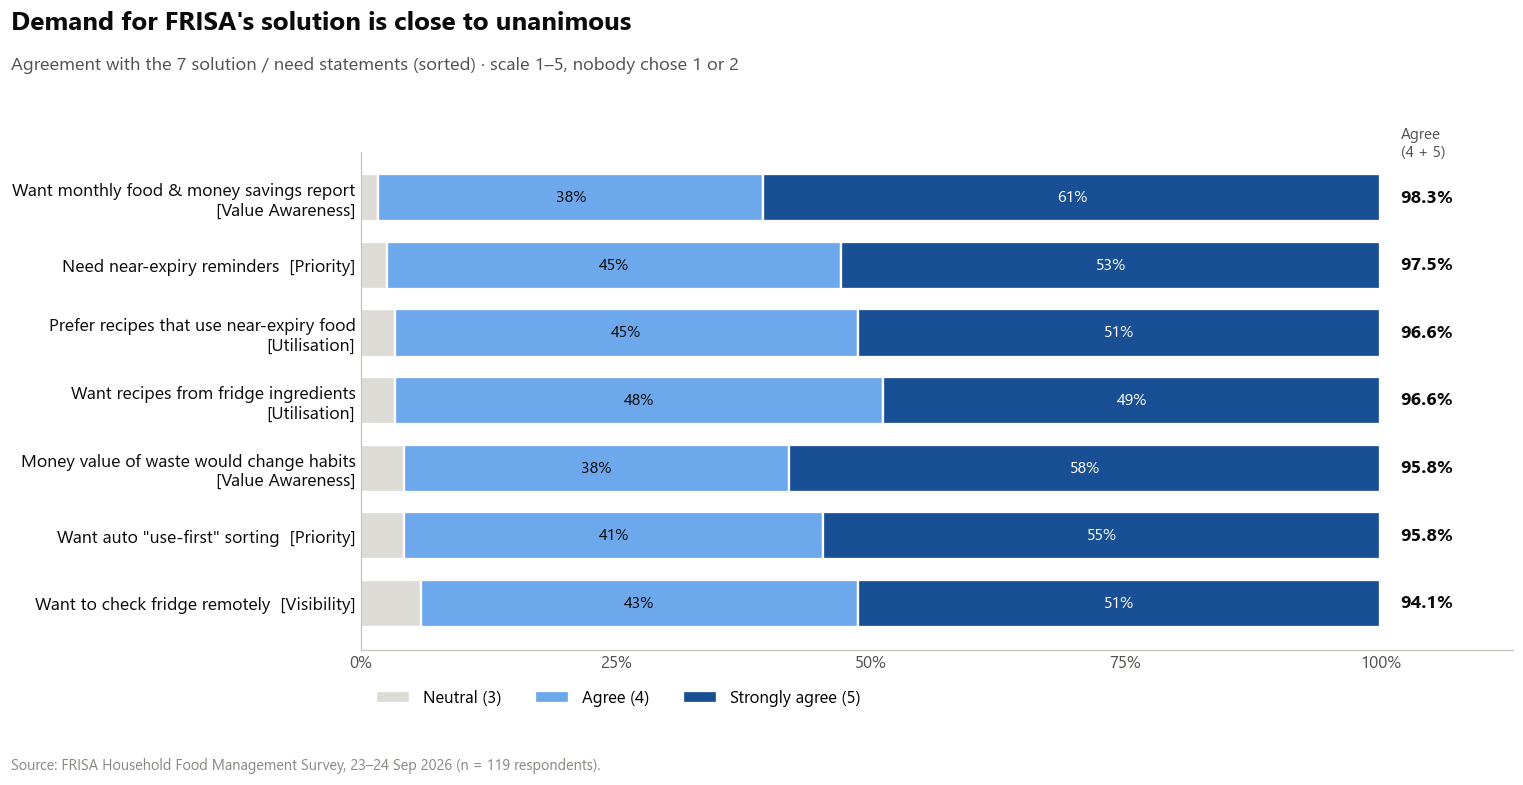

**Key takeaways**

- Every solution statement is supported by **94.1%–98.3%** of respondents, and **78.2%** agree with all seven.
- The strongest conviction is about **value visibility**: 60.5% *strongly* want a monthly food & money savings report and 58.0% say seeing the money value of waste would change their behaviour. This supports FRISA's **SAVE** step and **SDG Target 12.8** (information for sustainable lifestyles).
- Expiry reminders (97.5%) and automatic use-first sorting (95.8%) validate the **PRIORITISE** step.

In [16]:
fig, ax = plt.subplots(figsize=(14, 7.2))
need_dist = likert_stack(ax, NEED, lambda c: f'{SHORT[c]}  [{STMT.theme[c].replace(" Gap", "")}]')
header(fig, 'Demand for FRISA\'s solution is close to unanimous',
       'Agreement with the 7 solution / need statements (sorted) · scale 1–5, nobody chose 1 or 2')
finish(fig, '10_solution_demand_likert')

takeaways(
    f'Every solution statement is supported by **{need_dist.agree.min():.1f}%–{need_dist.agree.max():.1f}%** of respondents, and '
    f'**{share(df.need_count == len(NEED)):.1f}%** agree with all seven.',
    f'The strongest conviction is about **value visibility**: {share(T.Q16):.1f}% *strongly* want a monthly food & money savings report and '
    f'{share(T.Q15):.1f}% say seeing the money value of waste would change their behaviour. This supports FRISA\'s **SAVE** step and '
    '**SDG Target 12.8** (information for sustainable lifestyles).',
    f'Expiry reminders ({share(A.Q10):.1f}%) and automatic use-first sorting ({share(A.Q11):.1f}%) validate the **PRIORITISE** step.',
)

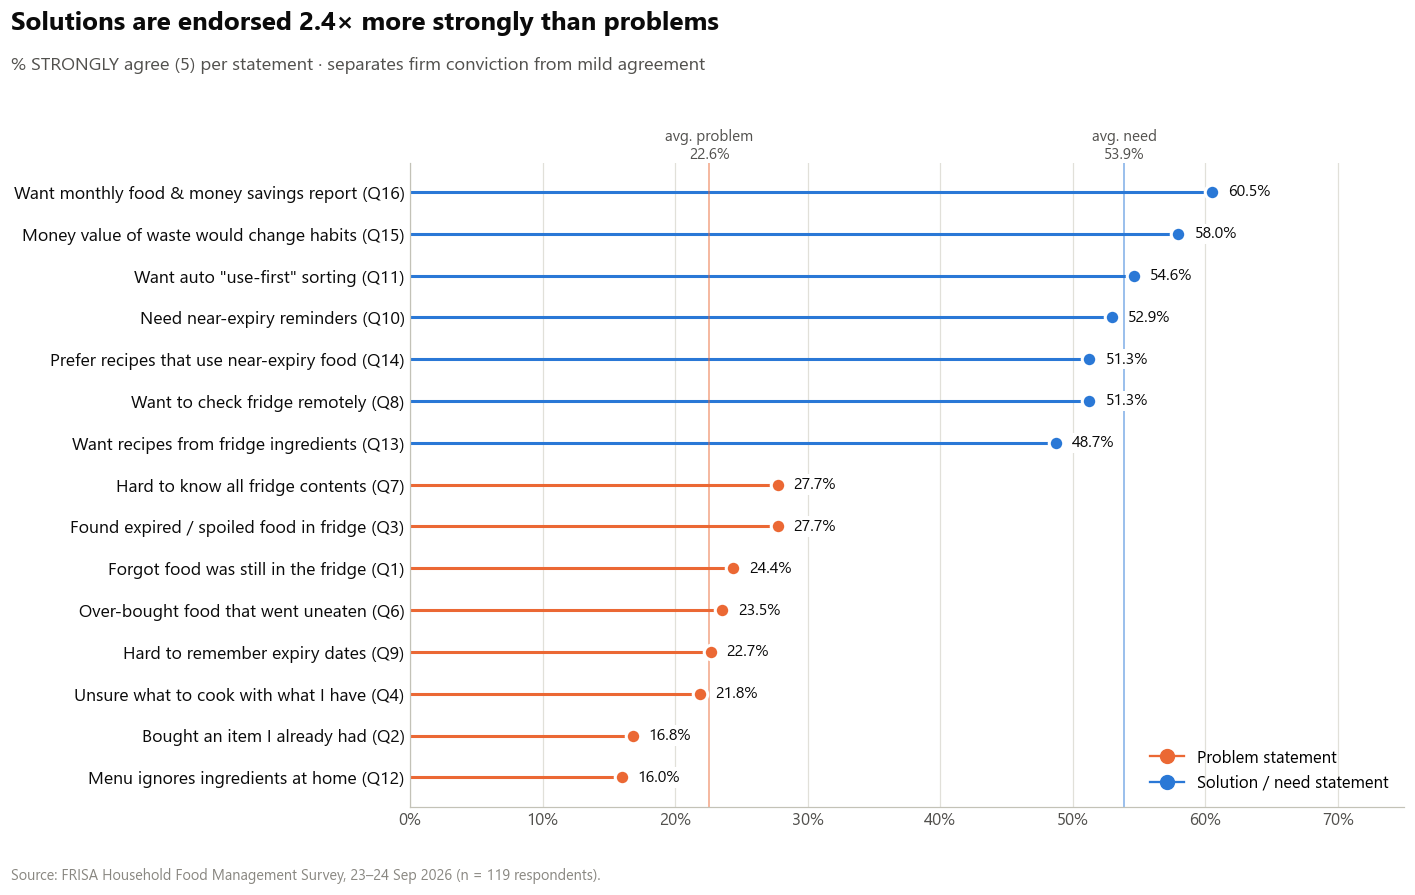

**Key takeaways**

- On average **22.6%** *strongly* agree with a problem statement, compared with **53.9%** for a solution statement.
- People admit the problems mildly ("yes, that happens") but back the solutions firmly ("yes, I want that"). This is a useful sign of product-market pull. When pitching, lead with the **benefit** (reminders, savings, recipes) rather than making people feel guilty about waste.
- The Q5 behaviour statement is excluded here because agreeing with it is the positive answer.

In [17]:
tb = pd.Series({c: share(T[c]) for c in PAIN + NEED}).sort_values()
fig, ax = plt.subplots(figsize=(13, 8.2))
for i, (c, v) in enumerate(tb.items()):
    colr = NEED_C if c in NEED else PAIN_C
    ax.plot([0, v], [i, i], color=colr, linewidth=2, solid_capstyle='round')
    ax.scatter(v, i, s=90, color=colr, zorder=3, edgecolor=BG, linewidth=2)
    ax.text(v + 1.2, i, f'{v:.1f}%', va='center', fontsize=10.5, color=INK, zorder=4,
            bbox=dict(facecolor=BG, edgecolor='none', pad=1.5))
ax.set_yticks(range(len(tb))); ax.set_yticklabels([f'{SHORT[c]} ({c})' for c in tb.index])
avg_pain, avg_need = tb[PAIN].mean(), tb[NEED].mean()
for v, colr, lbl in [(avg_pain, PAIN_C, 'avg. problem'), (avg_need, NEED_C, 'avg. need')]:
    ax.axvline(v, color=colr, linewidth=1, alpha=0.6)
    ax.text(v, len(tb) - 0.3, f'{lbl}\n{v:.1f}%', color=INK2, fontsize=10, ha='center', va='bottom')
ax.set_xlim(0, 75); pct_fmt(ax); clean_ax(ax, 'x')
ax.legend(handles=[Line2D([], [], marker='o', color=PAIN_C, label='Problem statement', markersize=9),
                   Line2D([], [], marker='o', color=NEED_C, label='Solution / need statement', markersize=9)], loc='lower right')
header(fig, f'Solutions are endorsed {avg_need / avg_pain:.1f}× more strongly than problems',
       '% STRONGLY agree (5) per statement · separates firm conviction from mild agreement', )
finish(fig, '11_conviction_strongly_agree')

takeaways(
    f'On average **{avg_pain:.1f}%** *strongly* agree with a problem statement, compared with **{avg_need:.1f}%** for a solution statement.',
    'People admit the problems mildly ("yes, that happens") but back the solutions firmly ("yes, I want that"). '
    'This is a useful sign of product-market pull. When pitching, lead with the **benefit** (reminders, savings, recipes) '
    'rather than making people feel guilty about waste.',
    'The Q5 behaviour statement is excluded here because agreeing with it is the positive answer.',
)

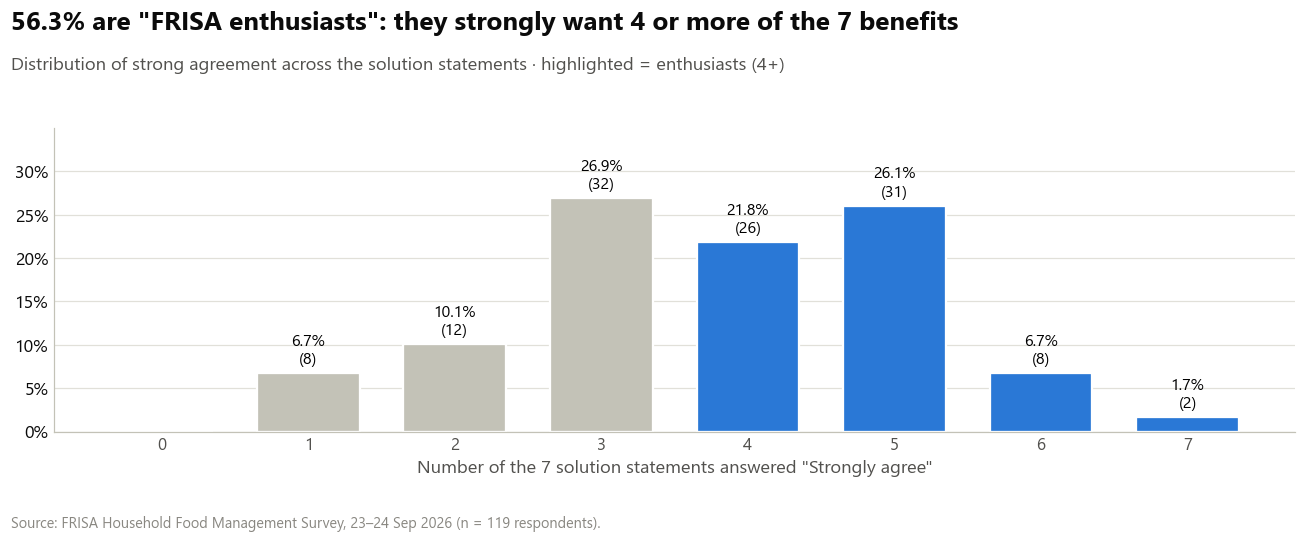

In [18]:
sc = df.need_strong_count.value_counts().reindex(range(0, 8), fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sc.index, sc.values / N * 100, color=[BLUE if k >= 4 else GREY for k in sc.index], width=0.7, edgecolor=BG, linewidth=1.5)
for b_, c in zip(bars, sc.values):
    if c:
        ax.text(b_.get_x() + b_.get_width() / 2, b_.get_height() + 0.6, f'{c / N * 100:.1f}%\n({c})', ha='center', va='bottom', fontsize=10.5)
ax.set_xticks(range(0, 8)); ax.set_xlabel('Number of the 7 solution statements answered "Strongly agree"')
ax.set_ylim(0, sc.max() / N * 100 * 1.3); pct_fmt(ax, 'y'); clean_ax(ax, 'y')
enth = share(df.need_strong_count >= 4)
header(fig, f'{enth:.1f}% are "FRISA enthusiasts": they strongly want 4 or more of the 7 benefits',
       'Distribution of strong agreement across the solution statements · highlighted = enthusiasts (4+)')
finish(fig, '12_enthusiast_distribution')

## 9. Feature priorities: what should FRISA launch with?

Respondents picked **up to 3 features** they found most useful, and every respondent picked exactly 3. Because the choice was limited, this question separates must-have features from nice-to-have ones better than the Likert statements do.

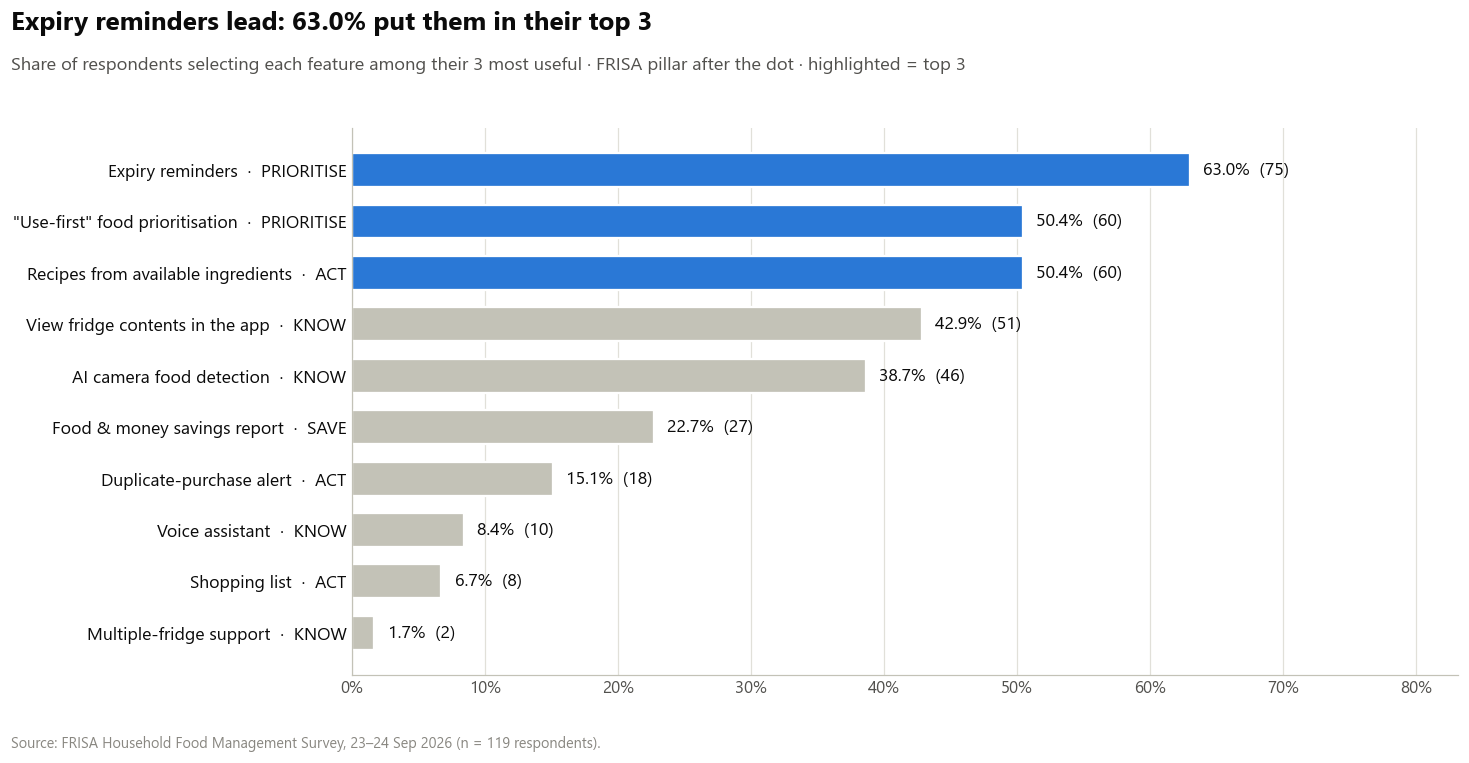

**Key takeaways**

- **Must-haves (top 3):** Expiry reminders (63.0%), "Use-first" food prioritisation (50.4%), Recipes from available ingredients (50.4%). All three help households use food in time (PRIORITISE and ACT), which makes them the core of the MVP and of the marketing message.
- **Strong second tier:** View fridge contents in the app (42.9%) and AI camera food detection (38.7%). These make up the KNOW layer that powers everything else.
- **Low priority:** Voice assistant (8.4%), Shopping list (6.7%) and Multiple-fridge support (1.7%). Keep them as supporting or premium features, not headline benefits.

In [19]:
fc = FEAT.sum().sort_values(ascending=False)
top3 = fc.index[:3].tolist()
fig, ax = plt.subplots(figsize=(13.5, 7))
barh_share(ax, fc.rename(lambda k: f'{FEAT_LABEL[k]}  ·  {FEAT_PILLAR[k]}'), N,
           highlight=[f'{FEAT_LABEL[k]}  ·  {FEAT_PILLAR[k]}' for k in top3], wrap_width=48, fontsize=11.5)
header(fig, f'Expiry reminders lead: {share(FEAT.reminder):.1f}% put them in their top 3',
       'Share of respondents selecting each feature among their 3 most useful · FRISA pillar after the dot · highlighted = top 3')
finish(fig, '13_feature_ranking')

takeaways(
    f'**Must-haves (top 3):** {", ".join(f"{FEAT_LABEL[k]} ({share(FEAT[k]):.1f}%)" for k in top3)}. '
    'All three help households use food in time (PRIORITISE and ACT), which makes them the core of the MVP and of the marketing message.',
    f'**Strong second tier:** {FEAT_LABEL["app_view"]} ({share(FEAT.app_view):.1f}%) and {FEAT_LABEL["camera"]} ({share(FEAT.camera):.1f}%). '
    'These make up the KNOW layer that powers everything else.',
    f'**Low priority:** {FEAT_LABEL["voice"]} ({share(FEAT.voice):.1f}%), {FEAT_LABEL["shopping_list"]} ({share(FEAT.shopping_list):.1f}%) and '
    f'{FEAT_LABEL["multi_fridge"]} ({share(FEAT.multi_fridge):.1f}%). Keep them as supporting or premium features, not headline benefits.',
)

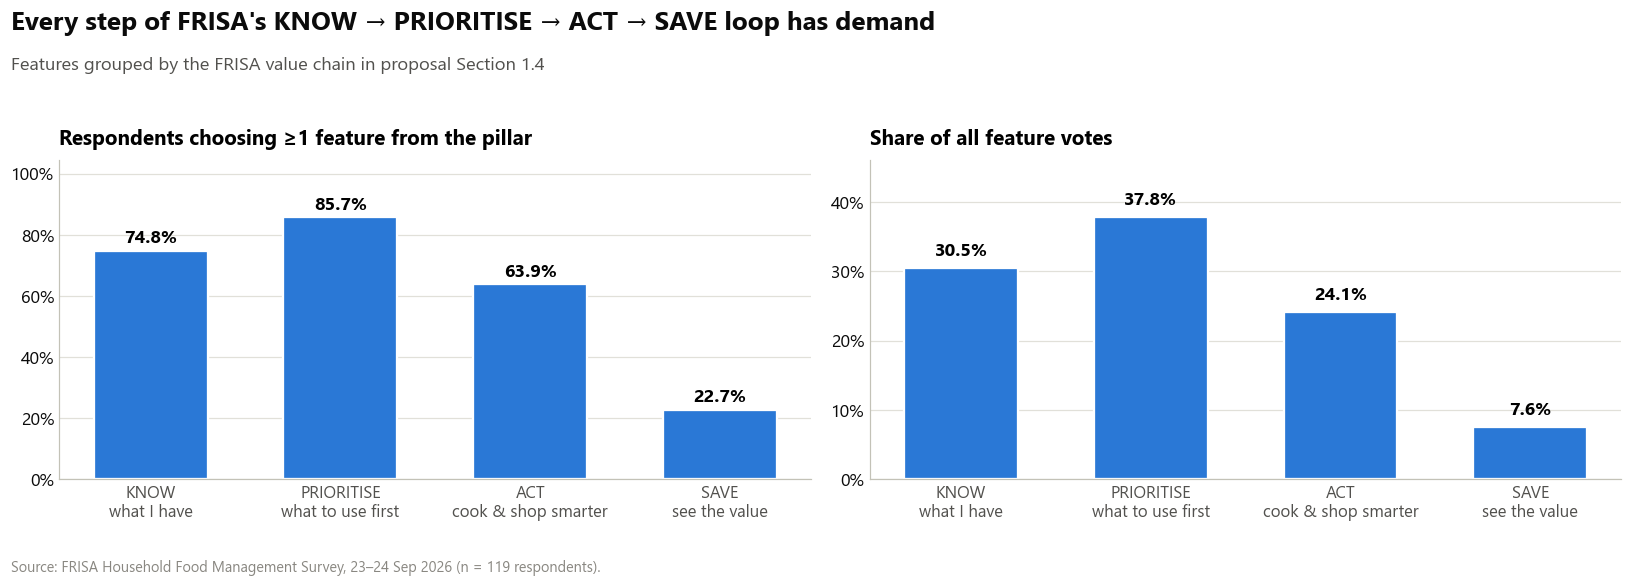

**Key takeaways**

- **PRIORITISE** gets the most votes (37.8%) and is chosen by 85.7% of respondents. Expiry awareness is what people most want to fix.
- **KNOW** (74.8%) and **ACT** (63.9%) are each chosen by most respondents. The loop only works if inventory data (KNOW) feeds the reminders and recipes.
- **SAVE** is picked by only 22.7% as a top-3 feature, even though 98.3% agree they want the savings report (Section 8). People like the report, but it is not why they would buy FRISA. Use it to keep users engaged (monthly report) rather than to acquire them.

In [20]:
pillar_any = pd.Series({p: share(FEAT[[k for k in FEAT_KEYS if FEAT_PILLAR[k] == p]].any(axis=1)) for p in PILLARS})
pillar_votes = pd.Series({p: FEAT[[k for k in FEAT_KEYS if FEAT_PILLAR[k] == p]].values.sum() for p in PILLARS})
pillar_votes_pct = pillar_votes / pillar_votes.sum() * 100
PILLAR_DESC = {'KNOW': 'KNOW\nwhat I have', 'PRIORITISE': 'PRIORITISE\nwhat to use first', 'ACT': 'ACT\ncook & shop smarter', 'SAVE': 'SAVE\nsee the value'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
for ax, s, ttl, sub in [(axes[0], pillar_any, 'Respondents choosing ≥1 feature from the pillar', '% of respondents'),
                        (axes[1], pillar_votes_pct, 'Share of all feature votes', f'% of {pillar_votes.sum()} votes')]:
    bars = ax.bar([PILLAR_DESC[p] for p in PILLARS], s.values, color=BLUE, width=0.6, edgecolor=BG, linewidth=1.5)
    for b_, v in zip(bars, s.values):
        ax.text(b_.get_x() + b_.get_width() / 2, v + 1.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylim(0, s.max() * 1.22); pct_fmt(ax, 'y'); clean_ax(ax, 'y')
    ax.set_title(ttl, loc='left', fontsize=13.5, fontweight='bold', pad=10)
header(fig, 'Every step of FRISA\'s KNOW → PRIORITISE → ACT → SAVE loop has demand',
       'Features grouped by the FRISA value chain in proposal Section 1.4')
finish(fig, '14_feature_pillars')

takeaways(
    f'**PRIORITISE** gets the most votes ({pillar_votes_pct["PRIORITISE"]:.1f}%) and is chosen by {pillar_any["PRIORITISE"]:.1f}% of respondents. '
    'Expiry awareness is what people most want to fix.',
    f'**KNOW** ({pillar_any["KNOW"]:.1f}%) and **ACT** ({pillar_any["ACT"]:.1f}%) are each chosen by most respondents. The loop only works '
    'if inventory data (KNOW) feeds the reminders and recipes.',
    f'**SAVE** is picked by only {pillar_any["SAVE"]:.1f}% as a top-3 feature, even though {share(A.Q16):.1f}% agree they want the savings report (Section 8). '
    'People like the report, but it is not why they would buy FRISA. Use it to keep users engaged (monthly report) rather than to acquire them.',
)

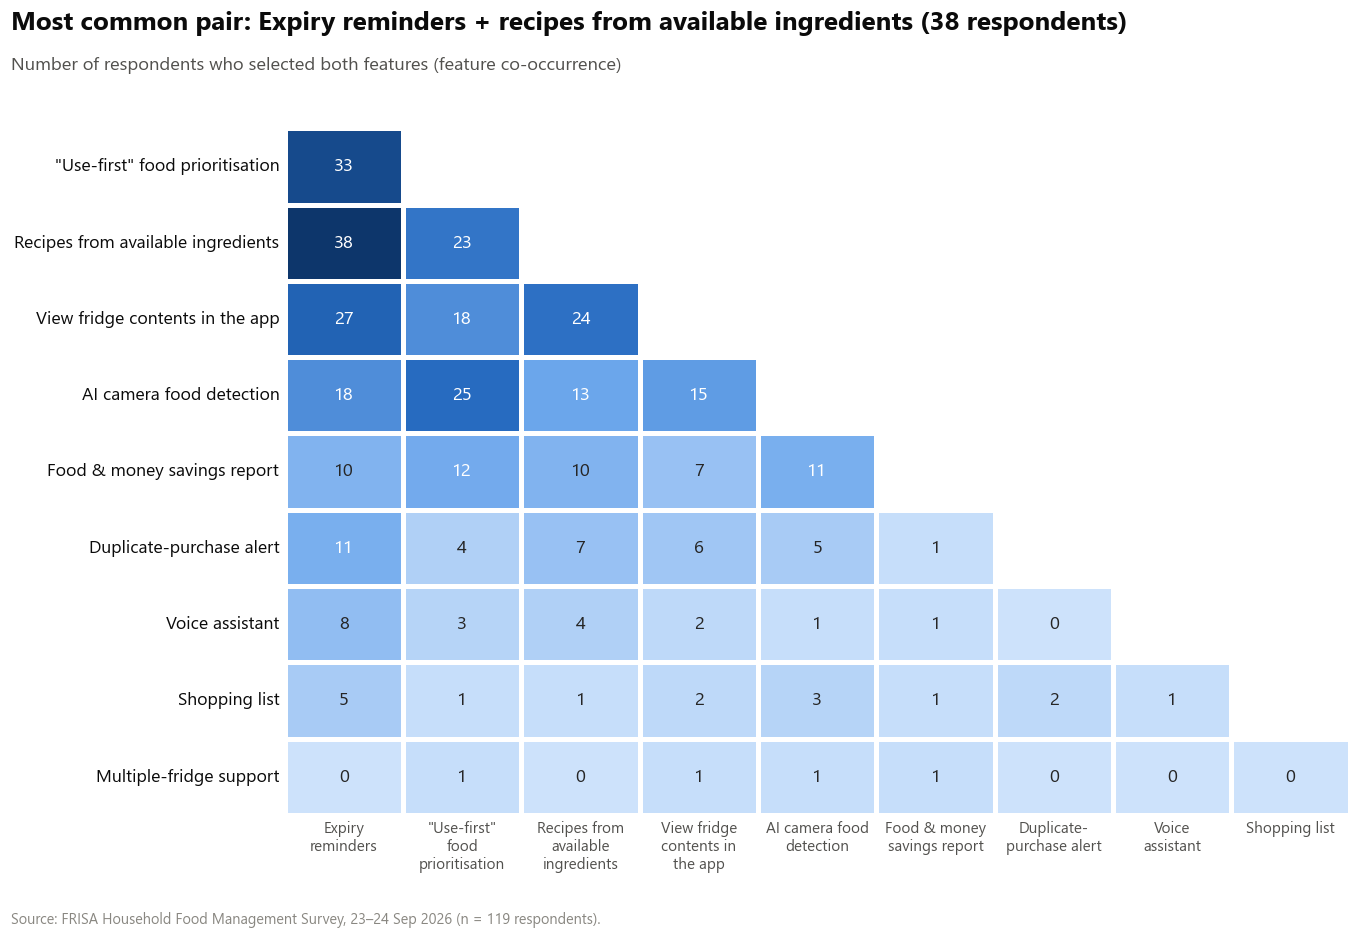

Top feature pairs (lift > 1 = chosen together more often than chance):


Feature pair,Respondents,% of respondents,Lift
Expiry reminders + Recipes from available ingredients,38,31.9%,1.00
"Expiry reminders + ""Use-first"" food prioritisation",33,27.7%,0.87
Expiry reminders + View fridge contents in the app,27,22.7%,0.84
"""Use-first"" food prioritisation + AI camera food detection",25,21.0%,1.08
Recipes from available ingredients + View fridge contents in the app,24,20.2%,0.93
"""Use-first"" food prioritisation + Recipes from available ingredients",23,19.3%,0.76
Expiry reminders + AI camera food detection,18,15.1%,0.62
"""Use-first"" food prioritisation + View fridge contents in the app",18,15.1%,0.70


In [21]:
co = FEAT.T.dot(FEAT)
order = fc.index.tolist()
co = co.loc[order, order]
co_plot = co.iloc[1:, :-1]                      # lower triangle only: drop the empty first row / last column
mask = np.triu(np.ones_like(co_plot, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12.5, 8.6))
sns.heatmap(co_plot, mask=mask, annot=True, fmt='d', cmap=SEQ, linewidths=2, linecolor=BG, cbar=False, ax=ax,
            annot_kws={'fontsize': 12})
ax.set_xticklabels([wrap(FEAT_LABEL[k], 14) for k in co_plot.columns], rotation=0, fontsize=10)
ax.set_yticklabels([FEAT_LABEL[k] for k in co_plot.index], rotation=0)
ax.tick_params(length=0)
top_pair = co.where(np.tril(np.ones_like(co, dtype=bool), -1)).stack().sort_values(ascending=False)
(a1, b1), (a2, b2) = top_pair.index[0], top_pair.index[1]
header(fig, f'Most common pair: {FEAT_LABEL[b1]} + {FEAT_LABEL[a1].lower()} ({int(top_pair.iloc[0])} respondents)',
       'Number of respondents who selected both features (feature co-occurrence)')
finish(fig, '15_feature_cooccurrence')

pairs = []
for a, b in combinations(FEAT_KEYS, 2):
    both = (FEAT[a] & FEAT[b]).sum()
    if both >= 5:
        lift = (both / N) / (FEAT[a].mean() * FEAT[b].mean())
        pairs.append((f'{FEAT_LABEL[a]} + {FEAT_LABEL[b]}', both, both / N * 100, lift))
pairs = pd.DataFrame(pairs, columns=['Feature pair', 'Respondents', '% of respondents', 'Lift']).sort_values('Respondents', ascending=False)
print('Top feature pairs (lift > 1 = chosen together more often than chance):')
display(pairs.head(8).style.hide(axis='index').format({'% of respondents': '{:.1f}%', 'Lift': '{:.2f}'}))

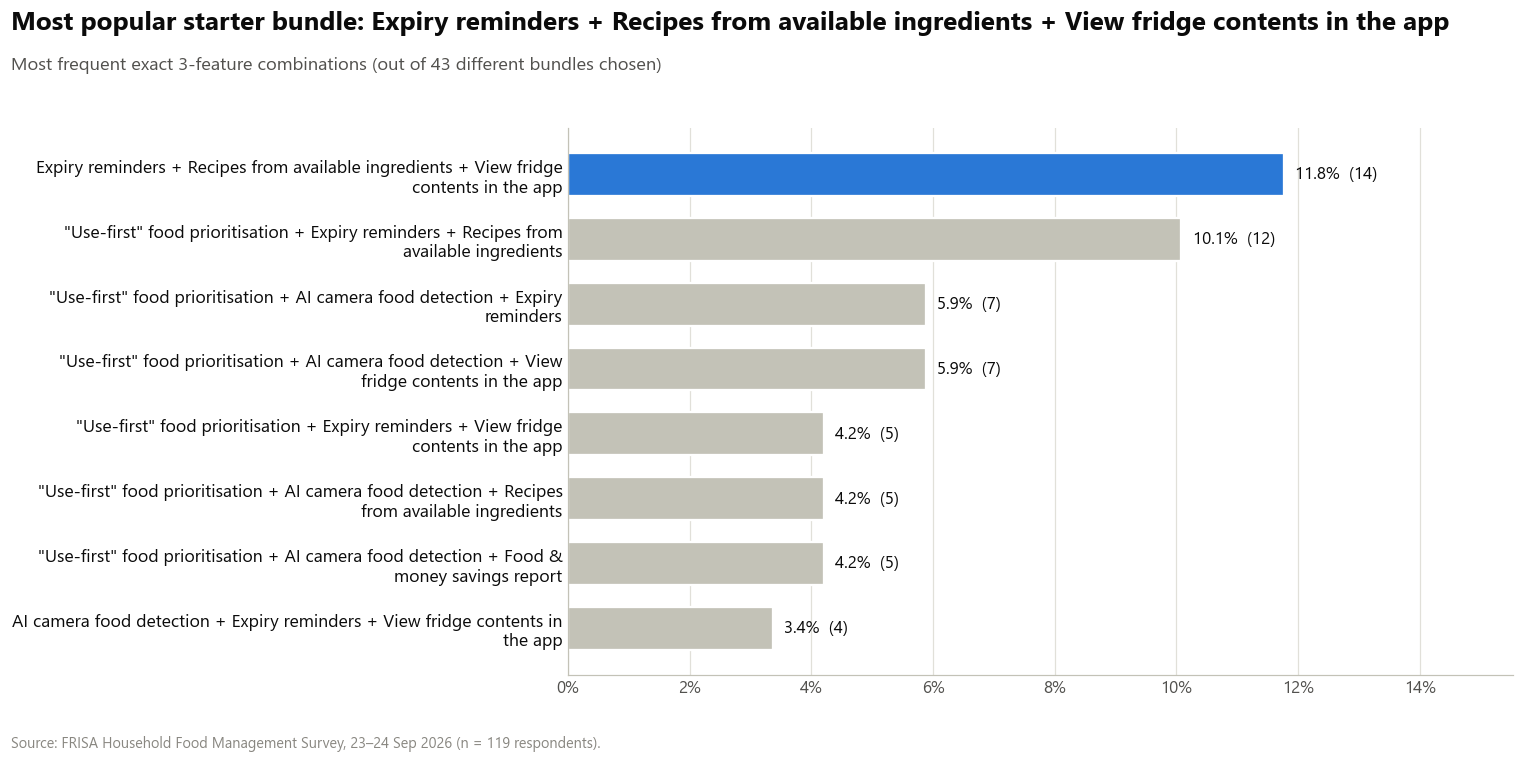

**Key takeaways**

- The most popular exact bundle, **Expiry reminders + Recipes from available ingredients + View fridge contents in the app**, is chosen by 14 respondents (11.8%). This set covers the whole "use it before you lose it" job and would make a strong free / basic tier.
- Preferences are spread out (43 different bundles among 119 people), so FRISA should let users choose their main dashboard widgets rather than force one home screen.

In [22]:
bundles = df.feature_list.apply(lambda ks: ' + '.join(sorted(FEAT_LABEL[k] for k in ks))).value_counts()
fig, ax = plt.subplots(figsize=(14, 7))
barh_share(ax, bundles.head(8), N, wrap_width=70, highlight=[bundles.index[0]])
header(fig, f'Most popular starter bundle: {bundles.index[0]}',
       f'Most frequent exact 3-feature combinations (out of {bundles.size} different bundles chosen)')
finish(fig, '16_feature_bundles')

takeaways(
    f'The most popular exact bundle, **{bundles.index[0]}**, is chosen by {bundles.iloc[0]} respondents ({bundles.iloc[0] / N * 100:.1f}%). '
    'This set covers the whole "use it before you lose it" job and would make a strong free / basic tier.',
    f'Preferences are spread out ({bundles.size} different bundles among {N} people), so FRISA should let users choose their main '
    'dashboard widgets rather than force one home screen.',
)

## 10. Word frequency: what words dominate respondents' choices?

The dataset has no free-text answers, so the word analysis uses the English text of the options respondents chose: their 3 features plus their preferred input method. Each word is counted once per time it appears in a chosen option, so frequent words show where the respondents' attention is.

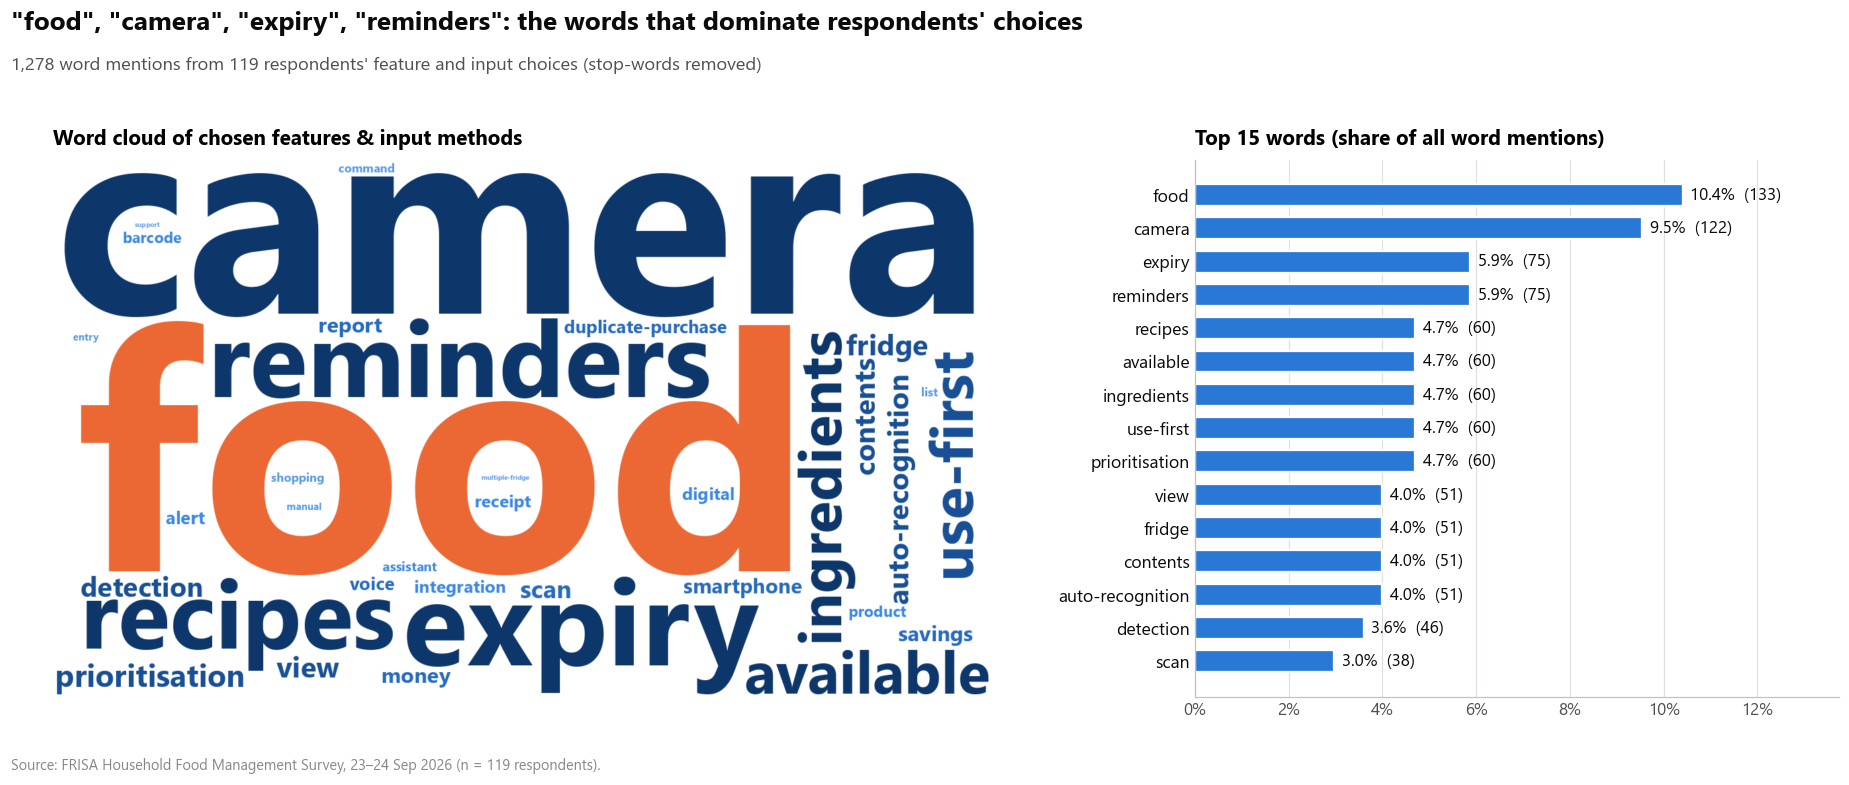

Most frequent two-word phrases:


Phrase,Mentions
expiry reminders,75
recipes available,60
available ingredients,60
use-first food,60
food prioritisation,60
view fridge,51
fridge contents,51
camera auto-recognition,51
camera food,46
food detection,46


**Key takeaways**

- The most frequent words, **food, camera, expiry, reminders, recipes**, describe FRISA's core idea: *see* food with a camera and act on *expiry*.
- "Camera" ranks high because it appears in both the feature choices (AI detection) and the input-method choices. This supports putting the camera at the centre of the hardware story.
- Suggested tagline vocabulary: *"See your food. Use it before it expires. Cook what you have."*

In [23]:
STOP = {'and', 'the', 'in', 'from', 'of', 'to', 'a', 'for', 'with', 'into', 'app', 'frisa'}
def tokens(text):
    return [w for w in re.findall(r'[a-z]+(?:-[a-z]+)?', text.lower()) if w not in STOP and len(w) > 2]

corpus = []
for ks, im in zip(df.feature_list, df.input_method.astype(str)):
    for k in ks:
        corpus += tokens(FEAT_LABEL[k])
    corpus += tokens(im)
wf = Counter(corpus)
top_words = pd.Series(dict(wf.most_common(15)))

ranked = [w for w, _ in wf.most_common()]
def color_func(word, **kw):
    r = ranked.index(word) / max(len(ranked) - 1, 1)
    steps = [RAMP[700], RAMP[600], RAMP[500], RAMP[400], RAMP[350]]
    return ORANGE if r == 0 else steps[min(int(r * len(steps)), len(steps) - 1)]

wc = WordCloud(width=1400, height=800, background_color=BG, prefer_horizontal=0.95, max_words=60,
               font_path='C:/Windows/Fonts/segoeuib.ttf' if Path('C:/Windows/Fonts/segoeuib.ttf').exists() else None,
               color_func=color_func, random_state=7, margin=6).generate_from_frequencies(wf)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.2), gridspec_kw={'width_ratios': [1.6, 1]})
axes[0].imshow(wc, interpolation='bilinear'); axes[0].set_axis_off()
axes[0].set_title('Word cloud of chosen features & input methods', loc='left', fontsize=13.5, fontweight='bold', pad=10)
barh_share(axes[1], top_words, len(corpus), wrap_width=20)
axes[1].set_title('Top 15 words (share of all word mentions)', loc='left', fontsize=13.5, fontweight='bold', pad=10)
header(fig, ', '.join(f'"{w}"' for w in top_words.index[:4]) + ': the words that dominate respondents\' choices',
       f'{len(corpus):,} word mentions from 119 respondents\' feature and input choices (stop-words removed)')
finish(fig, '17_word_frequency')

bigrams = Counter()
for ks, im in zip(df.feature_list, df.input_method.astype(str)):
    for text in [FEAT_LABEL[k] for k in ks] + [im]:
        t = tokens(text)
        bigrams.update(' '.join(p) for p in zip(t, t[1:]))
print('Most frequent two-word phrases:')
display(pd.DataFrame(bigrams.most_common(10), columns=['Phrase', 'Mentions']).style.hide(axis='index'))

takeaways(
    f'The most frequent words, **{", ".join(top_words.index[:5])}**, describe FRISA\'s core idea: *see* food with a camera and act on *expiry*.',
    '"Camera" ranks high because it appears in both the feature choices (AI detection) and the input-method choices. '
    'This supports putting the camera at the centre of the hardware story.',
    'Suggested tagline vocabulary: *"See your food. Use it before it expires. Cook what you have."*',
)

## 11. Input method: how do people want to log food?

Logging is where many inventory apps fail, because users stop entering items by hand. FRISA's AI camera exists to remove that effort. This section checks whether respondents want it.

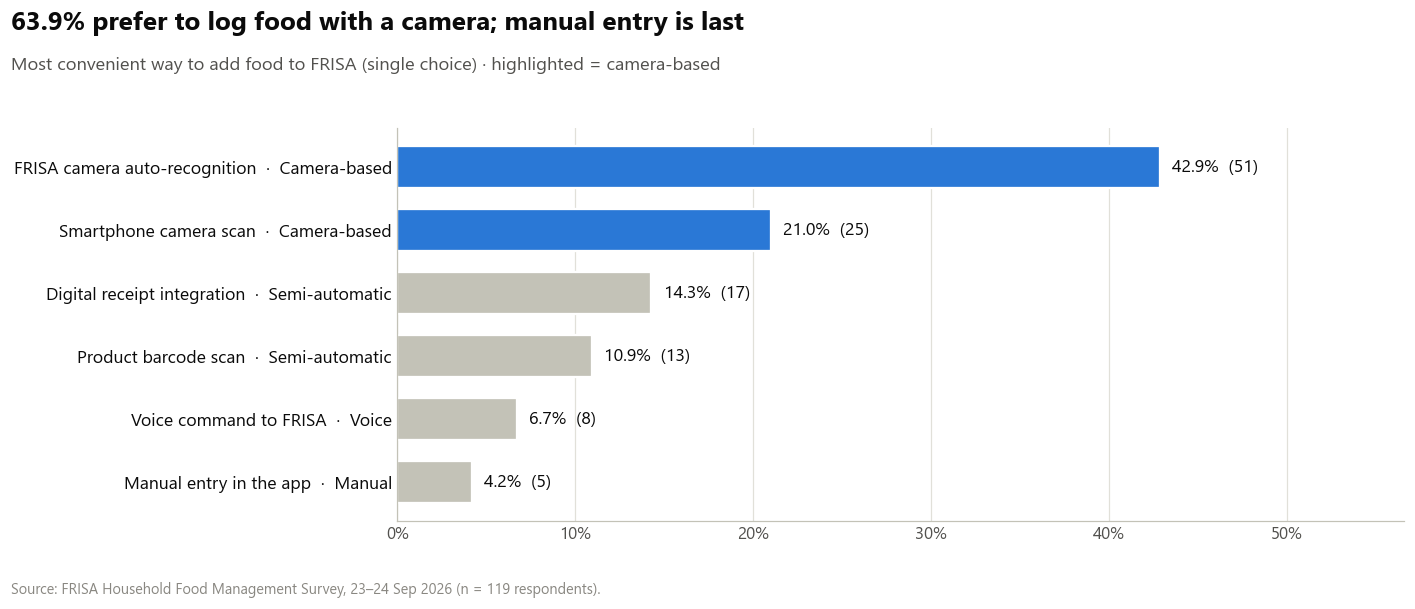

**Key takeaways**

- **42.9%** choose FRISA's own camera recognising food automatically, the product's core hardware feature. With smartphone scanning added, **63.9%** prefer a camera.
- **Semi-automatic options** (digital receipt, barcode) attract 25.2%. Receipt integration (14.3%) is a good fit for the planned e-grocery partnerships.
- Only **4.2%** want to type items in by hand and **6.7%** prefer voice. Automatic capture is essential. Voice should support the camera as a way to confirm or query items, not be the main way to log food.

In [24]:
ic = df.input_method.value_counts().reindex(INPUT_ORDER)
cam = [m for m in INPUT_ORDER if INPUT_TYPE[m] == 'Camera-based']
fig, ax = plt.subplots(figsize=(13, 5.6))
barh_share(ax, ic.rename(lambda m: f'{m}  ·  {INPUT_TYPE[m]}'), N, highlight=[f'{m}  ·  {INPUT_TYPE[m]}' for m in cam], wrap_width=48, fontsize=11.5)
header(fig, f'{camera_share:.1f}% prefer to log food with a camera; manual entry is last',
       'Most convenient way to add food to FRISA (single choice) · highlighted = camera-based')
finish(fig, '18_input_method')

takeaways(
    f'**{share(df.input_method == "FRISA camera auto-recognition"):.1f}%** choose FRISA\'s own camera recognising food automatically, the product\'s '
    f'core hardware feature. With smartphone scanning added, **{camera_share:.1f}%** prefer a camera.',
    f'**Semi-automatic options** (digital receipt, barcode) attract {share(df.input_type == "Semi-automatic"):.1f}%. Receipt integration '
    f'({share(df.input_method == "Digital receipt integration"):.1f}%) is a good fit for the planned e-grocery partnerships.',
    f'Only **{share(df.input_type == "Manual"):.1f}%** want to type items in by hand and **{share(df.input_type == "Voice"):.1f}%** prefer voice. '
    'Automatic capture is essential. Voice should support the camera as a way to confirm or query items, not be the main way to log food.',
)

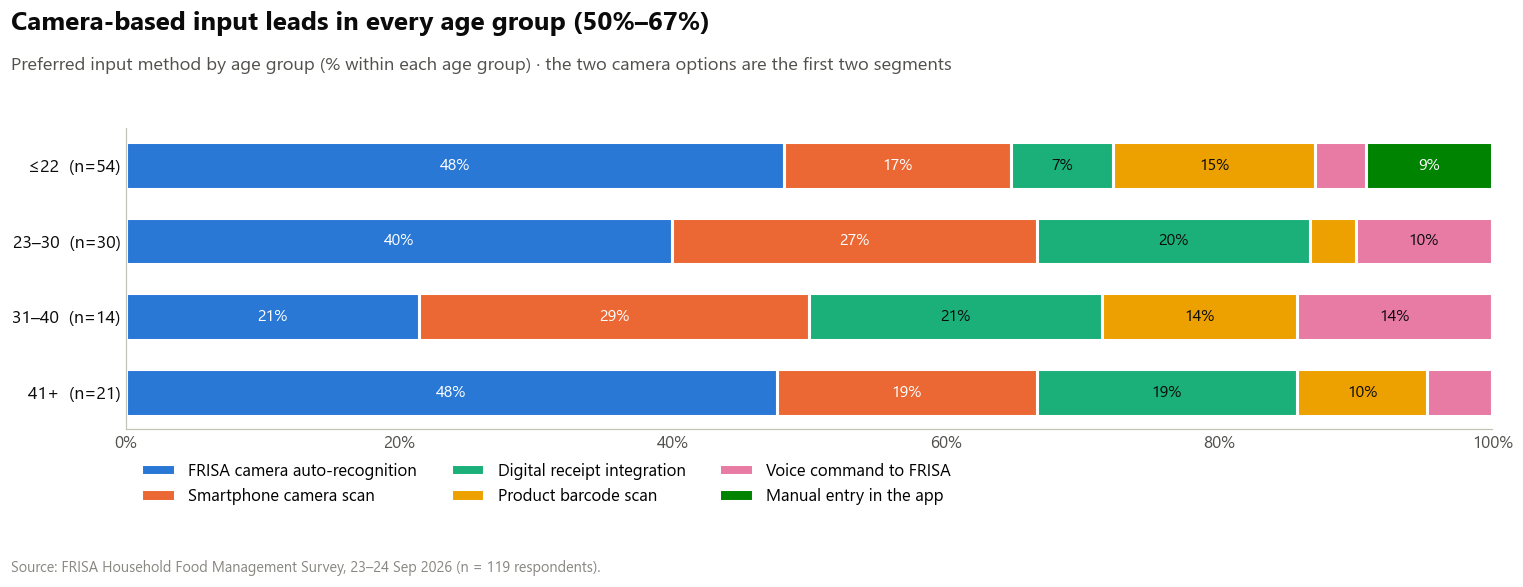

**Key takeaways**

- Camera-based input (FRISA camera + smartphone scan) is chosen by 50%–67% of every age group. FRISA's own camera is the single most chosen method in 3 of 4 age groups (31–40: smartphone camera scan leads).
- Manual entry is chosen only by the youngest group (5 respondents, all ≤22).
- Chi-square test of input type × age group: χ² = 10.0, p = 0.35. The differences are not statistically meaningful, so a camera-first design suits all ages.

In [25]:
seg = pd.crosstab(df.age_group, df.input_method, normalize='index').reindex(columns=INPUT_ORDER) * 100
nsz = df.age_group.value_counts().reindex(AGEG_ORDER)
fig, ax = plt.subplots(figsize=(14, 5.4))
left = np.zeros(len(seg))
ylab = [f'{g}  (n={nsz[g]})' for g in seg.index]
for i, m in enumerate(INPUT_ORDER):
    vals = seg[m].values
    ax.barh(ylab, vals, left=left, color=CAT[i], height=0.62, edgecolor=BG, linewidth=2, label=m)
    for j, (l, v) in enumerate(zip(left, vals)):
        if v >= 7:
            ax.text(l + v / 2, j, f'{v:.0f}%', ha='center', va='center', fontsize=10.5, color='white' if i in (0, 1, 5) else INK)
    left += vals
ax.invert_yaxis(); ax.set_xlim(0, 100); pct_fmt(ax); clean_ax(ax, None)
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.06), ncol=3)
cam_age = pd.crosstab(df.age_group, df.input_type, normalize='index')['Camera-based'].reindex(AGEG_ORDER) * 100
header(fig, f'Camera-based input leads in every age group ({cam_age.min():.0f}%–{cam_age.max():.0f}%)',
       'Preferred input method by age group (% within each age group) · the two camera options are the first two segments')
finish(fig, '19_input_method_by_age')

chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df.age_group, df.input_type))
takeaways(
    f'Camera-based input (FRISA camera + smartphone scan) is chosen by {cam_age.min():.0f}%–{cam_age.max():.0f}% of every age group. '
    f'FRISA\'s own camera is the single most chosen method in {int((seg.idxmax(axis=1) == INPUT_ORDER[0]).sum())} of {len(seg)} age groups'
    + ('' if (seg.idxmax(axis=1) == INPUT_ORDER[0]).all() else
       ' (' + ', '.join(f'{g}: {m.lower()} leads' for g, m in seg.idxmax(axis=1).items() if m != INPUT_ORDER[0]) + ')') + '.',
    f'Manual entry is chosen only by the youngest group ({(df.input_type == "Manual").sum()} respondents, all ≤22).',
    f'Chi-square test of input type × age group: χ² = {chi2:.1f}, p = {p:.2f}. The differences are not statistically meaningful, so a camera-first '
    'design suits all ages.',
)

## 12. Segment deep-dive: does it differ by respondent characteristics?

Here the 16 statements and 10 features are broken down by **age, living arrangement, household size, fridge type, shopping involvement, food spend and region**. Each column header shows the group size (`n`). Treat groups with n < 10 as indicative only.

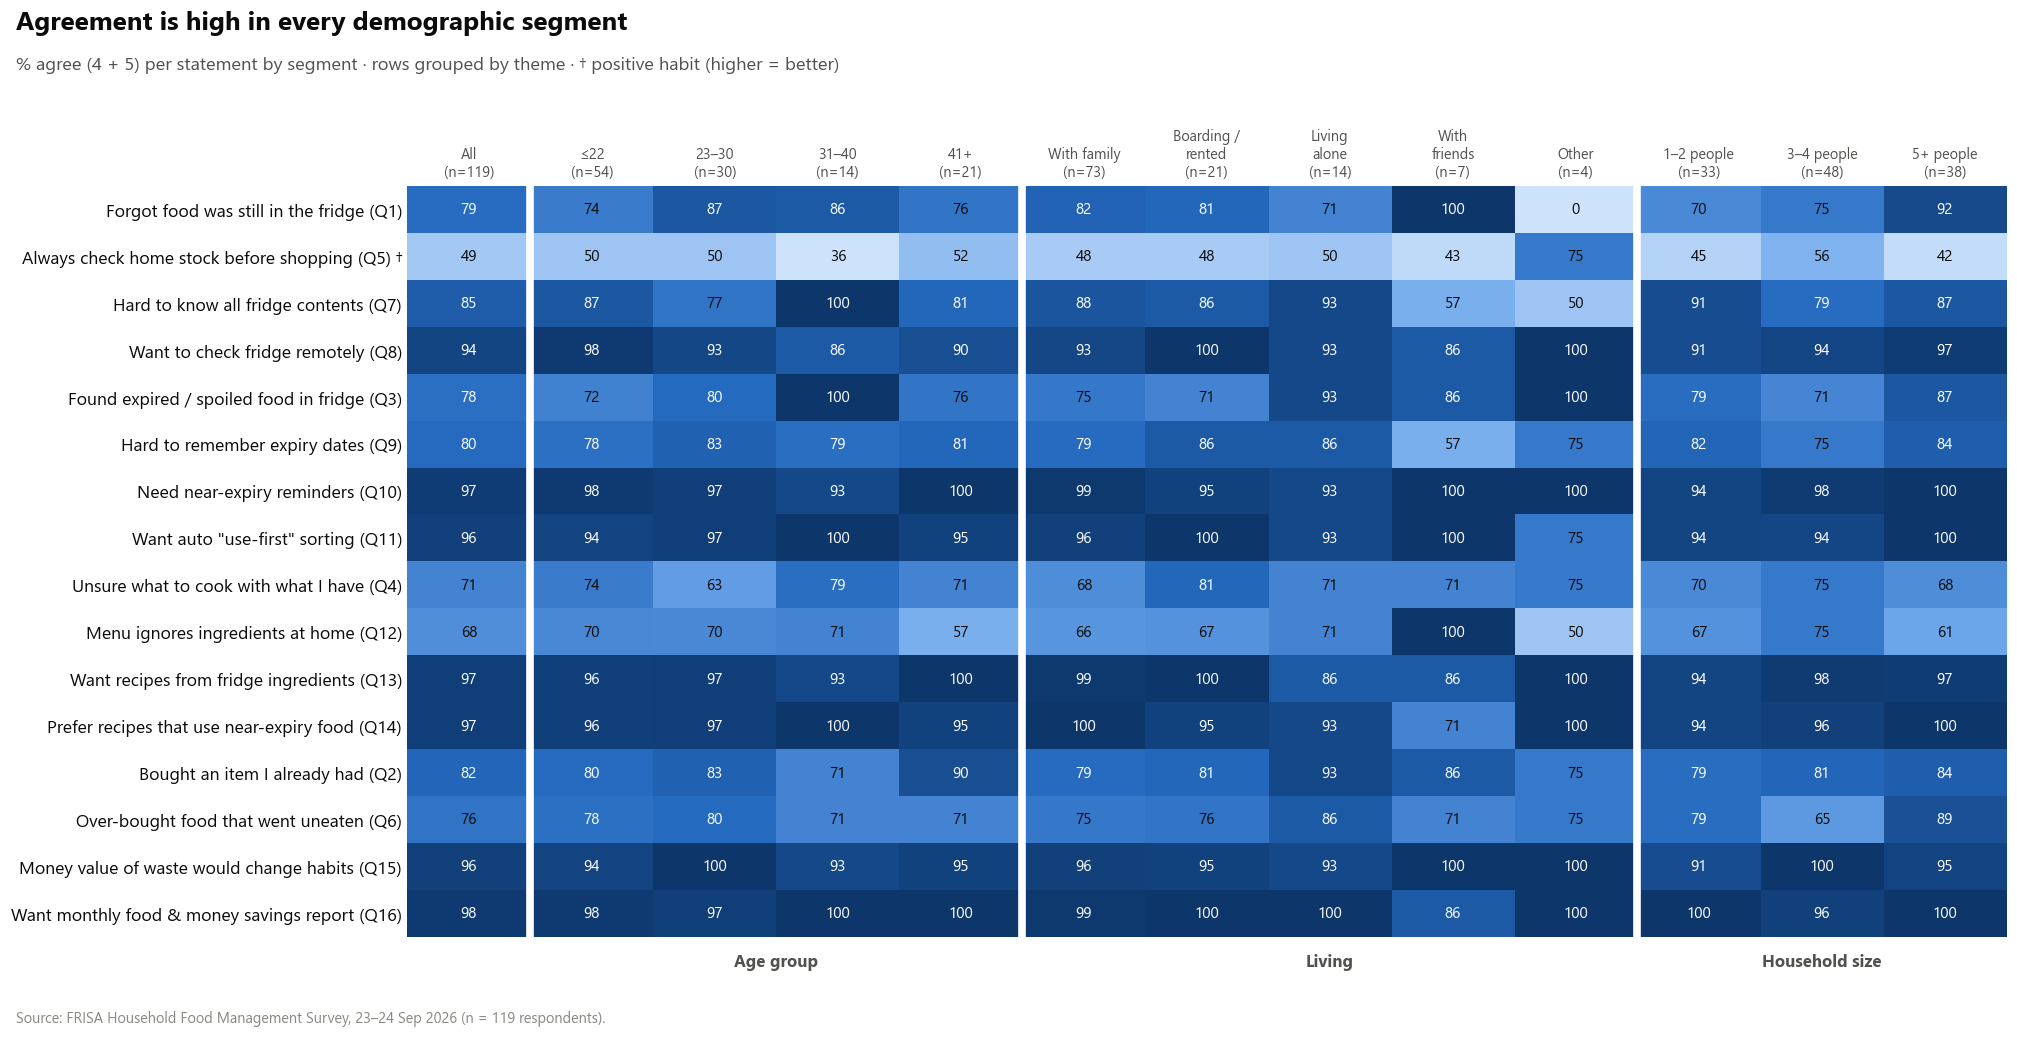

In [26]:
SEGMENTS = {
    'Age group':       ('age_group',       AGEG_ORDER),
    'Living':          ('living',          LIVING_ORDER),
    'Household size':  ('household_group', HHG_ORDER),
    'Fridge':          ('fridge',          FRIDGE_ORDER),
    'Shopping role':   ('shopping_group',  SHOPG_ORDER),
    'Food spend':      ('food_spend',      SPEND_ORDER),
    'Region':          ('region',          ['Jabodetabek', 'Other cities']),
}
SHORT_LEVEL = {'Boarding house / rented room': 'Boarding / rented', 'Yes, private fridge': 'Private', 'Yes, shared fridge': 'Shared',
               'No fridge': 'None', 'High': 'High', 'Medium': 'Medium', 'Low': 'Low', 'Prefer not to say': 'Not said',
               'Other cities': 'Other cities'}

def seg_matrix(values_fn, row_order, row_labels, seg_names, title, subtitle, fname, vmin=40, vmax=100, height=9.5):
    blocks, groups = [], []
    overall = values_fn(pd.Series(True, index=df.index))
    blocks.append(overall.rename(f'All\n(n={N})')); groups.append(('', 1))
    for sname in seg_names:
        col, levels = SEGMENTS[sname]
        k = 0
        for lv in levels:
            m = df[col].astype(str) == lv
            if m.sum() == 0: continue
            blocks.append(values_fn(m).rename(f'{wrap(SHORT_LEVEL.get(lv, lv), 11)}\n(n={m.sum()})')); k += 1
        groups.append((sname, k))
    M = pd.concat(blocks, axis=1).loc[row_order]
    fig, ax = plt.subplots(figsize=(1.0 * M.shape[1] + 5.5, height))
    ax.imshow(M.values, cmap=SEQ, vmin=vmin, vmax=vmax, aspect='auto')
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=10, color='white' if v > vmin + 0.62 * (vmax - vmin) else INK)
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(M.columns, fontsize=9.5)
    ax.xaxis.tick_top()
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(row_labels)
    x = 0
    for gname, k in groups:
        if x > 0: ax.axvline(x - 0.5, color=BG, linewidth=5)
        if gname: ax.text(x - 0.5 + k / 2, M.shape[0] - 0.5 + 0.35, gname, ha='center', va='top', fontsize=11, fontweight='bold', color=INK2)
        x += k
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(length=0)
    header(fig, title, subtitle)
    finish(fig, fname)
    return M

row_order = [c for th in THEMES for c in STMT.index[STMT.theme == th]]
row_labels = [f'{SHORT[c]} ({c})' + (' †' if c == 'Q5' else '') for c in row_order]
agree_fn = lambda m: A[m].mean() * 100
M1 = seg_matrix(agree_fn, row_order, row_labels, ['Age group', 'Living', 'Household size'],
                'Agreement is high in every demographic segment',
                '% agree (4 + 5) per statement by segment · rows grouped by theme · † positive habit (higher = better)', '20_segment_matrix_demographics')

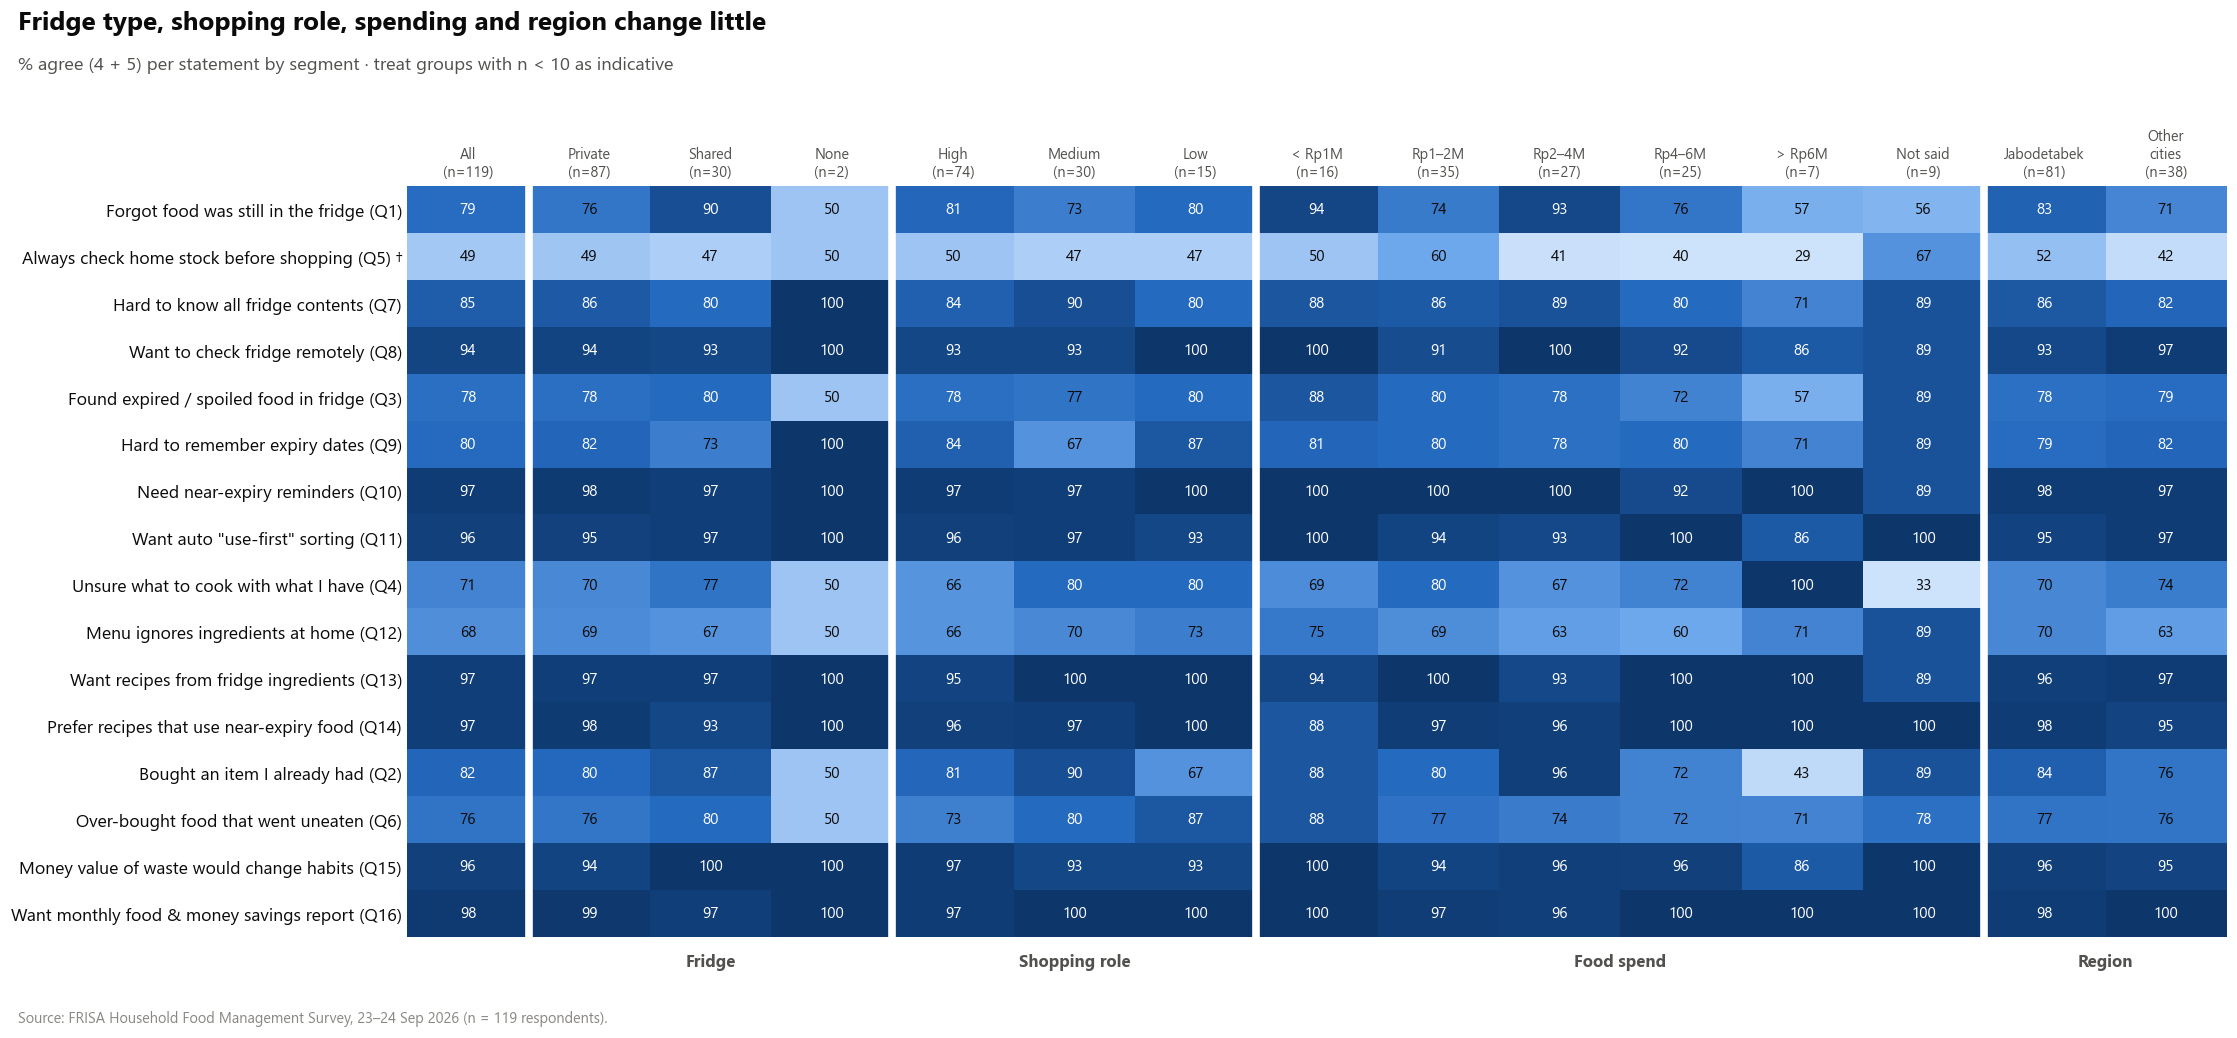

In [27]:
M2 = seg_matrix(agree_fn, row_order, row_labels, ['Fridge', 'Shopping role', 'Food spend', 'Region'],
                'Fridge type, shopping role, spending and region change little',
                '% agree (4 + 5) per statement by segment · treat groups with n < 10 as indicative', '21_segment_matrix_household')

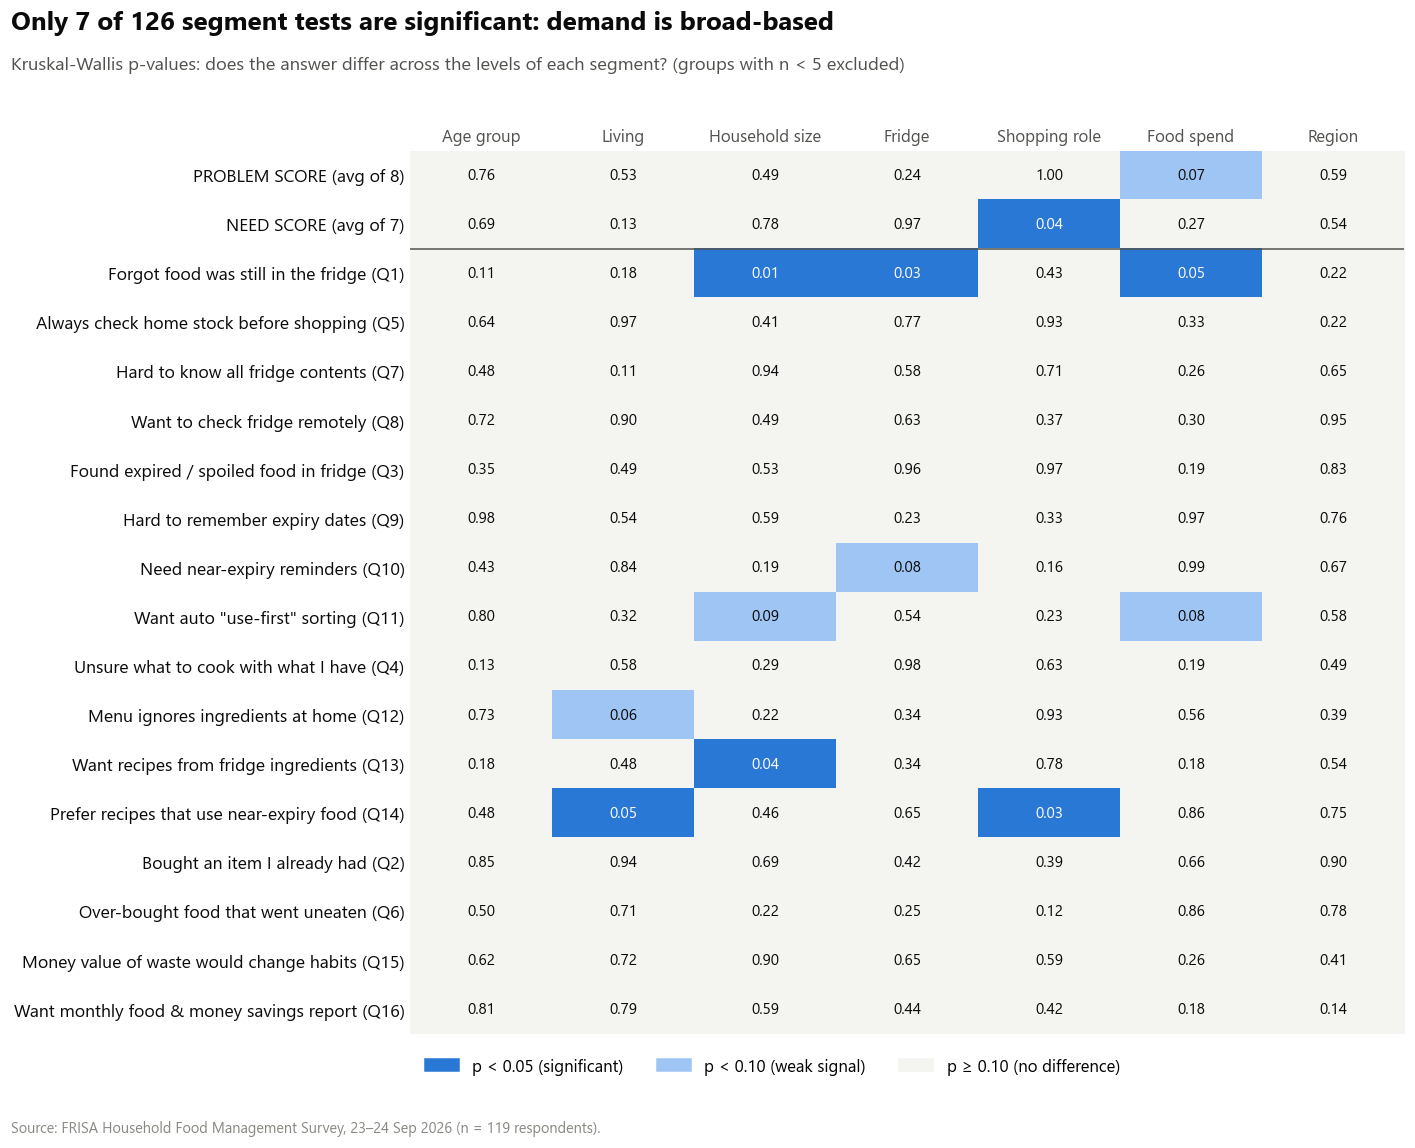

**Key takeaways**

- Only **7 of 126** tests reach p < 0.05. By chance alone about 6 would be expected, **so the survey shows no strong segment effects.**
- The composite scores are stable too; the only significant result is need score by shopping role (p = 0.04), and the gap is small (see the segment matrices above).
- **What this means for the proposal:** the problem and the demand are **universal across the surveyed segments**. FRISA is not a niche product for one demographic, which supports a broad addressable market and messaging that works across segments.
- The few significant cells are shown in the next chart. Treat them as hypotheses for a larger follow-up survey, not as firm conclusions.

Statement,Segment,p-value
NEED SCORE (avg of 7),Shopping role,0.035
Forgot food was still in the fridge (Q1),Household size,0.014
Forgot food was still in the fridge (Q1),Fridge,0.035
Forgot food was still in the fridge (Q1),Food spend,0.045
Want recipes from fridge ingredients (Q13),Household size,0.039
Prefer recipes that use near-expiry food (Q14),Living,0.049
Prefer recipes that use near-expiry food (Q14),Shopping role,0.032


In [28]:
# Statistical scan: Kruskal-Wallis test of every statement (1-5 score) against every segment variable
tests, rows = [], ['pain_score', 'need_score'] + row_order
ROW_NAME = {'pain_score': 'PROBLEM SCORE (avg of 8)', 'need_score': 'NEED SCORE (avg of 7)', **{c: f'{SHORT[c]} ({c})' for c in Q}}
P = pd.DataFrame(index=rows, columns=list(SEGMENTS), dtype=float)
for sname, (col, levels) in SEGMENTS.items():
    for r in rows:
        vals = df[r] if r in ('pain_score', 'need_score') else L[r]
        groups = [vals[df[col].astype(str) == lv] for lv in levels if (df[col].astype(str) == lv).sum() >= 5]
        P.loc[r, sname] = stats.kruskal(*groups).pvalue

fig, ax = plt.subplots(figsize=(13, 10.5))
colors = np.where(P.values < 0.05, 2, np.where(P.values < 0.10, 1, 0))
ax.imshow(colors, cmap=mpl.colors.ListedColormap(['#f4f4f1', RAMP[200], BLUE]), vmin=0, vmax=2, aspect='auto')
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        ax.text(j, i, f'{P.values[i, j]:.2f}', ha='center', va='center', fontsize=10, color='white' if colors[i, j] == 2 else INK)
ax.set_xticks(range(P.shape[1])); ax.set_xticklabels(P.columns); ax.xaxis.tick_top()
ax.set_yticks(range(P.shape[0])); ax.set_yticklabels([ROW_NAME[r] for r in rows])
ax.axhline(1.5, color=INK2, linewidth=1)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
ax.legend(handles=[Patch(color=BLUE, label='p < 0.05 (significant)'), Patch(color=RAMP[200], label='p < 0.10 (weak signal)'),
                   Patch(color='#f4f4f1', label='p ≥ 0.10 (no difference)')], loc='upper left', bbox_to_anchor=(0, -0.01), ncol=3)
n_sig, n_tests = int((P.values < 0.05).sum()), P.size
header(fig, f'Only {n_sig} of {n_tests} segment tests are significant: demand is broad-based',
       'Kruskal-Wallis p-values: does the answer differ across the levels of each segment? (groups with n < 5 excluded)')
finish(fig, '22_segment_significance_scan')

takeaways(
    f'Only **{n_sig} of {n_tests}** tests reach p < 0.05. By chance alone about {0.05 * n_tests:.0f} would be expected, '
    '**so the survey shows no strong segment effects.**',
    (lambda sig_sc: 'Neither the overall problem score nor the need score differs significantly across any segment.' if not sig_sc else
     'The composite scores are stable too; the only significant result is ' + ', '.join(sig_sc) +
     ', and the gap is small (see the segment matrices above).')(
        [f'{ROW_NAME[r].split(" (")[0].lower()} by {s_.lower()} (p = {P.loc[r, s_]:.2f})'
         for r in ['pain_score', 'need_score'] for s_ in P.columns if P.loc[r, s_] < 0.05]),
    '**What this means for the proposal:** the problem and the demand are **universal across the surveyed segments**. FRISA is not a niche product '
    'for one demographic, which supports a broad addressable market and messaging that works across segments.',
    'The few significant cells are shown in the next chart. Treat them as hypotheses for a larger follow-up survey, not as firm conclusions.',
)
sig = P.stack()[P.stack() < 0.05].rename('p-value').reset_index().rename(columns={'level_0': 'Statement', 'level_1': 'Segment'})
sig['Statement'] = sig['Statement'].map(ROW_NAME)
display(sig.style.hide(axis='index').format({'p-value': '{:.3f}'}))

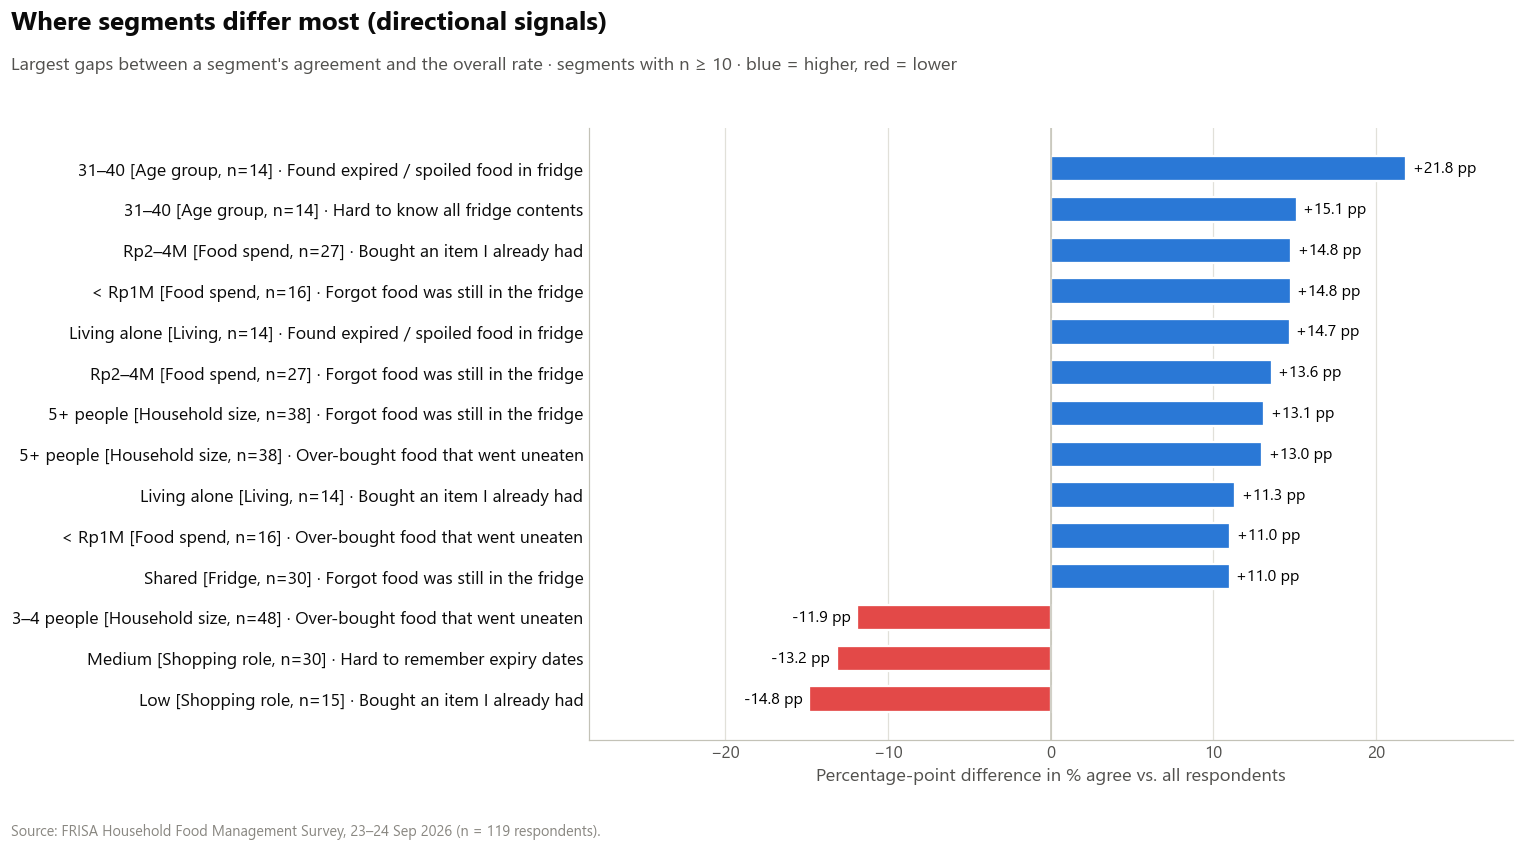

**How to use these signals:** they suggest messaging nuances. The largest positive gaps are: *31–40 [Age group, n=14] · Found expired / spoiled food in fridge* (+21.8 pp); *31–40 [Age group, n=14] · Hard to know all fridge contents* (+15.1 pp); *Rp2–4M [Food spend, n=27] · Bought an item I already had* (+14.8 pp). With n = 119 and small segments, none of these gaps should be presented as a proven segment difference.

In [29]:
# Biggest deviations from the overall agreement rate (segments with n >= 10 only)
dev = []
for sname, (col, levels) in SEGMENTS.items():
    for lv in levels:
        m = df[col].astype(str) == lv
        if m.sum() < 10: continue
        for c in Q:
            if c == 'Q5': continue
            dev.append((f'{SHORT_LEVEL.get(lv, lv)} [{sname}, n={m.sum()}] · {SHORT[c]}', A.loc[m, c].mean() * 100 - A[c].mean() * 100))
dev = pd.DataFrame(dev, columns=['label', 'pp']).assign(abs=lambda d: d.pp.abs()).nlargest(14, 'abs').sort_values('pp')

fig, ax = plt.subplots(figsize=(14, 7.8))
ax.barh([wrap(l, 70) for l in dev.label], dev.pp, color=[BLUE if v > 0 else RED for v in dev.pp], height=0.62, edgecolor=BG, linewidth=1.5)
for i, v in enumerate(dev.pp):
    ax.text(v + (0.4 if v > 0 else -0.4), i, f'{v:+.1f} pp', va='center', ha='left' if v > 0 else 'right', fontsize=10.5)
ax.axvline(0, color=AXIS, linewidth=1)
lim = dev.pp.abs().max() * 1.3; ax.set_xlim(-lim, lim); clean_ax(ax, 'x')
ax.set_xlabel('Percentage-point difference in % agree vs. all respondents')
header(fig, 'Where segments differ most (directional signals)',
       'Largest gaps between a segment\'s agreement and the overall rate · segments with n ≥ 10 · blue = higher, red = lower')
finish(fig, '23_segment_deviations')

top_up = dev.sort_values('pp', ascending=False).head(3)
display(Markdown('**How to use these signals:** they suggest messaging nuances. The largest positive gaps are: '
                 + '; '.join(f'*{l}* ({v:+.1f} pp)' for l, v in zip(top_up.label, top_up.pp))
                 + '. With n = 119 and small segments, none of these gaps should be presented as a proven segment difference.'))

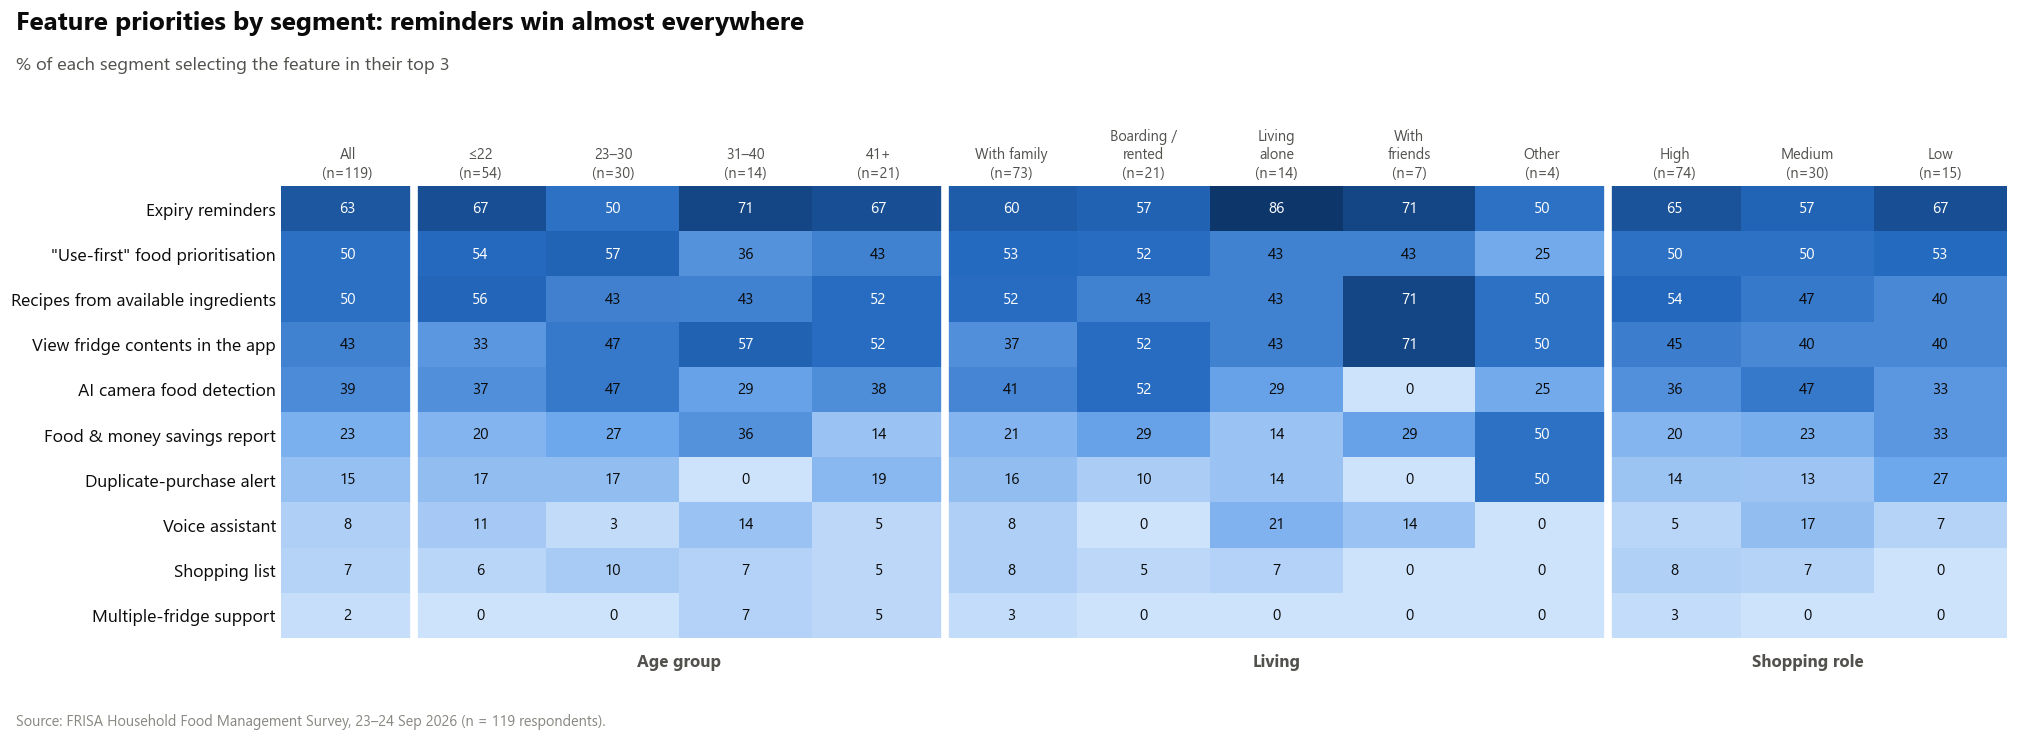

**Key takeaways**

- **Expiry reminders** rank #1 or #2 in 13 of 13 columns (all respondents + each segment). They are the safest headline feature.
- **Recipe recommendations** are most popular with ≤22 respondents (56%) and least with 31–40 (43%).
- **AI camera detection** is most popular with 23–30 respondents (47%).
- Treat these as directional: most segment columns have fewer than 50 respondents.

In [30]:
feat_order = fc.index.tolist()
M3 = seg_matrix(lambda m: FEAT[m].mean() * 100, feat_order, [FEAT_LABEL[k] for k in feat_order],
                ['Age group', 'Living', 'Shopping role'],
                'Feature priorities by segment: reminders win almost everywhere',
                '% of each segment selecting the feature in their top 3', '24_segment_features', vmin=0, vmax=80, height=6.8)

by_age = FEAT.groupby(df.age_group).mean() * 100
rem_top2 = int((M3.rank(ascending=False, method='min').loc['reminder'] <= 2).sum())
takeaways(
    f'**Expiry reminders** rank #1 or #2 in {rem_top2} of {M3.shape[1]} columns (all respondents + each segment). They are the safest headline feature.',
    f'**Recipe recommendations** are most popular with {by_age.recipe.idxmax()} respondents ({by_age.recipe.max():.0f}%) and least with '
    f'{by_age.recipe.idxmin()} ({by_age.recipe.min():.0f}%).',
    f'**AI camera detection** is most popular with {by_age.camera.idxmax()} respondents ({by_age.camera.max():.0f}%).',
    'Treat these as directional: most segment columns have fewer than 50 respondents.',
)

## 13. Personas: data-driven segmentation of feature preferences

Demographics barely change *whether* people want FRISA (Section 12). The top-3 feature choices, however, show *why* they want it. We cluster respondents on their feature choices (one-hot matrix, K-Means) to build personas that can guide product and marketing decisions.

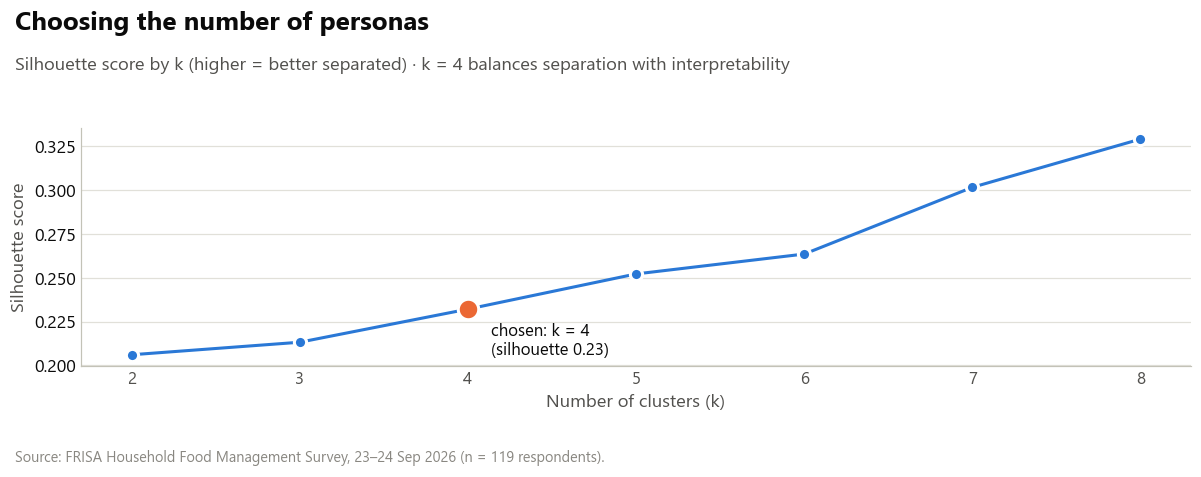

Silhouette rises slowly with k on binary data, and all values are modest (< 0.35): preferences overlap rather than forming sharp groups. We use k = 4 because each cluster maps to a clear FRISA value pillar and every persona keeps a usable size (smallest n = 24).


In [31]:
X = FEAT.values.astype(float)
ks = list(range(2, 9))
sil = [silhouette_score(X, KMeans(k, random_state=42, n_init=50).fit_predict(X)) for k in ks]
K = 4
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(ks, sil, color=BLUE, linewidth=2, marker='o', markersize=8, markeredgecolor=BG, markeredgewidth=2)
ax.scatter([K], [sil[ks.index(K)]], s=180, color=ORANGE, zorder=3, edgecolor=BG, linewidth=2)
ax.annotate(f'chosen: k = {K}\n(silhouette {sil[ks.index(K)]:.2f})', (K, sil[ks.index(K)]), xytext=(15, -30),
            textcoords='offset points', fontsize=11, color=INK)
ax.set_xlabel('Number of clusters (k)'); ax.set_ylabel('Silhouette score'); clean_ax(ax, 'y')
header(fig, 'Choosing the number of personas',
       'Silhouette score by k (higher = better separated) · k = 4 balances separation with interpretability')
finish(fig, '25_persona_silhouette')
_sizes = np.bincount(KMeans(K, random_state=42, n_init=50).fit_predict(X))
print(f'Silhouette rises slowly with k on binary data, and all values are modest (< 0.35): preferences overlap rather than forming sharp groups. '
      f'We use k = {K} because each cluster maps to a clear FRISA value pillar and every persona keeps a usable size (smallest n = {_sizes.min()}).')

Persona,Size,Defining features (lift vs. average)
Automation Seekers,45,"AI camera food detection (+61 pp), ""Use-first"" food prioritisation (+5 pp)"
Connected Planners,26,"View fridge contents in the app (+57 pp), Recipes from available ingredients (+42 pp)"
Smart Home Cooks,24,"Recipes from available ingredients (+50 pp), Expiry reminders (+29 pp)"
Expiry Guardians,24,"Expiry reminders (+24 pp), ""Use-first"" food prioritisation (+20 pp)"


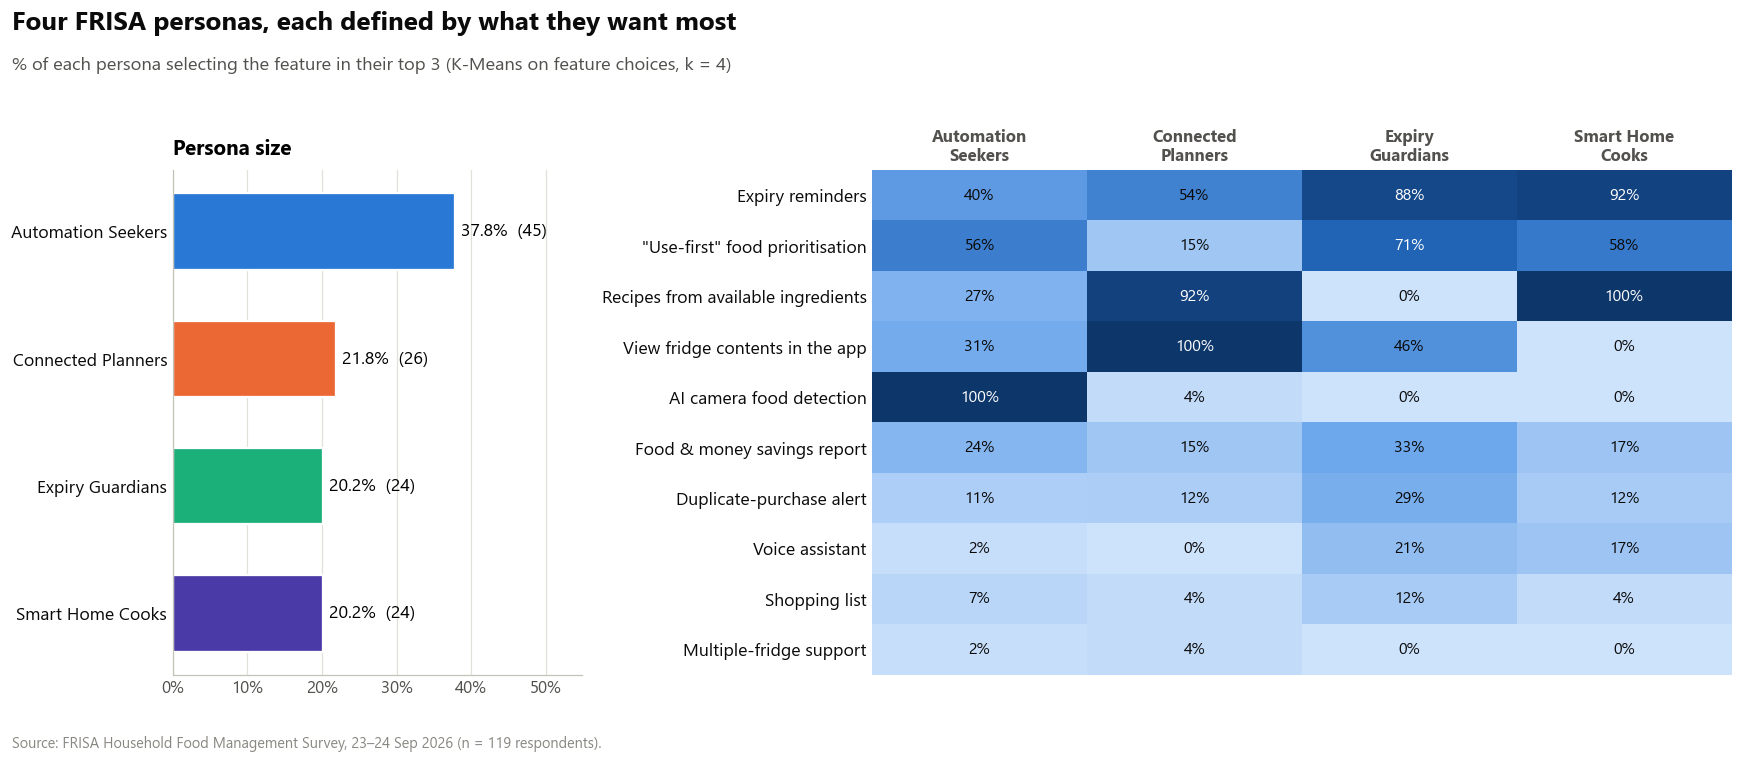

In [32]:
km = KMeans(K, random_state=42, n_init=50).fit(X)
prof = FEAT.groupby(km.labels_).mean()
lift = prof - FEAT.mean()

# Name each cluster after its most distinctive feature (highest lift vs. the overall selection rate)
NAME_BY_FEATURE = {'reminder': 'Expiry Guardians', 'priority': 'Expiry Guardians', 'recipe': 'Smart Home Cooks',
                   'camera': 'Automation Seekers', 'app_view': 'Connected Planners', 'dup_alert': 'Smart Shoppers',
                   'shopping_list': 'Smart Shoppers', 'savings_report': 'Savings Trackers', 'voice': 'Hands-free Users',
                   'multi_fridge': 'Multi-fridge Households'}
cluster_name, used = {}, set()
for c in lift.max(axis=1).sort_values(ascending=False).index:          # most distinctive cluster picks its name first
    for k_ in lift.loc[c].sort_values(ascending=False).index:
        if prof.loc[c, k_] >= 0.5 and NAME_BY_FEATURE[k_] not in used:
            cluster_name[c] = NAME_BY_FEATURE[k_]; used.add(cluster_name[c]); break
    else:
        cluster_name[c] = f'Persona {c + 1}'
sizes = pd.Series(km.labels_).map(cluster_name).value_counts()
PERSONA_ORDER = sizes.index.tolist()                                   # largest persona first
PERSONA_COLOR = dict(zip(PERSONA_ORDER, [BLUE, ORANGE, AQUA, VIOLET]))
df['persona'] = pd.Categorical([cluster_name[l] for l in km.labels_], PERSONA_ORDER, ordered=True)
display(pd.DataFrame({'Persona': [cluster_name[c] for c in prof.index],
                      'Size': [int((km.labels_ == c).sum()) for c in prof.index],
                      'Defining features (lift vs. average)': [', '.join(f'{FEAT_LABEL[k_]} ({lift.loc[c, k_] * 100:+.0f} pp)'
                                                                  for k_ in lift.loc[c].nlargest(2).index) for c in prof.index]})
        .sort_values('Size', ascending=False).style.hide(axis='index').set_properties(**{'text-align': 'left'}))

pp = (FEAT.groupby(df.persona).mean() * 100).T.loc[feat_order]
psize = df.persona.value_counts().reindex(PERSONA_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 2.1]})
ax = axes[0]
bars = ax.barh(PERSONA_ORDER[::-1], psize[::-1] / N * 100, color=[PERSONA_COLOR[p] for p in PERSONA_ORDER[::-1]],
               height=0.6, edgecolor=BG, linewidth=1.5)
for b_, c in zip(bars, psize[::-1].values):
    ax.text(b_.get_width() + 0.8, b_.get_y() + b_.get_height() / 2, f'{c / N * 100:.1f}%  ({c})', va='center', fontsize=11.5)
ax.set_xlim(0, psize.max() / N * 100 * 1.45); pct_fmt(ax); clean_ax(ax, 'x')
ax.set_title('Persona size', loc='left', fontsize=13.5, fontweight='bold', pad=10)
ax = axes[1]
ax.imshow(pp.values, cmap=SEQ, vmin=0, vmax=100, aspect='auto')
for i in range(pp.shape[0]):
    for j in range(pp.shape[1]):
        v = pp.values[i, j]; ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=10.5, color='white' if v > 60 else INK)
ax.set_xticks(range(K)); ax.set_xticklabels([wrap(p, 12) for p in pp.columns], fontweight='bold'); ax.xaxis.tick_top()
ax.set_yticks(range(len(feat_order))); ax.set_yticklabels([FEAT_LABEL[k] for k in feat_order])
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
header(fig, 'Four FRISA personas, each defined by what they want most',
       '% of each persona selecting the feature in their top 3 (K-Means on feature choices, k = 4)')
finish(fig, '26_persona_profiles')

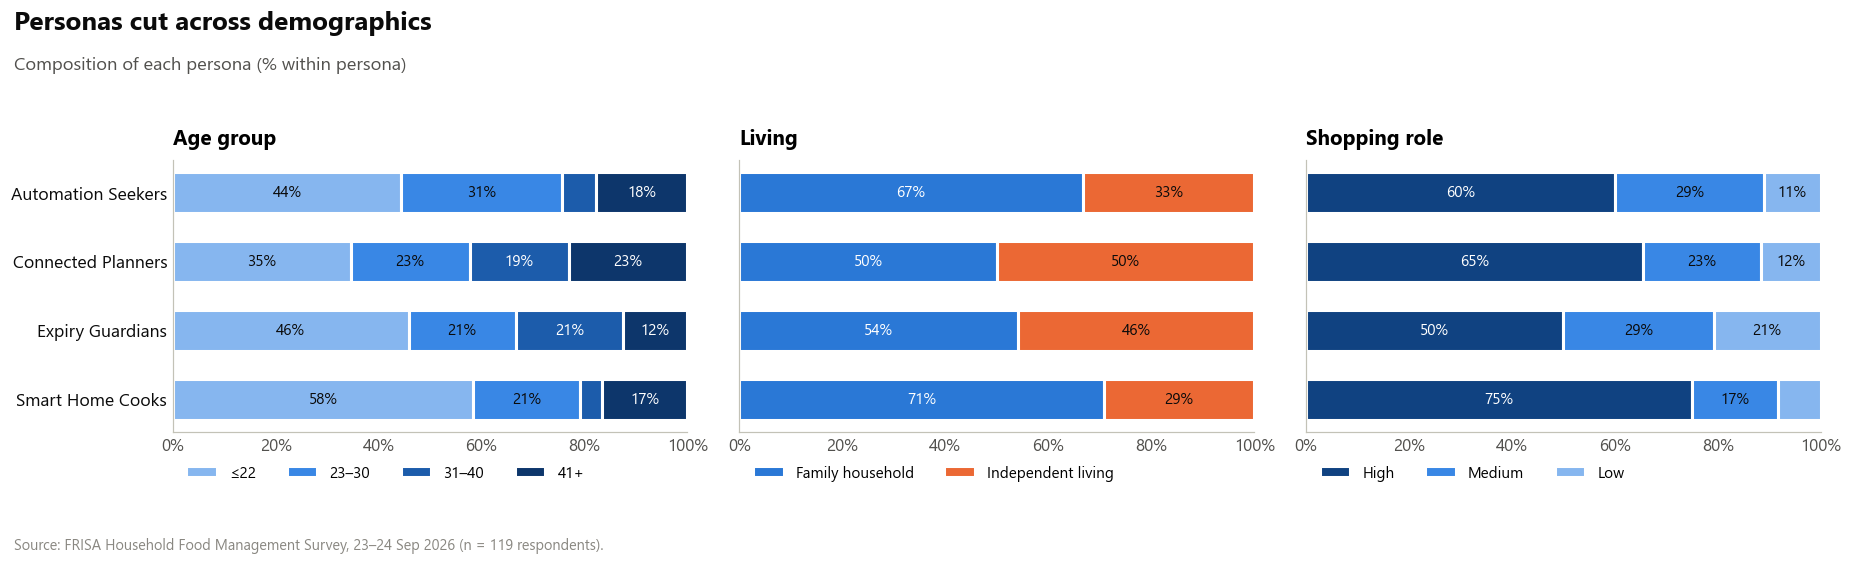

,Size,Share,Avg problem score,Avg need score,Enthusiasts (4+ strong),Top input method,Camera-based input
persona,,,,,,,
Automation Seekers,45,37.8%,3.99,4.53,60.0%,FRISA camera auto-recognition,62.2%
Connected Planners,26,21.8%,4.04,4.47,57.7%,FRISA camera auto-recognition,61.5%
Expiry Guardians,24,20.2%,3.98,4.51,58.3%,FRISA camera auto-recognition,70.8%
Smart Home Cooks,24,20.2%,3.99,4.48,45.8%,FRISA camera auto-recognition,62.5%


In [33]:
def comp(col, order):
    return pd.crosstab(df.persona, df[col], normalize='index').reindex(index=PERSONA_ORDER, columns=order).fillna(0) * 100

panels = [('Age group', comp('age_group', AGEG_ORDER), [RAMP[250], RAMP[400], RAMP[550], RAMP[700]]),
          ('Living', comp('living_group', ['Family household', 'Independent living']), [BLUE, ORANGE]),
          ('Shopping role', comp('shopping_group', SHOPG_ORDER), [RAMP[650], RAMP[400], RAMP[250]])]
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharey=True)
for ax, (ttl, C, cols) in zip(axes, panels):
    left = np.zeros(K)
    for (lv, colr) in zip(C.columns, cols):
        ax.barh(PERSONA_ORDER, C[lv], left=left, color=colr, height=0.6, edgecolor=BG, linewidth=2, label=lv)
        for j, (l, v) in enumerate(zip(left, C[lv])):
            if v >= 9:
                ax.text(l + v / 2, j, f'{v:.0f}%', ha='center', va='center', fontsize=10,
                        color='white' if colr in (RAMP[550], RAMP[700], RAMP[650], BLUE) else INK)
        left += C[lv].values
    ax.invert_yaxis() if ax is axes[0] else None
    ax.set_xlim(0, 100); pct_fmt(ax); clean_ax(ax, None)
    ax.set_title(ttl, loc='left', fontsize=13.5, fontweight='bold', pad=10)
    ax.legend(loc='upper left', bbox_to_anchor=(0, -0.07), ncol=len(C.columns), fontsize=10)
header(fig, 'Personas cut across demographics',
       'Composition of each persona (% within persona)')
finish(fig, '27_persona_demographics')

summary = pd.DataFrame({
    'Size': psize,
    'Share': psize / N * 100,
    'Avg problem score': df.groupby('persona').pain_score.mean(),
    'Avg need score': df.groupby('persona').need_score.mean(),
    'Enthusiasts (4+ strong)': df.groupby('persona').need_strong_count.apply(lambda s: (s >= 4).mean() * 100),
    'Top input method': df.groupby('persona').input_method.agg(lambda s: s.value_counts().index[0]),
    'Camera-based input': df.groupby('persona').input_type.apply(lambda s: (s == 'Camera-based').mean() * 100),
}).loc[PERSONA_ORDER]
display(summary.style.format({'Share': '{:.1f}%', 'Avg problem score': '{:.2f}', 'Avg need score': '{:.2f}',
                              'Enthusiasts (4+ strong)': '{:.1f}%', 'Camera-based input': '{:.1f}%'}))

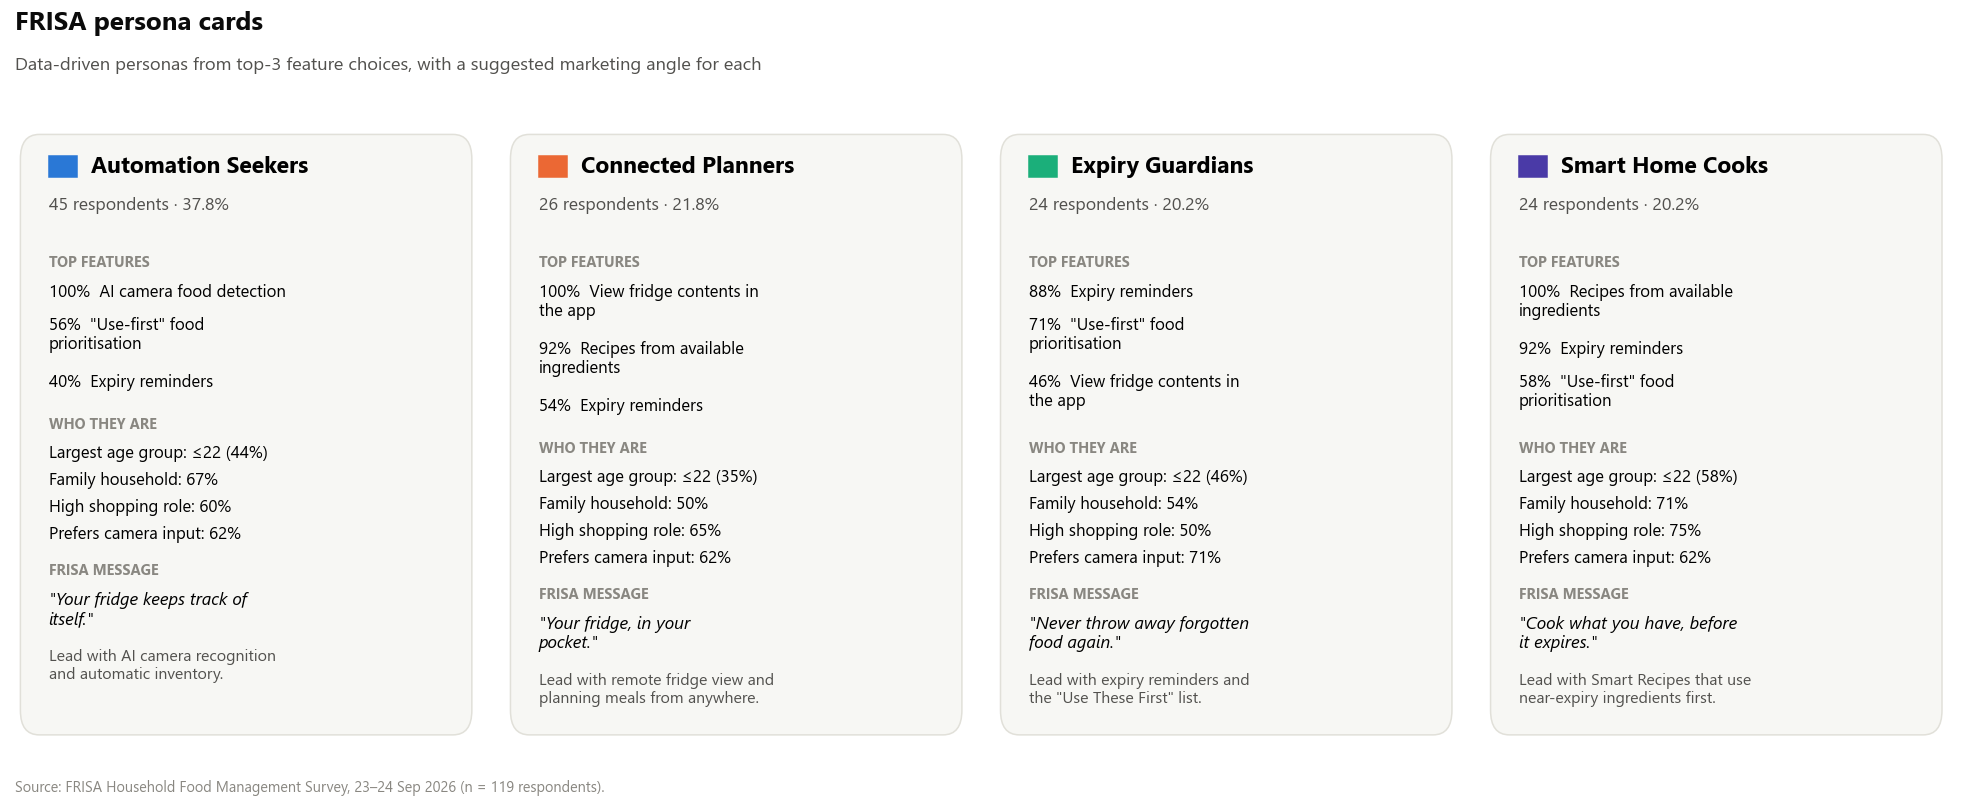

In [34]:
PITCH = {
    'Expiry Guardians':        ('"Never throw away forgotten food again."', 'Lead with expiry reminders and the "Use These First" list.'),
    'Automation Seekers':      ('"Your fridge keeps track of itself."', 'Lead with AI camera recognition and automatic inventory.'),
    'Smart Home Cooks':        ('"Cook what you have, before it expires."', 'Lead with Smart Recipes that use near-expiry ingredients first.'),
    'Connected Planners':      ('"Your fridge, in your pocket."', 'Lead with remote fridge view and planning meals from anywhere.'),
    'Smart Shoppers':          ('"Never buy what you already have."', 'Lead with remote stock check, duplicate alerts and shopping list.'),
    'Savings Trackers':        ('"See the money you saved."', 'Lead with Consumption Insights and the monthly savings report.'),
    'Hands-free Users':        ('"Just ask your fridge."', 'Lead with voice commands and fridge queries.'),
    'Multi-fridge Households': ('"Every fridge, one view."', 'Lead with multiple-fridge support.'),
}
fig, axes = plt.subplots(1, K, figsize=(18, 7.4))
LINE = 0.039
for ax, p in zip(axes, PERSONA_ORDER):
    m = df.persona == p
    ax.set_axis_off()
    ax.add_patch(FancyBboxPatch((0.02, 0.01), 0.96, 0.98, boxstyle='round,pad=0,rounding_size=0.04',
                                transform=ax.transAxes, facecolor='#f7f7f4', edgecolor=GRID))
    ax.add_patch(plt.Rectangle((0.08, 0.92), 0.06, 0.035, transform=ax.transAxes, color=PERSONA_COLOR[p]))
    ax.text(0.17, 0.937, p, transform=ax.transAxes, fontsize=15, fontweight='bold', va='center')
    ax.text(0.08, 0.875, f'{m.sum()} respondents · {m.mean() * 100:.1f}%', transform=ax.transAxes, fontsize=11.5, color=INK2, va='center')
    y = [0.81]
    def put(text, width=30, gap=0.015, **kw):
        t = wrap(text, width)
        ax.text(0.08, y[0], t, transform=ax.transAxes, va='top', **kw)
        y[0] -= LINE * (t.count('\n') + 1) + gap
    def label(text):
        y[0] -= 0.016
        put(text, fontsize=9.5, fontweight='bold', color=MUTED, gap=0.008)
    label('TOP FEATURES')
    for k, v in (FEAT[m].mean() * 100).nlargest(3).items():
        put(f'{v:.0f}%  {FEAT_LABEL[k]}', fontsize=11)
    label('WHO THEY ARE')
    for f_ in [f'Largest age group: {df.age_group[m].value_counts().idxmax()} ({df.age_group[m].value_counts(normalize=True).max() * 100:.0f}%)',
               f'Family household: {(df.living_group[m] == "Family household").mean() * 100:.0f}%',
               f'High shopping role: {(df.shopping_group[m] == "High").mean() * 100:.0f}%',
               f'Prefers camera input: {(df.input_type[m] == "Camera-based").mean() * 100:.0f}%']:
        put(f_, fontsize=11, gap=0.005)
    label('FRISA MESSAGE')
    msg, how = PITCH.get(p, ('"Know it. Use it. Save it."', 'Lead with the full KNOW → PRIORITISE → ACT → SAVE loop.'))
    put(msg, width=28, fontsize=11.5, fontstyle='italic')
    put(how, width=32, fontsize=10.5, color=INK2)
header(fig, 'FRISA persona cards', 'Data-driven personas from top-3 feature choices, with a suggested marketing angle for each')
finish(fig, '28_persona_cards')

## 14. Correlation & adoption-readiness analysis

Do the problems cluster together? Does *feeling* the problem more strongly predict *wanting* the solution more? This section answers both questions.

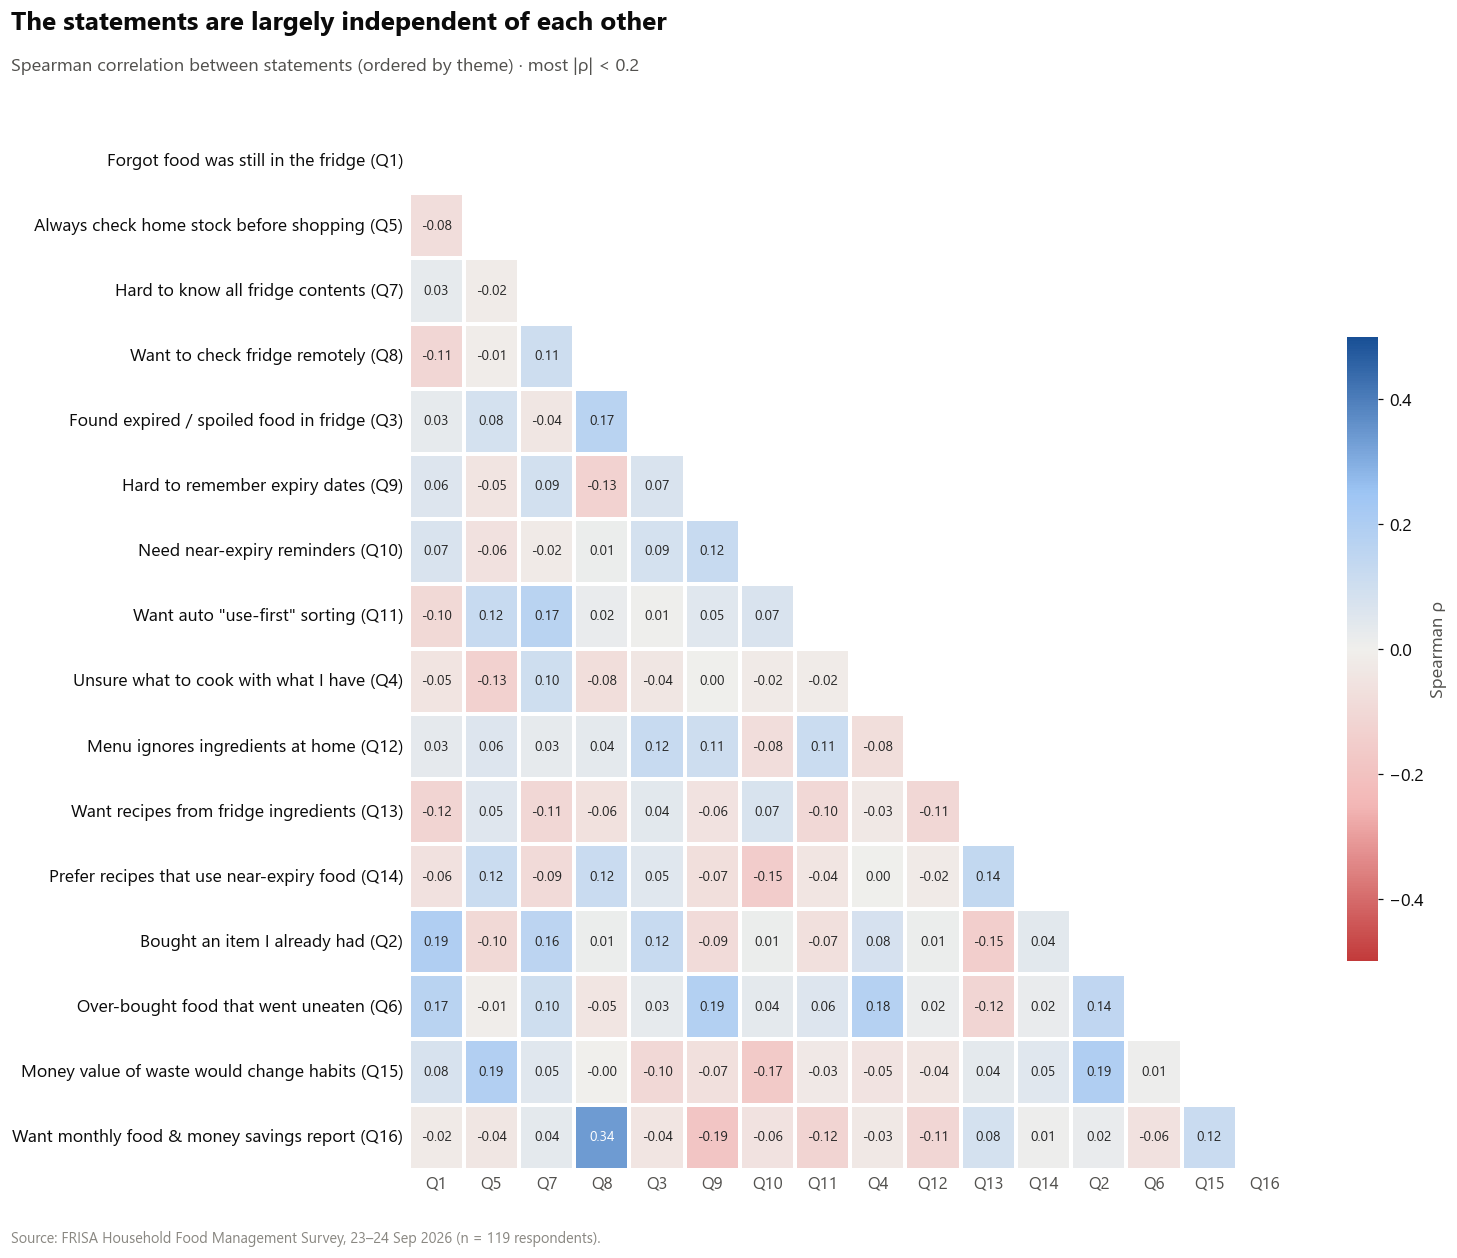

Strongest statement pairs:


Pair,Spearman ρ
Want to check fridge remotely (Q8) ↔ Want monthly food & money savings report (Q16),+0.34
Bought an item I already had (Q2) ↔ Money value of waste would change habits (Q15),+0.19
Forgot food was still in the fridge (Q1) ↔ Bought an item I already had (Q2),+0.19
Always check home stock before shopping (Q5) ↔ Money value of waste would change habits (Q15),+0.19
Hard to remember expiry dates (Q9) ↔ Want monthly food & money savings report (Q16),-0.19
Hard to remember expiry dates (Q9) ↔ Over-bought food that went uneaten (Q6),+0.19


Scale,Cronbach's α
Problem statements (8),0.34
Need statements (7),0.09


**Key takeaways**

- Correlations between statements are weak. Each pain point is a **separate experience**: a household that forgets food does not always over-buy, and the reverse is also true.
- Low Cronbach's α (0.34 / 0.09) confirms that the statements do not measure one single trait. The composite "problem score" and "need score" are therefore **summary averages, not validated psychometric scales**.
- **Product implication:** different households enter the food-waste cycle at different points, which is why FRISA combines several features (visibility, expiry, recipes, shopping) instead of betting on one.

In [35]:
rho = L[row_order].corr(method='spearman')
mask = np.triu(np.ones_like(rho, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11.5))
sns.heatmap(rho, mask=mask, cmap=DIV, vmin=-0.5, vmax=0.5, center=0, annot=True, fmt='.2f', annot_kws={'fontsize': 9},
            linewidths=1.5, linecolor=BG, cbar_kws={'shrink': 0.6, 'label': 'Spearman ρ'}, ax=ax)
ax.set_xticklabels([c for c in row_order], rotation=0)
ax.set_yticklabels([f'{SHORT[c]} ({c})' for c in row_order], rotation=0)
ax.tick_params(length=0)
header(fig, 'The statements are largely independent of each other',
       'Spearman correlation between statements (ordered by theme) · most |ρ| < 0.2')
finish(fig, '29_correlation_matrix')

pairs_r = [(f'{SHORT[a]} ({a})  ↔  {SHORT[b]} ({b})', rho.loc[a, b]) for a, b in combinations(row_order, 2)]
pairs_r = pd.DataFrame(pairs_r, columns=['Pair', 'Spearman ρ']).assign(abs=lambda d: d['Spearman ρ'].abs()).nlargest(6, 'abs').drop(columns='abs')
print('Strongest statement pairs:')
display(pairs_r.style.hide(axis='index').format({'Spearman ρ': '{:+.2f}'}))

def cronbach(X):
    k = X.shape[1]; return k / (k - 1) * (1 - X.var(ddof=1).sum() / X.sum(axis=1).var(ddof=1))
rel = pd.DataFrame({'Scale': ['Problem statements (8)', 'Need statements (7)'],
                    "Cronbach's α": [cronbach(L[PAIN]), cronbach(L[NEED])]})
display(rel.style.hide(axis='index').format({"Cronbach's α": '{:.2f}'}))
takeaways(
    'Correlations between statements are weak. Each pain point is a **separate experience**: a household that forgets food does not always '
    'over-buy, and the reverse is also true.',
    f'Low Cronbach\'s α ({rel.iloc[0, 1]:.2f} / {rel.iloc[1, 1]:.2f}) confirms that the statements do not measure one single trait. '
    'The composite "problem score" and "need score" are therefore **summary averages, not validated psychometric scales**.',
    '**Product implication:** different households enter the food-waste cycle at different points, which is why FRISA combines several features '
    '(visibility, expiry, recipes, shopping) instead of betting on one.',
)

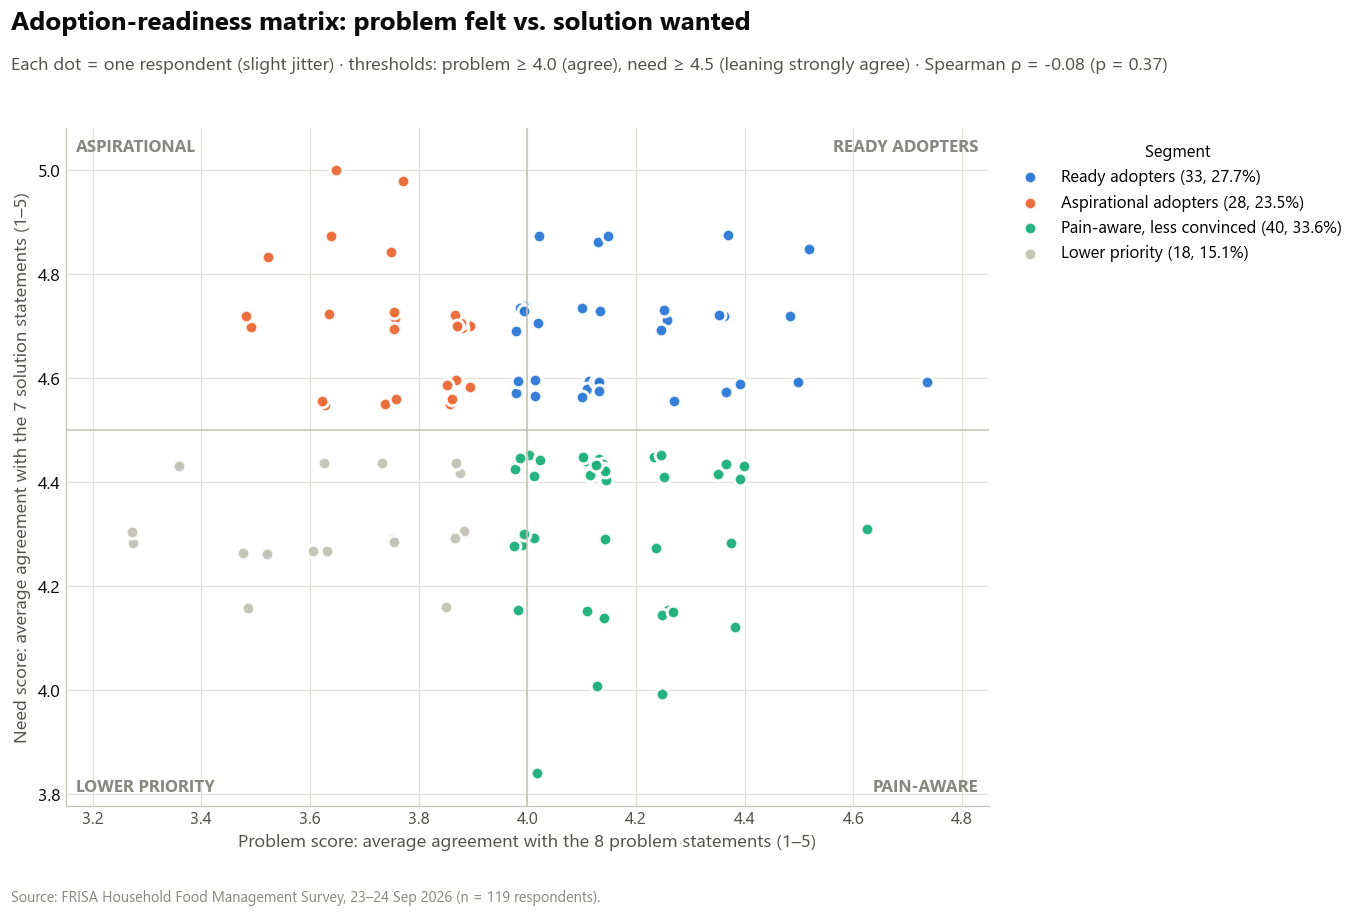

**Key takeaways**

- **Ready adopters**, who feel the problem and strongly want the solution, make up **27.7%** of respondents.
- **Aspirational adopters** (23.5%) feel the problem less but still want the solution strongly. They are attracted by convenience and savings rather than frustration.
- Problem score and need score are **not correlated** (ρ = -0.08). Demand does not depend on how much pain a household reports, so FRISA's appeal goes beyond people who are already frustrated by waste.

In [36]:
r_s, p_s = stats.spearmanr(df.pain_score, df.need_score)
rng = np.random.default_rng(7)
jx = df.pain_score + rng.uniform(-0.025, 0.025, N)
jy = (df.need_score + rng.uniform(-0.025, 0.025, N)).clip(upper=5.0)
PAIN_T, NEED_T = 4.0, 4.5
quad = np.select([(df.pain_score >= PAIN_T) & (df.need_score >= NEED_T), (df.pain_score < PAIN_T) & (df.need_score >= NEED_T),
                  (df.pain_score >= PAIN_T) & (df.need_score < NEED_T)],
                 ['Ready adopters', 'Aspirational adopters', 'Pain-aware, less convinced'], 'Lower priority')
df['readiness'] = quad
Q_ORDER = ['Ready adopters', 'Aspirational adopters', 'Pain-aware, less convinced', 'Lower priority']
Q_COL = dict(zip(Q_ORDER, [BLUE, ORANGE, AQUA, GREY]))

fig, ax = plt.subplots(figsize=(12.5, 8.4))
for q in Q_ORDER:
    m = df.readiness == q
    ax.scatter(jx[m], jy[m], s=70, color=Q_COL[q], edgecolor=BG, linewidth=2, alpha=0.95, label=f'{q} ({m.sum()}, {m.mean() * 100:.1f}%)')
ax.axvline(PAIN_T, color=AXIS, linewidth=1); ax.axhline(NEED_T, color=AXIS, linewidth=1)
xl, yl = (df.pain_score.min() - 0.1, df.pain_score.max() + 0.1), (df.need_score.min() - 0.08, 5.08)
ax.set_xlim(xl); ax.set_ylim(yl)
for (x, y, t, ha) in [(xl[1] - 0.02, yl[1] - 0.02, 'READY ADOPTERS', 'right'), (xl[0] + 0.02, yl[1] - 0.02, 'ASPIRATIONAL', 'left'),
                      (xl[1] - 0.02, yl[0] + 0.02, 'PAIN-AWARE', 'right'), (xl[0] + 0.02, yl[0] + 0.02, 'LOWER PRIORITY', 'left')]:
    ax.text(x, y, t, ha=ha, va='top' if y > 4.5 else 'bottom', fontsize=11, fontweight='bold', color=MUTED)
ax.set_xlabel('Problem score: average agreement with the 8 problem statements (1–5)')
ax.set_ylabel('Need score: average agreement with the 7 solution statements (1–5)')
clean_ax(ax, 'both'); ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title='Segment', title_fontsize=11)
header(fig, 'Adoption-readiness matrix: problem felt vs. solution wanted',
       f'Each dot = one respondent (slight jitter) · thresholds: problem ≥ 4.0 (agree), need ≥ 4.5 (leaning strongly agree) · Spearman ρ = {r_s:+.2f} (p = {p_s:.2f})')
finish(fig, '30_readiness_matrix')

takeaways(
    f'**Ready adopters**, who feel the problem and strongly want the solution, make up **{share(df.readiness == "Ready adopters"):.1f}%** of respondents.',
    f'**Aspirational adopters** ({share(df.readiness == "Aspirational adopters"):.1f}%) feel the problem less but still want the solution strongly. '
    'They are attracted by convenience and savings rather than frustration.',
    f'Problem score and need score are **not correlated** (ρ = {r_s:+.2f}). Demand does not depend on how much pain a household reports, '
    'so FRISA\'s appeal goes beyond people who are already frustrated by waste.',
)

## 15. Beachhead market: the core early-adopter profile

We define the **core early adopter** as a respondent who
1. **has a refrigerator**, and
2. is **often or almost always involved in grocery shopping** (makes the purchase decisions), and
3. is a **FRISA enthusiast**: *strongly* agrees with at least 4 of the 7 solution statements.

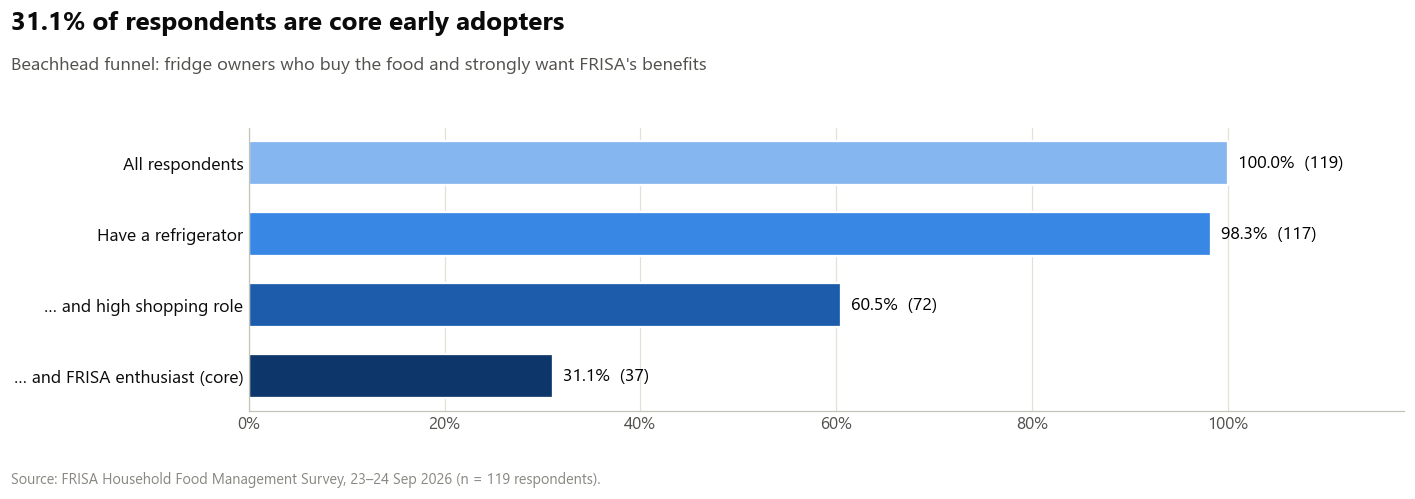

In [37]:
core = (df.fridge != 'No fridge') & (df.shopping_group == 'High') & (df.need_strong_count >= 4)
df['core_adopter'] = core
funnel = pd.Series({
    'All respondents': N,
    'Have a refrigerator': int((df.fridge != 'No fridge').sum()),
    '… and high shopping role': int(((df.fridge != 'No fridge') & (df.shopping_group == 'High')).sum()),
    '… and FRISA enthusiast (core)': int(core.sum()),
})
fig, ax = plt.subplots(figsize=(13, 4.6))
cols = [RAMP[250], RAMP[400], RAMP[550], RAMP[700]]
bars = ax.barh(funnel.index[::-1], funnel.values[::-1] / N * 100, color=cols[::-1], height=0.62, edgecolor=BG, linewidth=1.5)
for b_, c in zip(bars, funnel.values[::-1]):
    ax.text(b_.get_width() + 1, b_.get_y() + b_.get_height() / 2, f'{c / N * 100:.1f}%  ({c})', va='center', fontsize=11.5)
ax.set_xlim(0, 118); pct_fmt(ax); clean_ax(ax, 'x')
header(fig, f'{core.mean() * 100:.1f}% of respondents are core early adopters',
       'Beachhead funnel: fridge owners who buy the food and strongly want FRISA\'s benefits')
finish(fig, '31_beachhead_funnel')

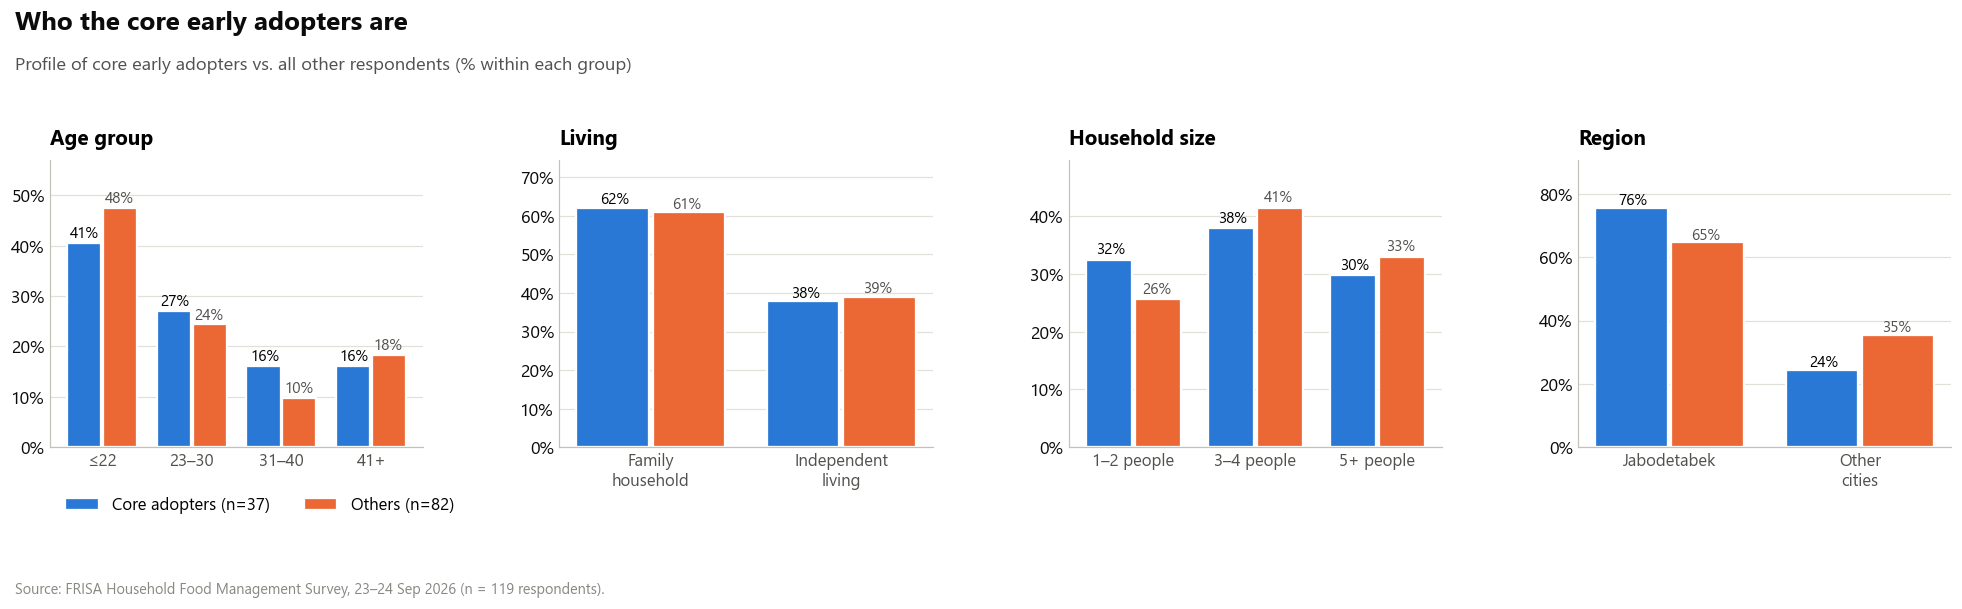

**Key takeaways**

- The core early-adopter group has **37 respondents (31.1%)**.
- Most live in a **family household** (62%) and in **Jabodetabek** (76%). Recommended beachhead: *urban family households in Greater Jakarta, targeting the family member who buys the groceries*.
- Their preferred input is camera-based for 59%, and their top features are Expiry reminders, Recipes from available ingredients, View fridge contents in the app.

In [38]:
def dist(col, order, m):
    return df.loc[m, col].astype(str).value_counts(normalize=True).reindex(order, fill_value=0) * 100

attrs = [('Age group', 'age_group', AGEG_ORDER), ('Living', 'living_group', ['Family household', 'Independent living']),
         ('Household size', 'household_group', HHG_ORDER), ('Region', 'region', ['Jabodetabek', 'Other cities'])]
fig, axes = plt.subplots(1, 4, figsize=(18, 5.6))
for ax, (ttl, col, order) in zip(axes, attrs):
    a_, b_ = dist(col, order, core), dist(col, order, ~core)
    x = np.arange(len(order)); w = 0.38
    ax.bar(x - w / 2 - 0.01, a_.values, w, color=BLUE, label=f'Core adopters (n={core.sum()})', edgecolor=BG, linewidth=1.5)
    ax.bar(x + w / 2 + 0.01, b_.values, w, color=ORANGE, label=f'Others (n={(~core).sum()})', edgecolor=BG, linewidth=1.5)
    for xi, v in zip(x, a_.values): ax.text(xi - w / 2, v + 1, f'{v:.0f}%', ha='center', fontsize=10)
    for xi, v in zip(x, b_.values): ax.text(xi + w / 2, v + 1, f'{v:.0f}%', ha='center', fontsize=10, color=INK2)
    ax.set_xticks(x); ax.set_xticklabels([wrap(o, 11) for o in order])
    ax.set_ylim(0, max(a_.max(), b_.max()) * 1.2); pct_fmt(ax, 'y'); clean_ax(ax, 'y')
    ax.set_title(ttl, loc='left', fontsize=13.5, fontweight='bold', pad=10)
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=2)
header(fig, 'Who the core early adopters are', 'Profile of core early adopters vs. all other respondents (% within each group)')
finish(fig, '32_beachhead_profile')

cp = df[core]
takeaways(
    f'The core early-adopter group has **{core.sum()} respondents ({core.mean() * 100:.1f}%)**.',
    f'Most live in a **family household** ({(cp.living_group == "Family household").mean() * 100:.0f}%) and in **Jabodetabek** '
    f'({(cp.region == "Jabodetabek").mean() * 100:.0f}%). Recommended beachhead: *urban family households in Greater Jakarta, targeting '
    'the family member who buys the groceries*.',
    f'Their preferred input is camera-based for {(cp.input_type == "Camera-based").mean() * 100:.0f}%, and their top features are '
    f'{", ".join(FEAT_LABEL[k] for k in FEAT[core].mean().nlargest(3).index)}.',
)

## 16. Illustrative economic scenario

The survey did **not** ask how much food respondents throw away, so the figures below are a **scenario, not a survey result**. They show what a given waste rate would cost a respondent household, based on the midpoint of its reported monthly food-spend band. The waste rates (5%, 10%, 15% of food spend) are assumptions for illustration. Replace them with a sourced estimate before citing a specific figure in the proposal.

In [39]:
MID = {'< Rp1M': 750_000, 'Rp1–2M': 1_500_000, 'Rp2–4M': 3_000_000, 'Rp4–6M': 5_000_000, '> Rp6M': 7_000_000}  # band midpoints (assumed)
RATES = [0.05, 0.10, 0.15]
known = df[df.food_spend.astype(str).isin(MID)]
spend = known.food_spend.astype(str).map(MID)
tbl = pd.DataFrame({'Respondents': known.food_spend.value_counts().reindex(list(MID)), 'Assumed monthly spend (Rp)': pd.Series(MID)})
for r in RATES:
    tbl[f'Annual value at risk @ {r:.0%} (Rp)'] = tbl['Assumed monthly spend (Rp)'] * r * 12
display(tbl.style.format({c: 'Rp{:,.0f}' for c in tbl.columns if 'Rp' in c}))
med = spend.median()
print(f'Respondents who disclosed spend: {len(known)} of {N}. Median band midpoint = Rp{med:,.0f} per month.')
for r in RATES:
    print(f'  If {r:.0%} of food spend is wasted, the median household loses ≈ Rp{med * r * 12:,.0f} per year.')
takeaways(
    f'At the median reported spend, each 5% of food wasted equals about **Rp{med * 0.05 * 12:,.0f} per household per year**.',
    f'This helps explain why {share(A.Q15):.1f}% say seeing the money value of waste would make them more careful. '
    'FRISA\'s Consumption Insights turns that money into a number users can see.',
)

,Respondents,Assumed monthly spend (Rp),Annual value at risk @ 5% (Rp),Annual value at risk @ 10% (Rp),Annual value at risk @ 15% (Rp)
< Rp1M,16,"Rp750,000","Rp450,000","Rp900,000","Rp1,350,000"
Rp1–2M,35,"Rp1,500,000","Rp900,000","Rp1,800,000","Rp2,700,000"
Rp2–4M,27,"Rp3,000,000","Rp1,800,000","Rp3,600,000","Rp5,400,000"
Rp4–6M,25,"Rp5,000,000","Rp3,000,000","Rp6,000,000","Rp9,000,000"
> Rp6M,7,"Rp7,000,000","Rp4,200,000","Rp8,400,000","Rp12,600,000"


Respondents who disclosed spend: 110 of 119. Median band midpoint = Rp3,000,000 per month.
  If 5% of food spend is wasted, the median household loses ≈ Rp1,800,000 per year.
  If 10% of food spend is wasted, the median household loses ≈ Rp3,600,000 per year.
  If 15% of food spend is wasted, the median household loses ≈ Rp5,400,000 per year.


**Key takeaways**

- At the median reported spend, each 5% of food wasted equals about **Rp1,800,000 per household per year**.
- This helps explain why 95.8% say seeing the money value of waste would make them more careful. FRISA's Consumption Insights turns that money into a number users can see.

## 17. Proposal-ready evidence (numbers to paste into Chapter 1)

Every number below is calculated from the dataset, so it updates automatically if the data changes.

In [40]:
first, last = df.timestamp.min(), df.timestamp.max()
top_city = df.city.value_counts()
p = lambda m: f'{share(m):.1f}%'
snap = pd.DataFrame([
    ('Have forgotten food stored in their refrigerator', p(A.Q1), 'Visual 1.2 · 1A'),
    ('Have found expired / spoiled food in their refrigerator', p(A.Q3), 'Visual 1.2 · 2B'),
    ('Do not consistently check stock before shopping (only ' + p(T.Q5) + ' always do)', p(~A.Q5), 'Visual 1.2 · 1B'),
    ('Bought an item they already had at home', p(A.Q2), 'Visual 1.2 · 3B'),
    ('Over-bought food that was never eaten', p(A.Q6), '3B'),
    ('Find it hard to know all fridge contents without checking one by one', p(A.Q7), '1B'),
    ('Find it hard to remember expiry dates', p(A.Q9), '2A'),
    ('Unsure what to cook with the ingredients they have', p(A.Q4), '3A'),
    ('Choose menus without considering ingredients at home', p(A.Q12), '3A'),
    ('Agree with 6+ of 8 problem statements', p(df.pain_count >= 6), '1.3 core problem'),
    ('Agree with ALL 7 solution statements (interest in FRISA\'s value proposition)', p(df.need_count == len(NEED)), 'Visual 1.2 · interest'),
    ('Top-3 features', ', '.join(f'{FEAT_LABEL[k]} ({share(FEAT[k]):.1f}%)' for k in top3), 'Visual 1.2 · features'),
    ('Prefer camera-based input (FRISA camera or smartphone scan)', f'{camera_share:.1f}%', '1.4 / product'),
    ('Want a monthly food & money savings report', p(A.Q16), '1.4 SAVE / SDG 12.8'),
], columns=['Metric', 'Survey result', 'Where to use in proposal'])
display(snap.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

Metric,Survey result,Where to use in proposal
Have forgotten food stored in their refrigerator,79.0%,Visual 1.2 · 1A
Have found expired / spoiled food in their refrigerator,78.2%,Visual 1.2 · 2B
Do not consistently check stock before shopping (only 7.6% always do),51.3%,Visual 1.2 · 1B
Bought an item they already had at home,81.5%,Visual 1.2 · 3B
Over-bought food that was never eaten,76.5%,3B
Find it hard to know all fridge contents without checking one by one,84.9%,1B
Find it hard to remember expiry dates,79.8%,2A
Unsure what to cook with the ingredients they have,71.4%,3A
Choose menus without considering ingredients at home,68.1%,3A
Agree with 6+ of 8 problem statements,73.1%,1.3 core problem


In [41]:
text_12 = (f'The survey was distributed online through Google Forms from {first:%d} to {last:%d %B %Y} and received **{N} valid responses**, '
           f'mostly from Jabodetabek ({share(df.region == "Jabodetabek"):.1f}%; Jakarta alone {share(df.city == "Jakarta"):.1f}%) and '
           f'respondents aged 18–30 ({share(df.age.isin(["18–22", "23–30"])):.1f}%). {share(df.fridge != "No fridge"):.1f}% own a refrigerator and '
           f'{share(df.shopping_group == "High"):.1f}% are often or almost always involved in buying household food.')

visual_12 = '\n'.join([
    '> **Visual 1.2 — Survey Snapshot** (n = 119)',
    f'> - **{share(A.Q1):.1f}%** have forgotten food stored in their refrigerator',
    f'> - **{share(A.Q3):.1f}%** have found expired or spoiled food in their refrigerator',
    f'> - **{share(~A.Q5):.1f}%** do not consistently check what they already have before shopping (only {share(T.Q5):.1f}% always do)',
    f'> - **{share(A.Q2):.1f}%** have bought an item they already had at home',
    f'> - **{share(df.need_count == len(NEED)):.1f}%** agree with every FRISA value proposition; top features: '
    f'{FEAT_LABEL[top3[0]]} ({share(FEAT[top3[0]]):.1f}%), {FEAT_LABEL[top3[1]]} ({share(FEAT[top3[1]]):.1f}%), {FEAT_LABEL[top3[2]]} ({share(FEAT[top3[2]]):.1f}%)',
])

rc_lines = '\n'.join([
    f'- **1B Manual inventory checking:** *Survey: {share(~A.Q5):.1f}% do not consistently check before shopping; {share(A.Q7):.1f}% find it hard to know all fridge contents without checking item by item.*',
    f'- **2A No expiry prioritisation:** *Survey: {share(A.Q9):.1f}% find it hard to track / remember expiry dates.*',
    f'- **2B Reactive management:** *Survey: {share(A.Q3):.1f}% have found spoiled food in their fridge.*',
    f'- **3A Disconnected meal planning:** *Survey: {share(A.Q12):.1f}% plan meals without considering what they have; {share(A.Q4):.1f}% are unsure what to cook with what they have.*',
    f'- **3B Disconnected shopping:** *Survey: {share(A.Q2):.1f}% have bought something they already had; {share(A.Q6):.1f}% have over-bought food that went uneaten.*',
    f'- **1A Fragmented visibility (optional add-on):** *Survey: {share(A.Q1):.1f}% have forgotten food in their fridge.*',
])

display(Markdown('### Paste-ready text for Section 1.2 (Research Survey)\n\n' + text_12))
display(Markdown('### Paste-ready Visual 1.2\n\n' + visual_12))
display(Markdown('### Paste-ready "Survey: [XX]%" lines for Section 1.3\n\n' + rc_lines))

### Paste-ready text for Section 1.2 (Research Survey)

The survey was distributed online through Google Forms from 23 to 24 September 2026 and received **119 valid responses**, mostly from Jabodetabek (68.1%; Jakarta alone 31.1%) and respondents aged 18–30 (69.7%). 98.3% own a refrigerator and 62.2% are often or almost always involved in buying household food.

### Paste-ready Visual 1.2

> **Visual 1.2 — Survey Snapshot** (n = 119)
> - **79.0%** have forgotten food stored in their refrigerator
> - **78.2%** have found expired or spoiled food in their refrigerator
> - **51.3%** do not consistently check what they already have before shopping (only 7.6% always do)
> - **81.5%** have bought an item they already had at home
> - **78.2%** agree with every FRISA value proposition; top features: Expiry reminders (63.0%), "Use-first" food prioritisation (50.4%), Recipes from available ingredients (50.4%)

### Paste-ready "Survey: [XX]%" lines for Section 1.3

- **1B Manual inventory checking:** *Survey: 51.3% do not consistently check before shopping; 84.9% find it hard to know all fridge contents without checking item by item.*
- **2A No expiry prioritisation:** *Survey: 79.8% find it hard to track / remember expiry dates.*
- **2B Reactive management:** *Survey: 78.2% have found spoiled food in their fridge.*
- **3A Disconnected meal planning:** *Survey: 68.1% plan meals without considering what they have; 71.4% are unsure what to cook with what they have.*
- **3B Disconnected shopping:** *Survey: 81.5% have bought something they already had; 76.5% have over-bought food that went uneaten.*
- **1A Fragmented visibility (optional add-on):** *Survey: 79.0% have forgotten food in their fridge.*

In [42]:
insights = [
    ('Problem is real', f'{share(df.pain_count >= 6):.1f}% of respondents agree with 6+ of 8 food-waste pain points; {share(A[PATH].any(axis=1)):.1f}% report at least one waste pathway.'),
    ('Visibility is the #1 gap', f'{share(A.Q7):.1f}% cannot see all fridge contents without checking item by item, and {share(A.Q8):.1f}% want to check their fridge remotely.'),
    ('Expiry is the #1 feature', f'Expiry reminders are the most-chosen feature ({share(FEAT.reminder):.1f}%), and {share(A.Q10):.1f}% need reminders.'),
    ('Shopping habits leak money', f'{share(A.Q2):.1f}% have bought duplicates; only {share(T.Q5):.1f}% firmly check stock before shopping.'),
    ('Near-unanimous demand', f'{share(df.need_count == len(NEED)):.1f}% agree with all 7 FRISA value propositions; solutions are endorsed {avg_need / avg_pain:.1f}× more strongly than problems.'),
    ('Camera-first is right', f'{camera_share:.1f}% prefer camera input; manual entry {share(df.input_type == "Manual"):.1f}%, voice {share(df.input_type == "Voice"):.1f}%.'),
    ('Voice is secondary', f'Voice assistant is picked by only {share(FEAT.voice):.1f}% as a top-3 feature; position it as a convenience add-on.'),
    ('Savings = retention', f'{share(A.Q16):.1f}% want a savings report, but only {share(FEAT.savings_report):.1f}% rank it top-3, so use it for engagement rather than acquisition.'),
    ('Universal demand', f'Only {n_sig} of {n_tests} segment tests are significant; demand holds across age, household type, spend and region.'),
    ('Four personas', ', '.join(f'{p} ({share(df.persona == p):.1f}%)' for p in PERSONA_ORDER) + '.'),
    ('Beachhead', f'Core early adopters = {core.mean() * 100:.1f}% of respondents, mostly urban family households; start in Jabodetabek.'),
]
display(pd.DataFrame(insights, columns=['Insight', 'Evidence']).style.hide(axis='index').set_properties(**{'text-align': 'left'}))

Insight,Evidence
Problem is real,73.1% of respondents agree with 6+ of 8 food-waste pain points; 99.2% report at least one waste pathway.
Visibility is the #1 gap,"84.9% cannot see all fridge contents without checking item by item, and 94.1% want to check their fridge remotely."
Expiry is the #1 feature,"Expiry reminders are the most-chosen feature (63.0%), and 97.5% need reminders."
Shopping habits leak money,81.5% have bought duplicates; only 7.6% firmly check stock before shopping.
Near-unanimous demand,78.2% agree with all 7 FRISA value propositions; solutions are endorsed 2.4× more strongly than problems.
Camera-first is right,"63.9% prefer camera input; manual entry 4.2%, voice 6.7%."
Voice is secondary,Voice assistant is picked by only 8.4% as a top-3 feature; position it as a convenience add-on.
Savings = retention,"98.3% want a savings report, but only 22.7% rank it top-3, so use it for engagement rather than acquisition."
Universal demand,"Only 7 of 126 segment tests are significant; demand holds across age, household type, spend and region."
Four personas,"Automation Seekers (37.8%), Connected Planners (21.8%), Expiry Guardians (20.2%), Smart Home Cooks (20.2%)."


## 18. Limitations & next steps

**Limitations (state these in the proposal to stay credible):**
1. **Convenience sample (n = 119).** Respondents are mostly young (≤30) and urban (Jabodetabek), so results describe likely early users and are **not national estimates**, as proposal Section 1.2 already states.
2. **Agreement bias / ceiling effect.** Nobody chose 1 or 2. The statements describe familiar situations, and some respondents tend to agree with statements in general. We use strong agreement (% choosing 5) and forced-choice questions (top-3 features, input method) to separate strong preferences from mild ones.
3. **No willingness-to-pay or purchase-intent question.** "Demand" here means agreement with value propositions, not a commitment to buy.
4. **No measured waste volume.** The economic figures in Section 16 are scenarios based on assumed waste rates.
5. **Small sub-groups.** Some segments (e.g. no fridge n = 2, "Other" living n = 4) are too small for conclusions.

**Recommended next steps:**
- Add a **pricing / willingness-to-pay** question (e.g. Van Westendorp) and a **purchase-intent** scale in the next survey round.
- Run a **1–2 week pilot diary** with prototype users to measure actual items forgotten and wasted before and after using FRISA, which would give real evidence for the SAVE step.
- Run a larger, more age-balanced sample (≥ 300) to confirm the directional segment signals in Section 12.

## 19. Export

Saves the cleaned, English-translated dataset with all engineered features, plus a list of every figure produced.

In [43]:
export = df.drop(columns=['features']).copy()
export['feature_list'] = export['feature_list'].apply(lambda ks: '; '.join(FEAT_LABEL[k] for k in ks))
export = pd.concat([export, FEAT.add_prefix('feat_')], axis=1)
out_path = BASE / 'frisa_survey_processed.csv'
export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Processed dataset saved: {out_path.name}  ({export.shape[0]} rows × {export.shape[1]} columns)')
figs = sorted(p.name for p in FIG_DIR.glob('*.png'))
print(f'{len(figs)} figures saved in {FIG_DIR.name}/ (200 dpi PNG, ready for the proposal / slides):')
for f in figs:
    print('  -', f)

Processed dataset saved: frisa_survey_processed.csv  (119 rows × 50 columns)
33 figures saved in figures/ (200 dpi PNG, ready for the proposal / slides):
  - 00_likert_scale_usage.png
  - 01_kpi_dashboard.png
  - 02_profile_demographics.png
  - 03_profile_household.png
  - 04_profile_age_x_living.png
  - 05_problem_validation_likert.png
  - 06_check_before_shopping.png
  - 07_pain_point_accumulation.png
  - 08_waste_pathways_upset.png
  - 09_problem_vs_solution_by_theme.png
  - 10_solution_demand_likert.png
  - 11_conviction_strongly_agree.png
  - 12_enthusiast_distribution.png
  - 13_feature_ranking.png
  - 14_feature_pillars.png
  - 15_feature_cooccurrence.png
  - 16_feature_bundles.png
  - 17_word_frequency.png
  - 18_input_method.png
  - 19_input_method_by_age.png
  - 20_segment_matrix_demographics.png
  - 21_segment_matrix_household.png
  - 22_segment_significance_scan.png
  - 23_segment_deviations.png
  - 24_segment_features.png
  - 25_persona_silhouette.png
  - 26_persona_profil